In [39]:
import pandas as pd

# Read complete data to o EDA
CURATED_FOLDER = CURATED_FOLDER = "../data/curated"
path = final_csv = f"{CURATED_FOLDER}/descriptors_and_frequencies/peptides_100.csv"
complete_data = pd.read_csv(path, delimiter=',')
print(complete_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Columns: 2871 entries, SEQUENCE to mZagreb2
dtypes: bool(2), float64(2359), int64(337), object(173)
memory usage: 2.0+ MB
None


In [40]:
# Drop all variables with missing values.

print("Before:", complete_data.shape)
df_clean = complete_data.dropna(axis=1,  how='all')
print("After:", df_clean.shape)

Before: (92, 2871)
After: (92, 2871)


In [41]:
# Remove variables (descriptors, dimer, and trimer frequencies) with a standard deviation less than 0.05

# Columns to exclude from filtering
exclude_cols = ['SEQUENCE', 'μM', 'label']

df = complete_data 

# Select only numeric columns except the excluded ones
numeric_cols = df.select_dtypes(include=['number']).columns.difference(exclude_cols)

# Keep only those numeric columns with std >= 0.05
filtered_numeric_cols = [col for col in numeric_cols if df[col].std() >= 0.05]

# Add back excluded columns
final_cols = exclude_cols + filtered_numeric_cols

# Create filtered DataFrame
df_filtered = df[final_cols]


print(f"Original shape: {df.shape}")
print(f"Filtered shape: {df_filtered.shape}")
print(df_filtered.iloc[:,:10])


Original shape: (92, 2871)
Filtered shape: (92, 867)
                                  SEQUENCE     μM  label         A     AATS0Z  \
0                           GLPALISWIKRKRL  596.7      0  0.071429  20.214286   
1                     IVPFLLGMVPKLVCLITKKC    7.0      1  0.000000  21.625000   
2               KLKLKLKLKLKLKLKLKLKLKLKLKL    0.3      1  0.000000  18.271511   
3                             ILPILSLIGGLL  180.0      0  0.000000  19.340206   
4                      CVKVRVKVGSGVKVRVKVC  590.0      0  0.000000  21.584416   
..                                     ...    ...    ...       ...        ...   
87                       FLPVILPVIGKLLSGIL   50.0      1  0.000000  19.544484   
88  AQWFAIQHISLNPPRSTIAMRAINNYRWRSKNQNTFLR   10.5      1  0.105263  22.628483   
89             KFGKIVGKVLKQLKKVSAVAKVAMKKG  275.5      0  0.111111  20.350562   
90                           FAKLLAKLAKLKL  404.9      0  0.230769  19.181034   
91          FKAFKAFKAFKAFKAFKAFKAFKAFKAFKA  143.8      0

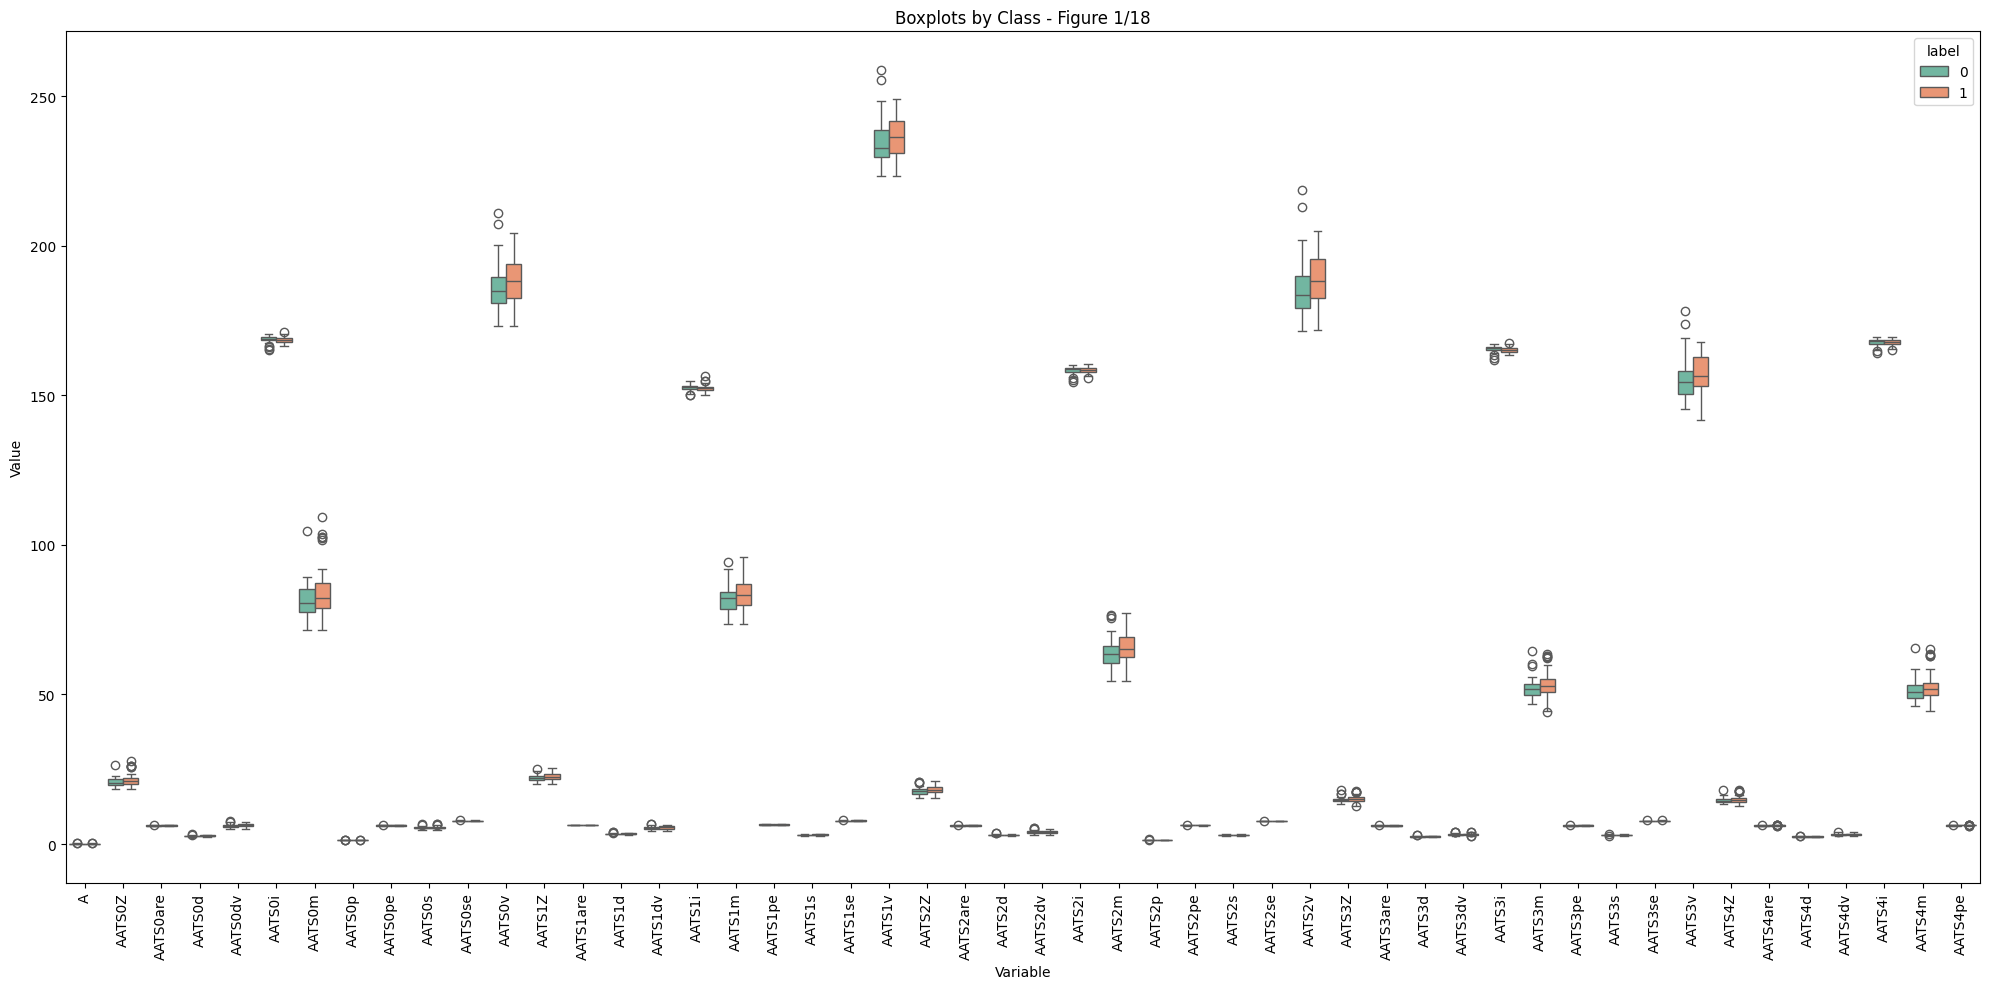

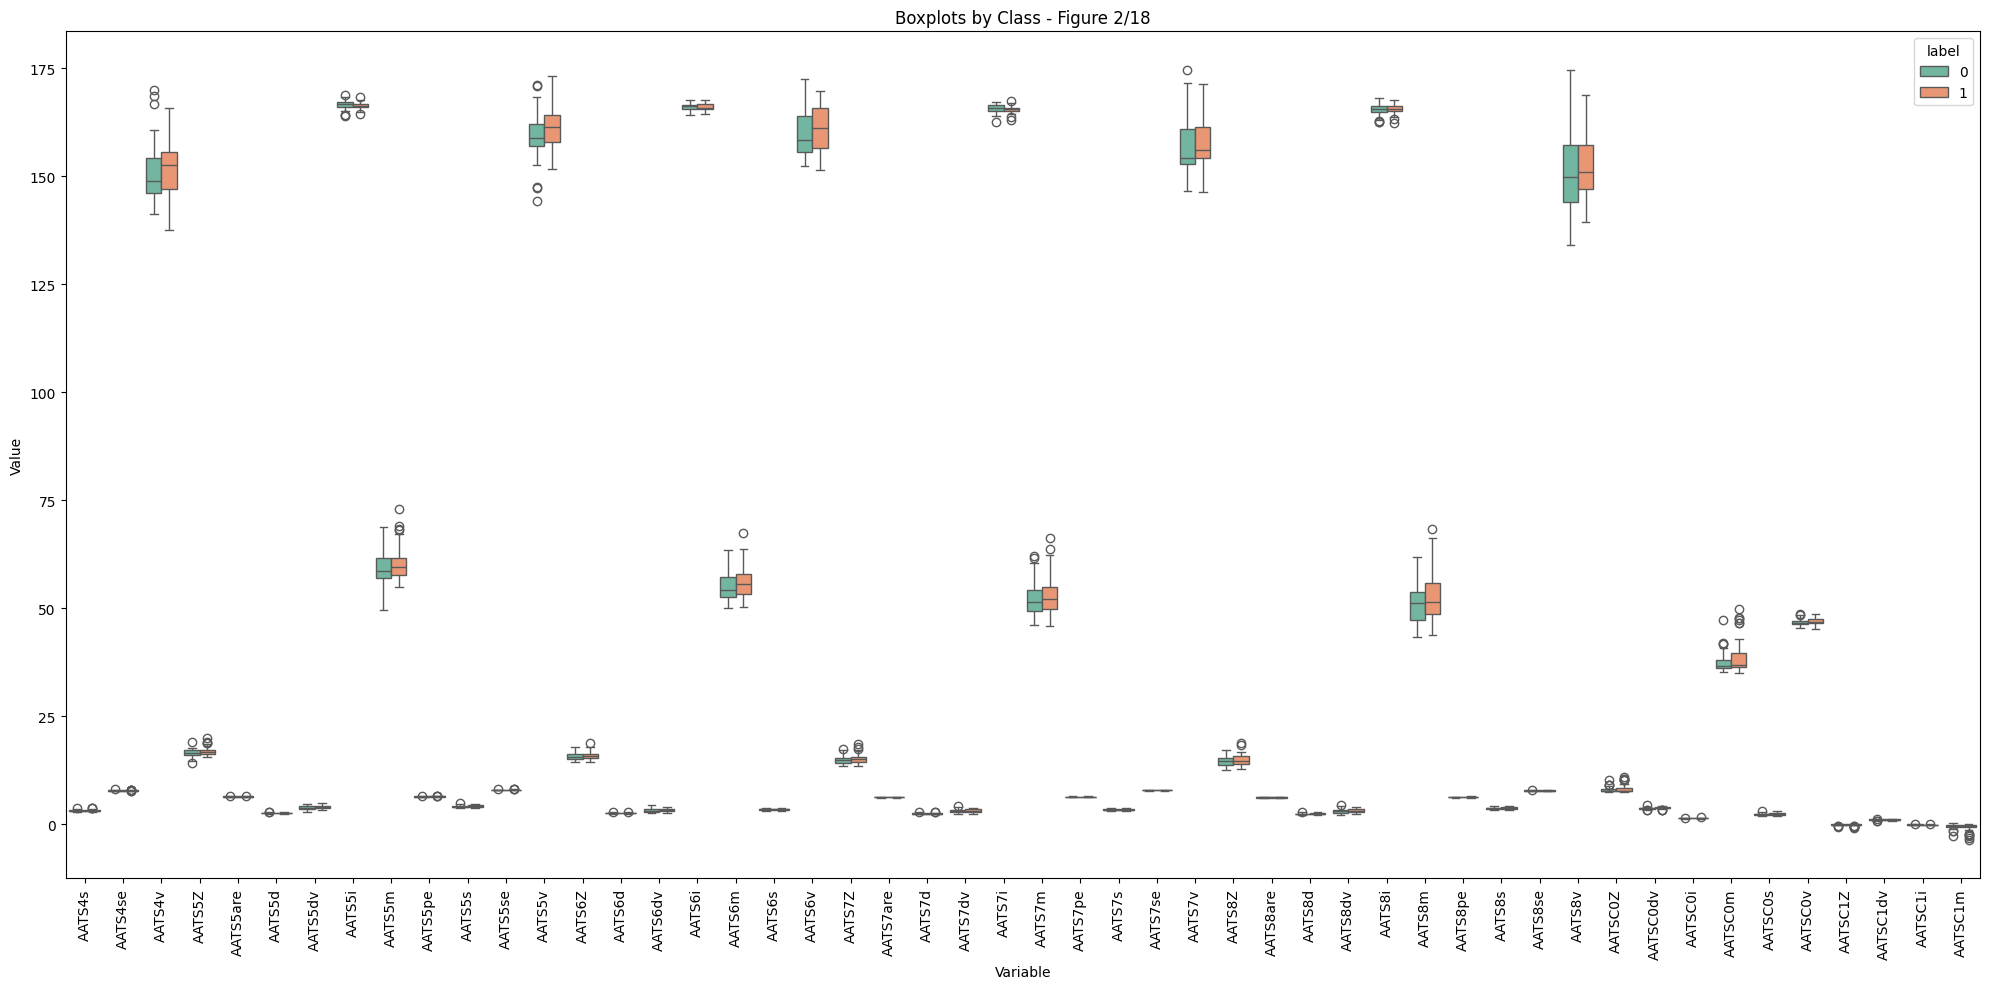

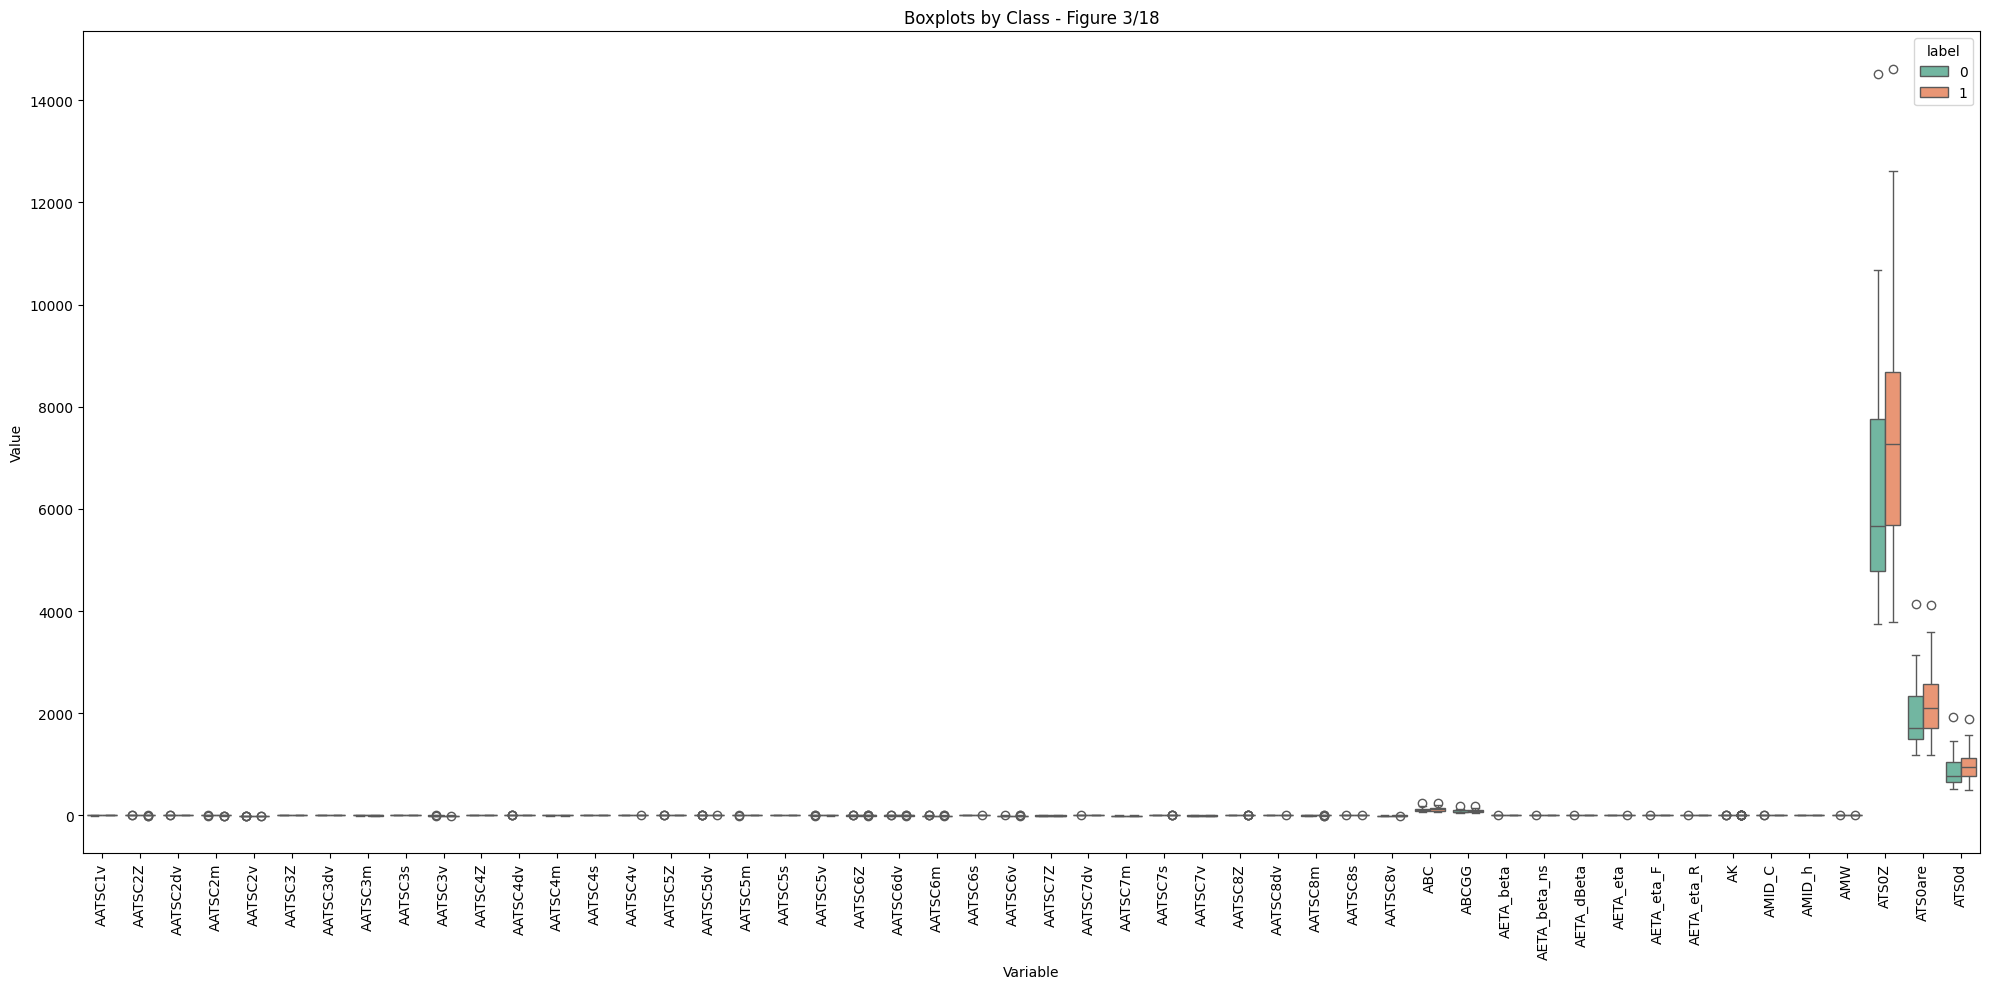

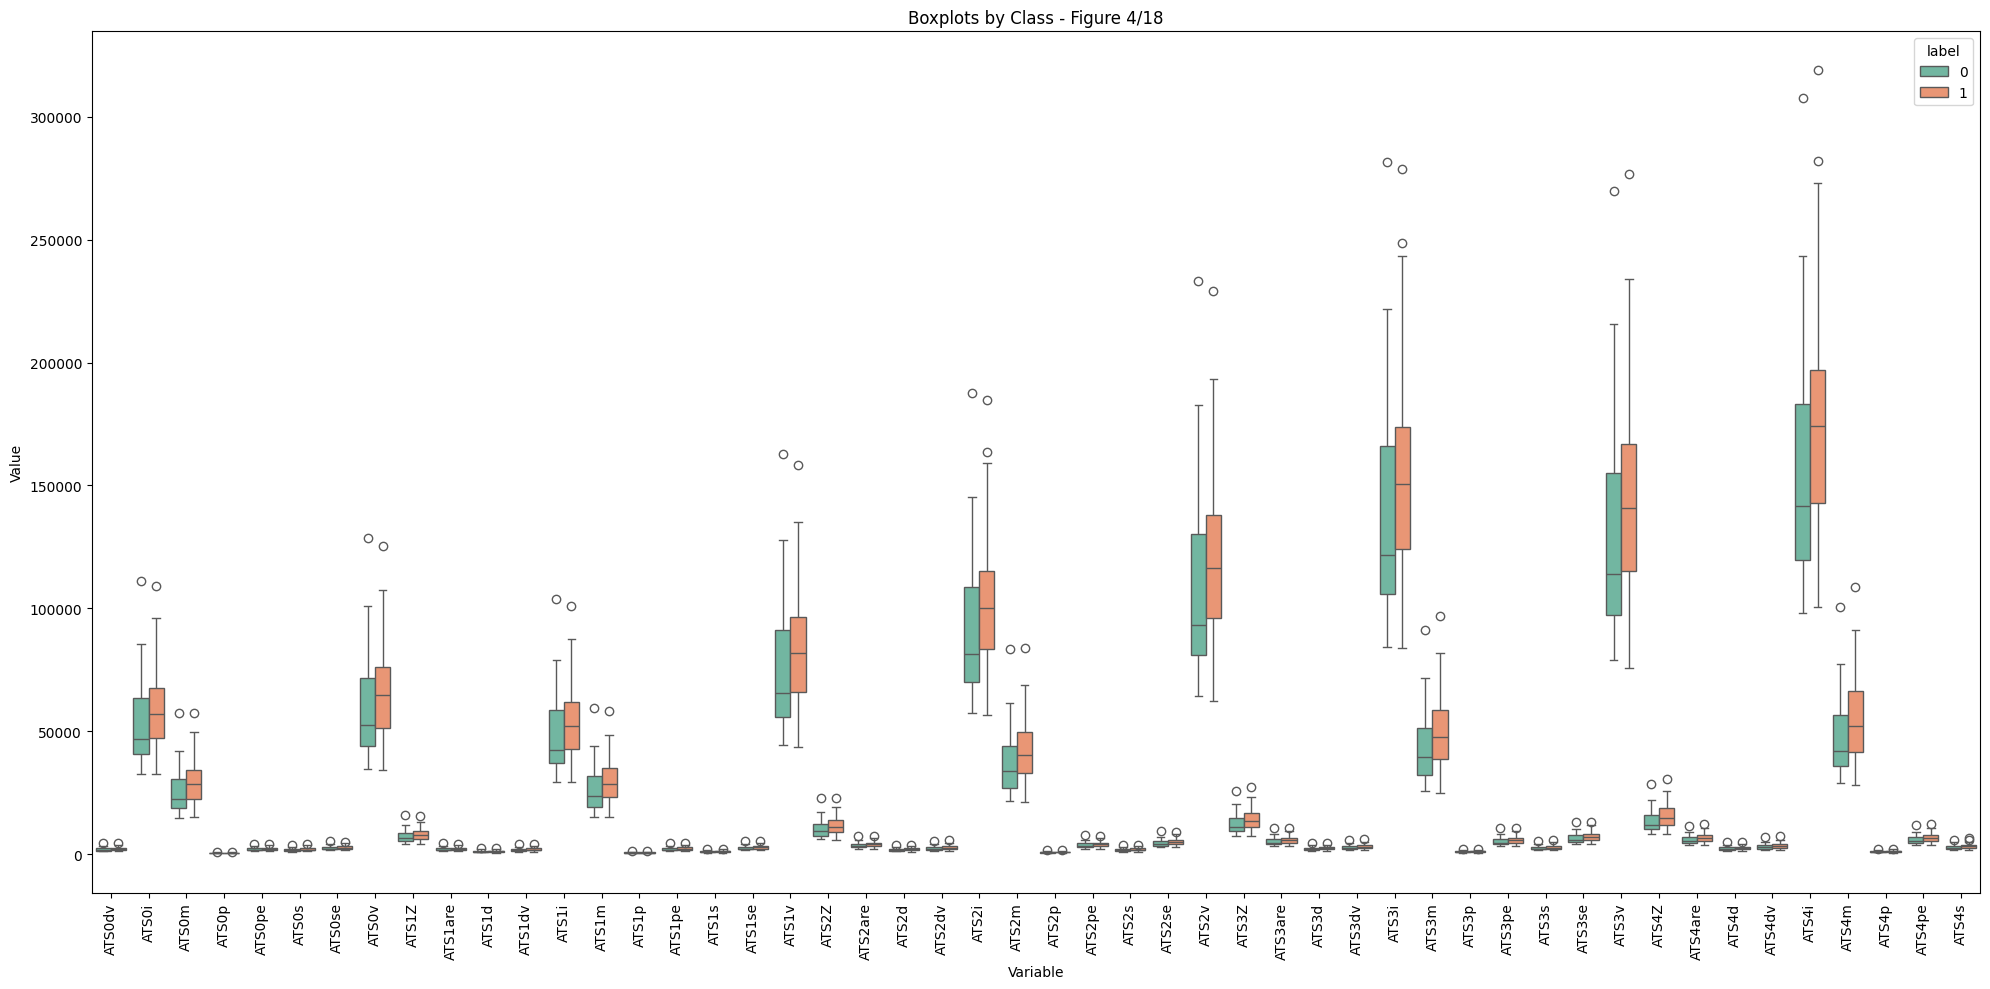

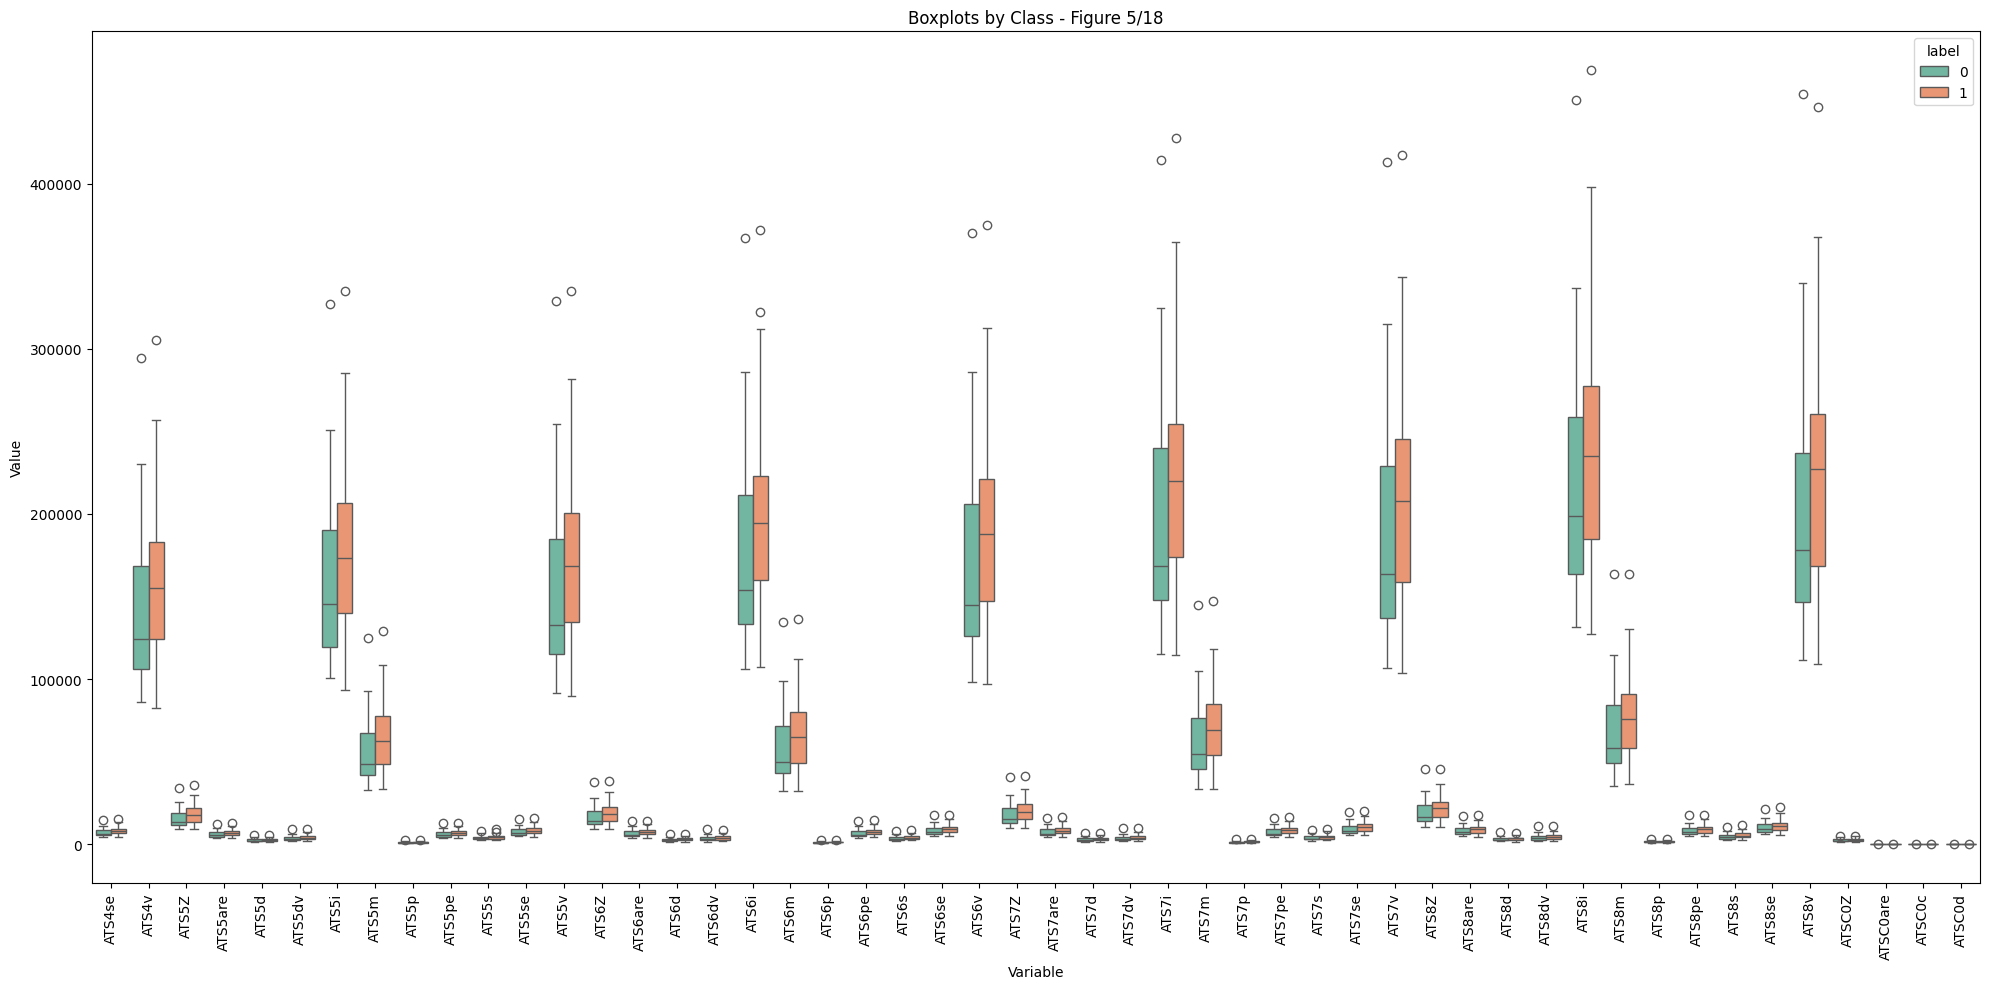

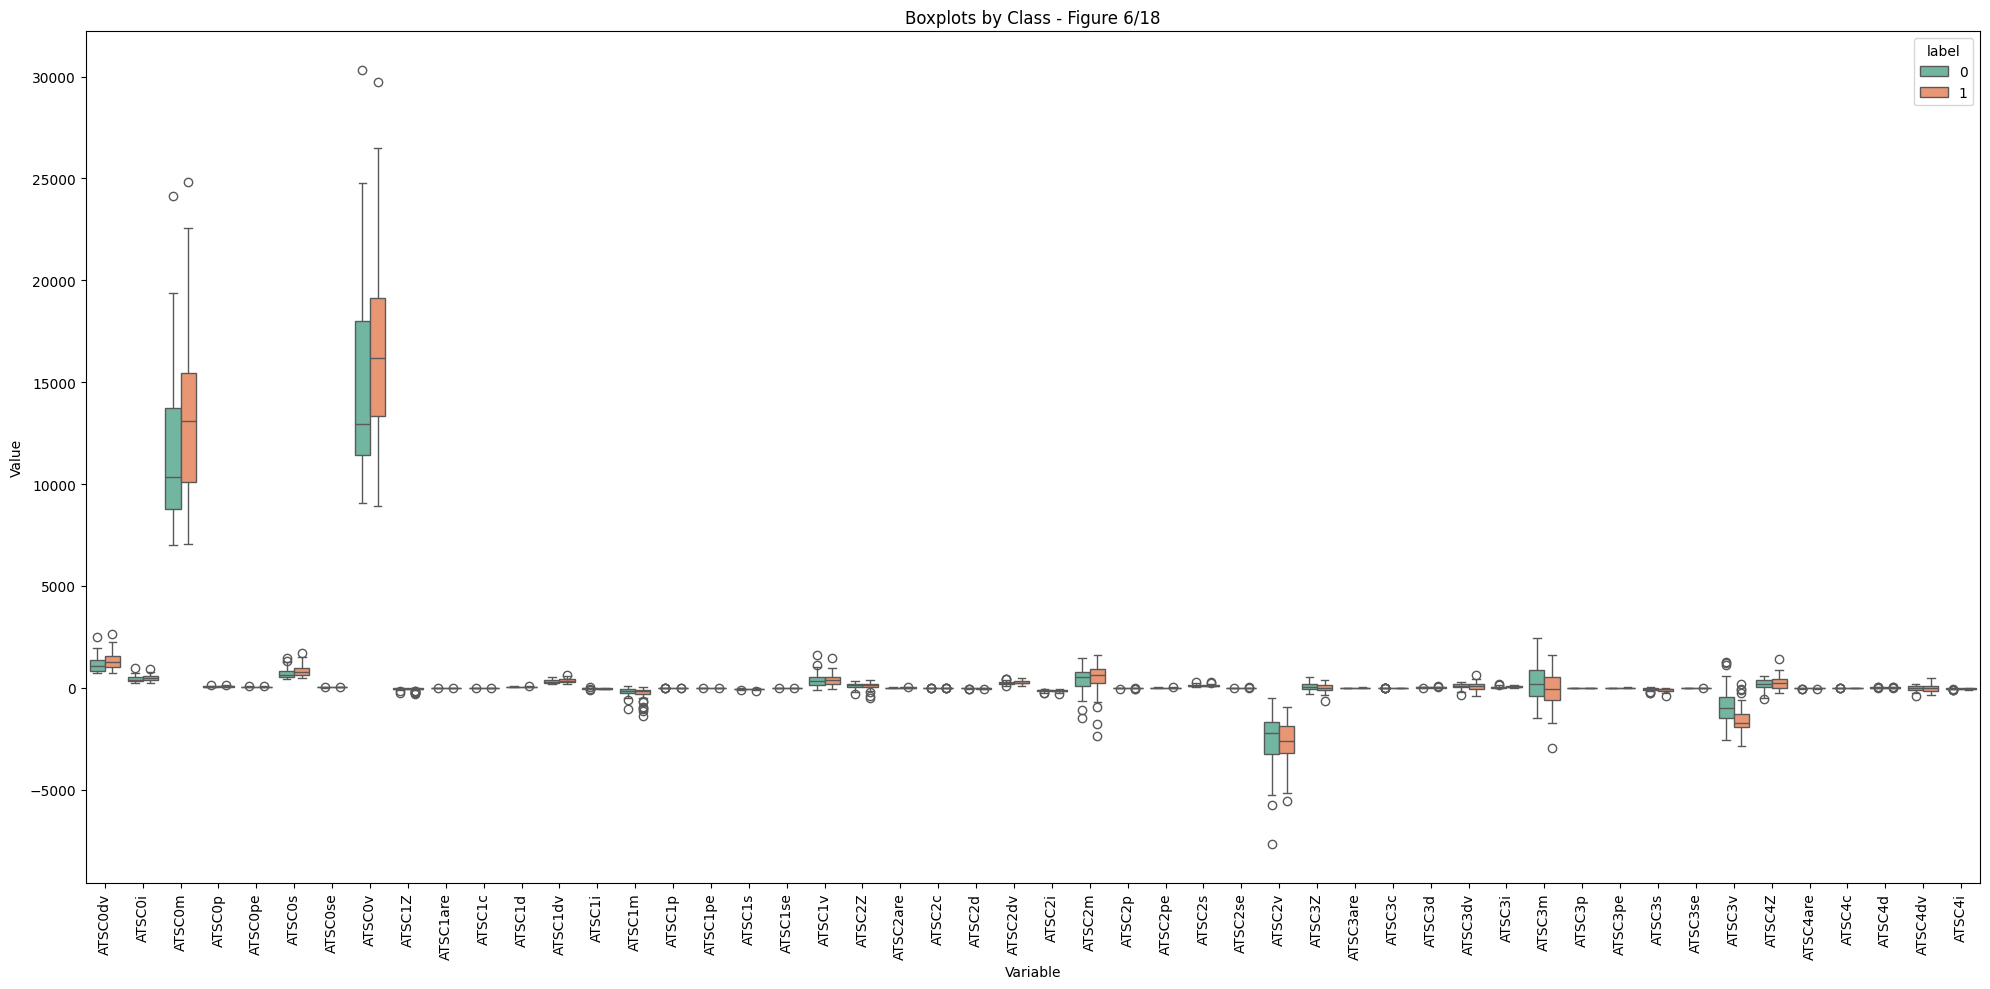

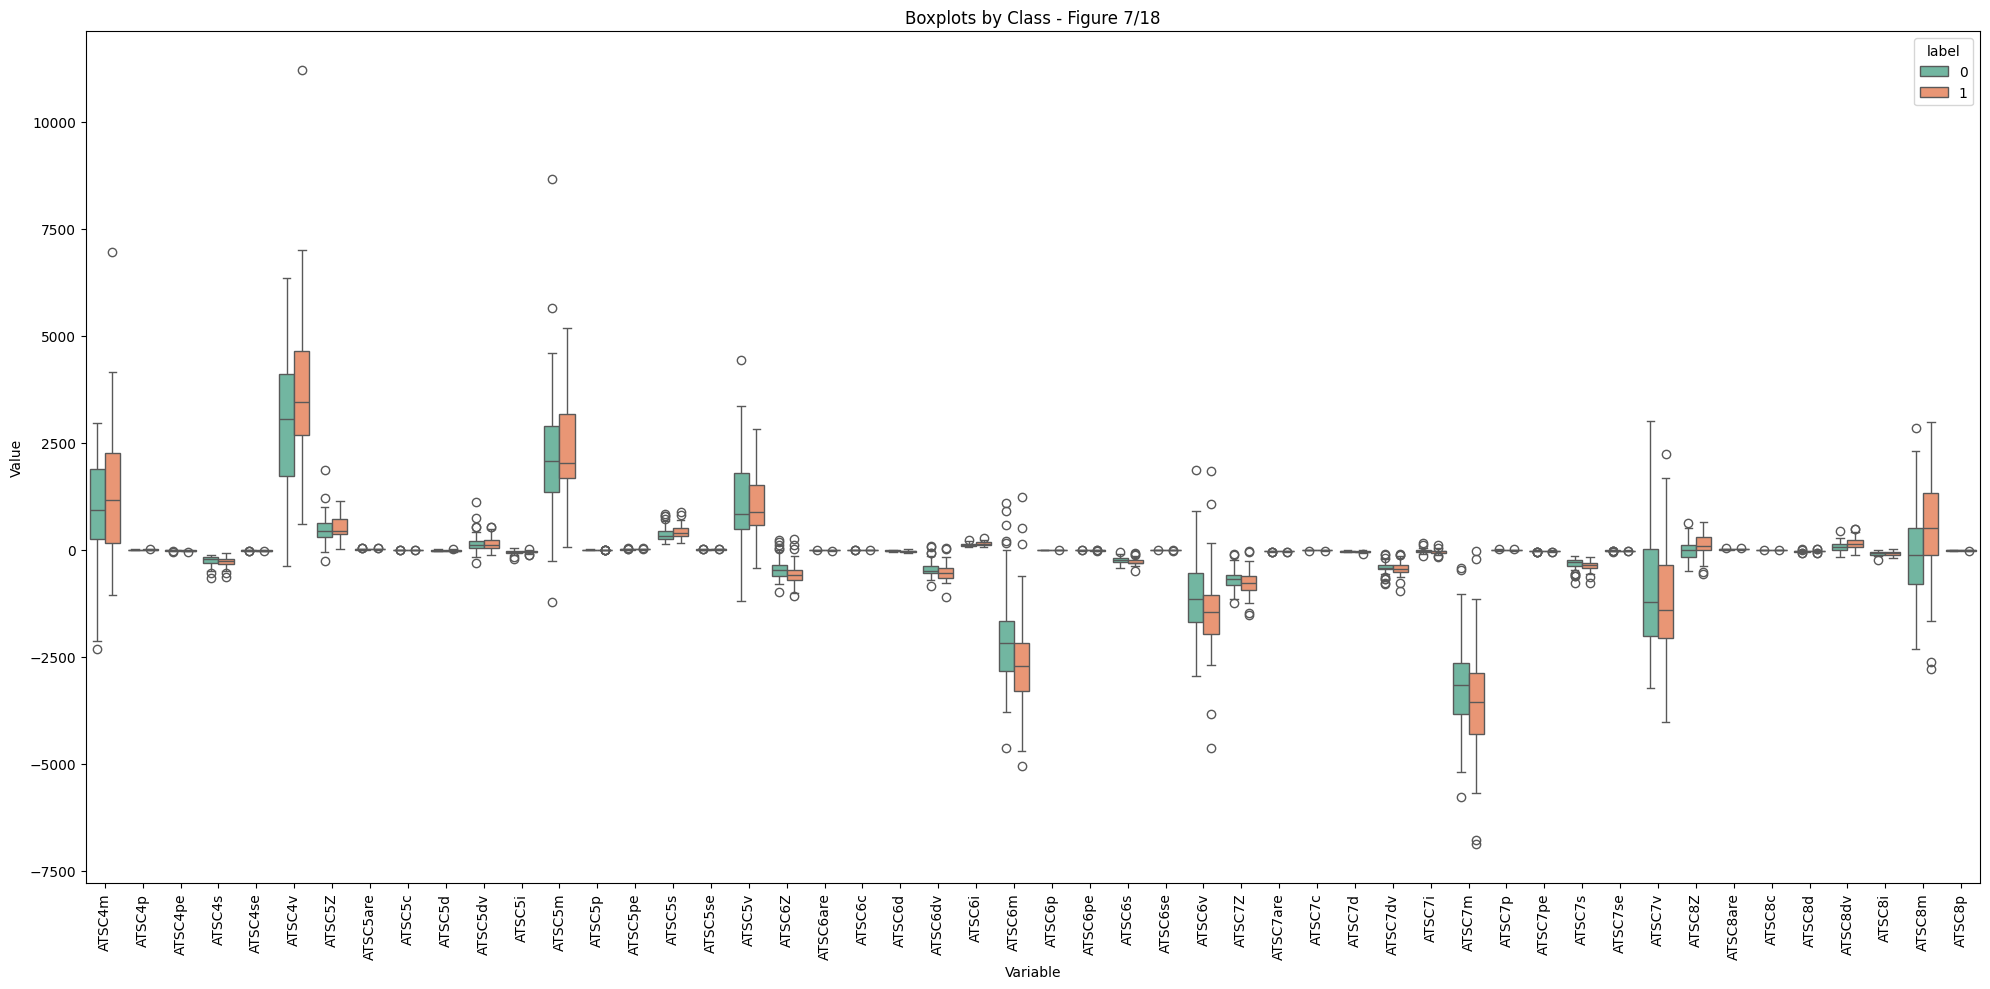

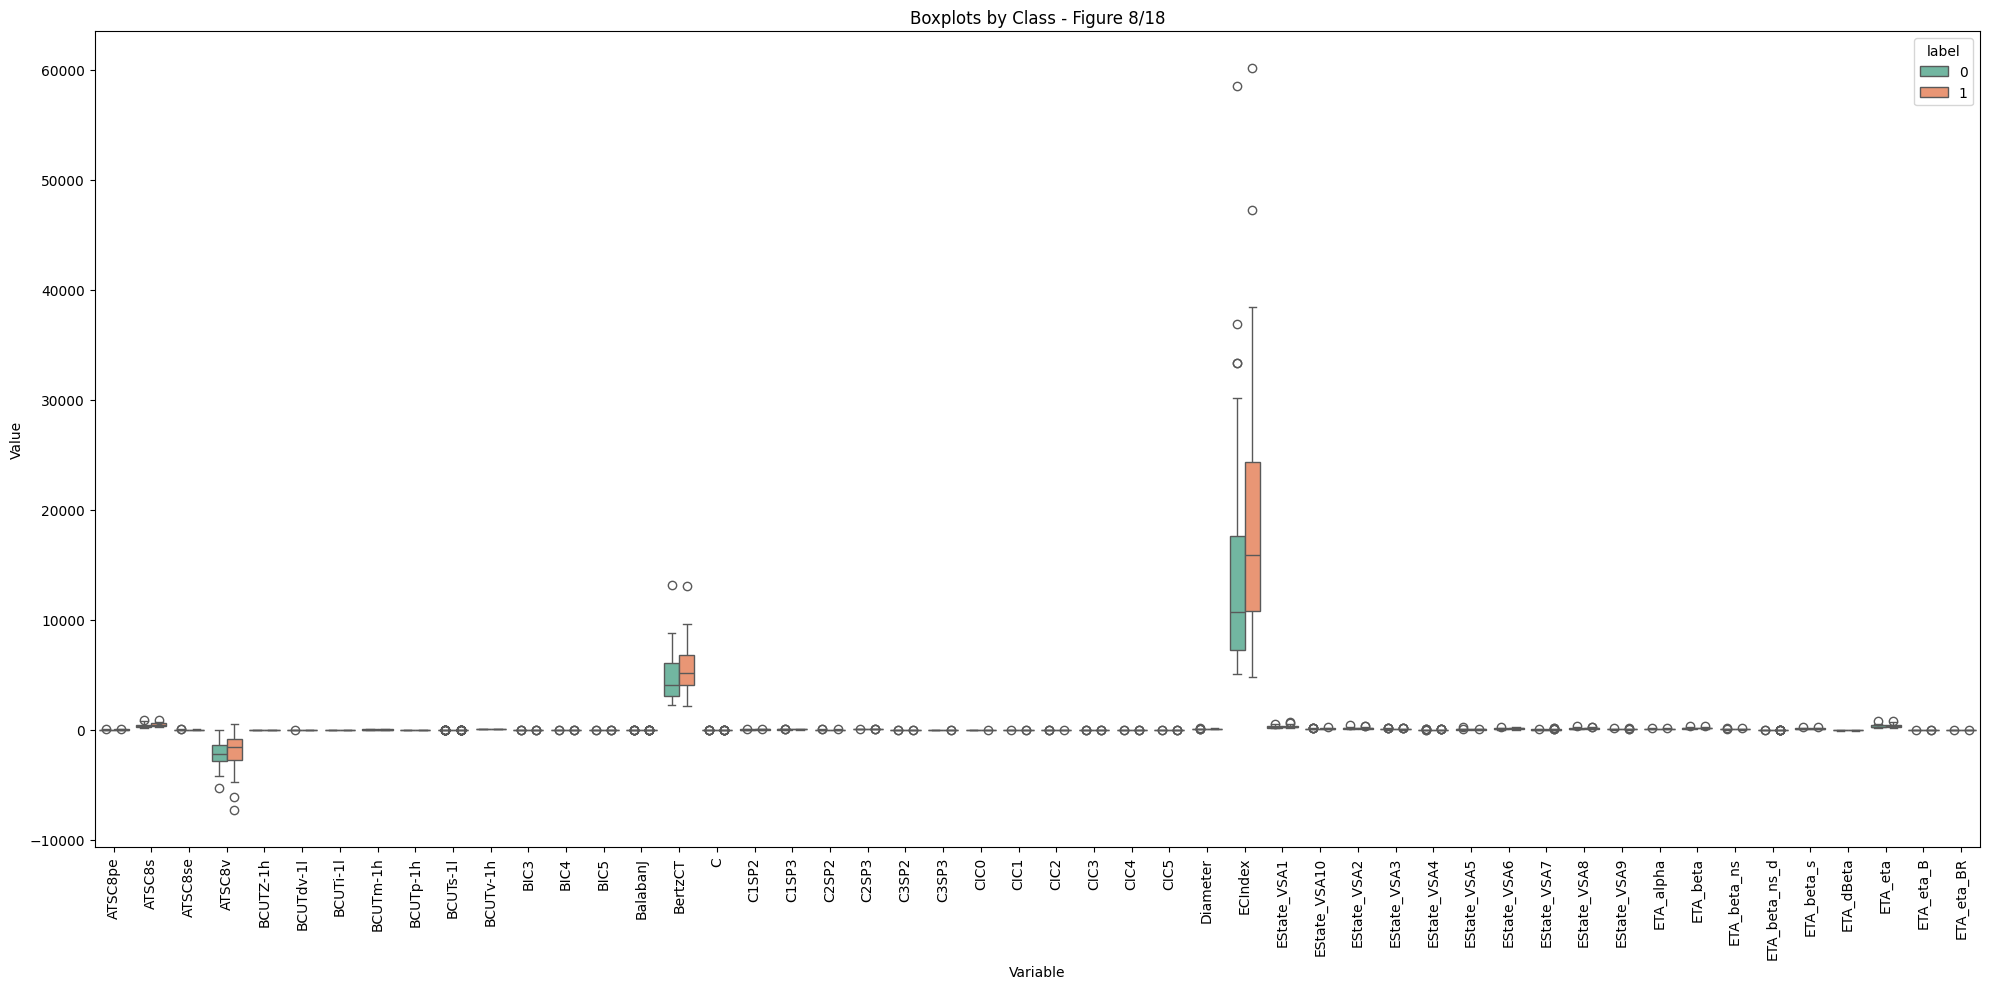

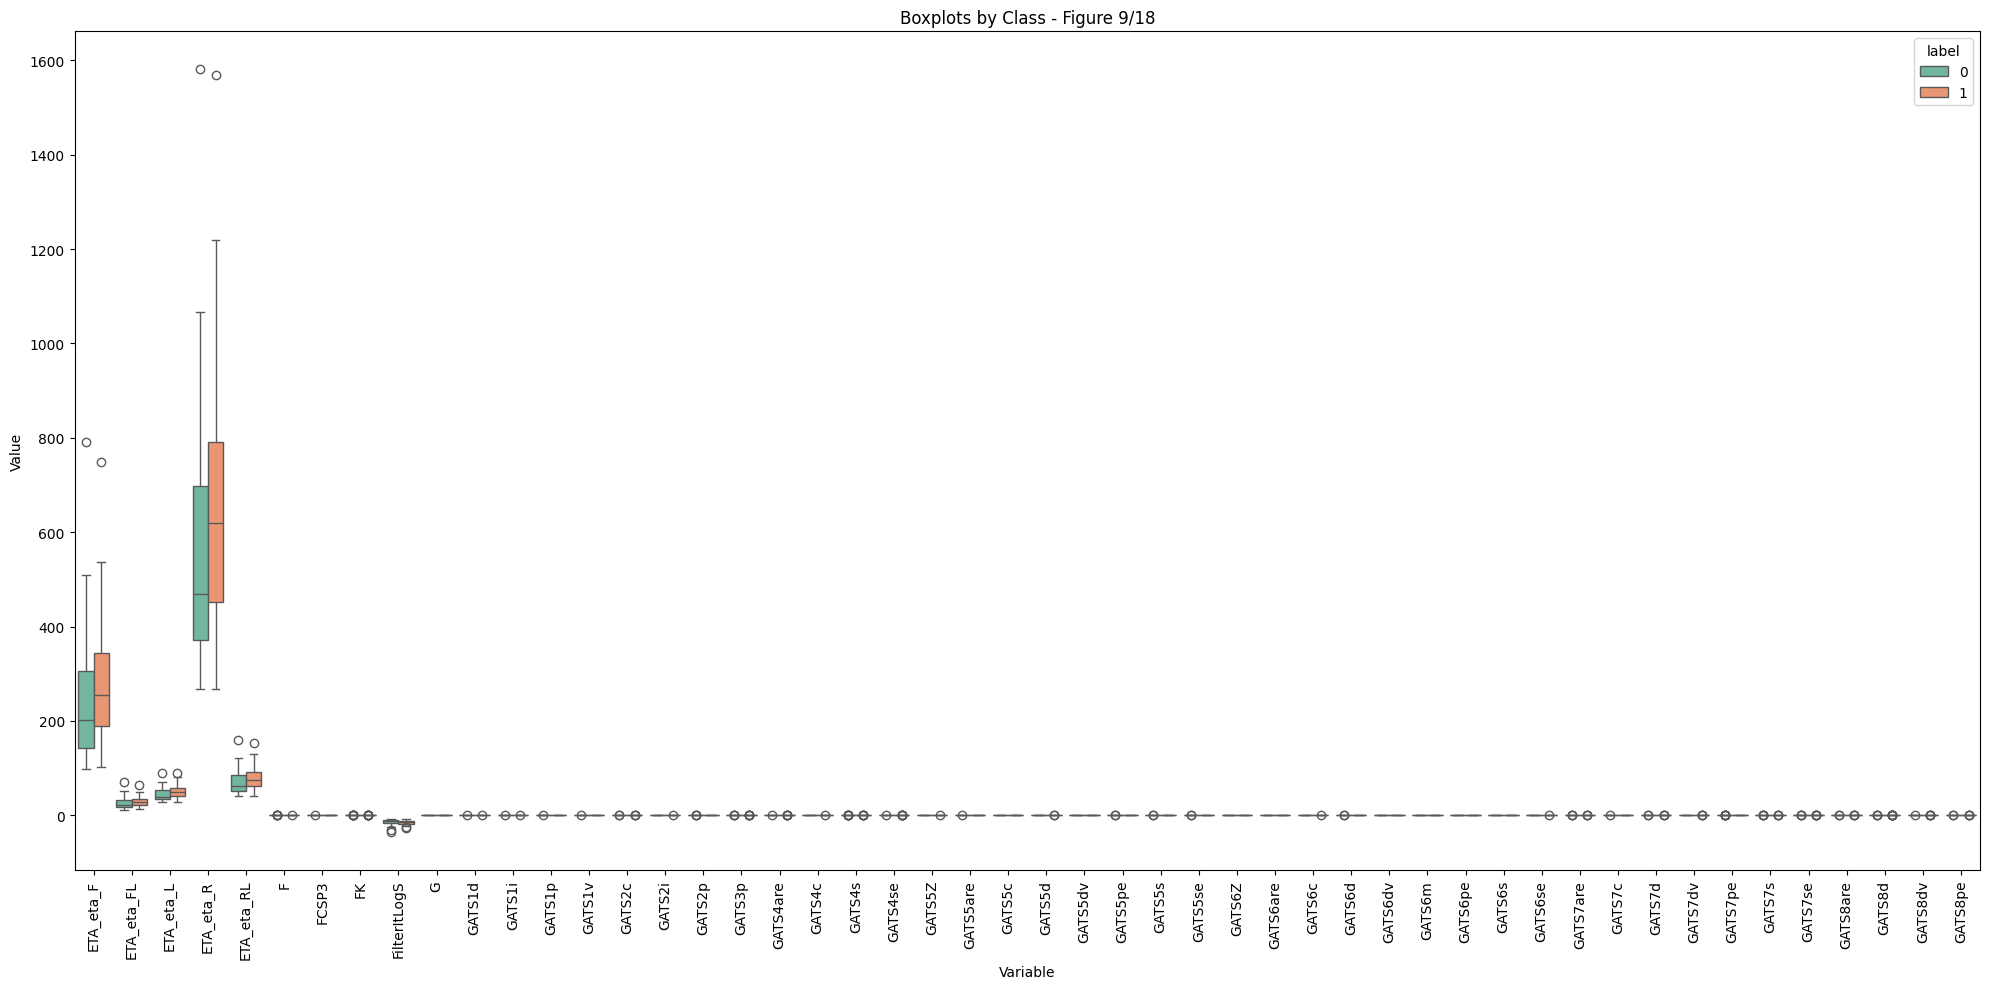

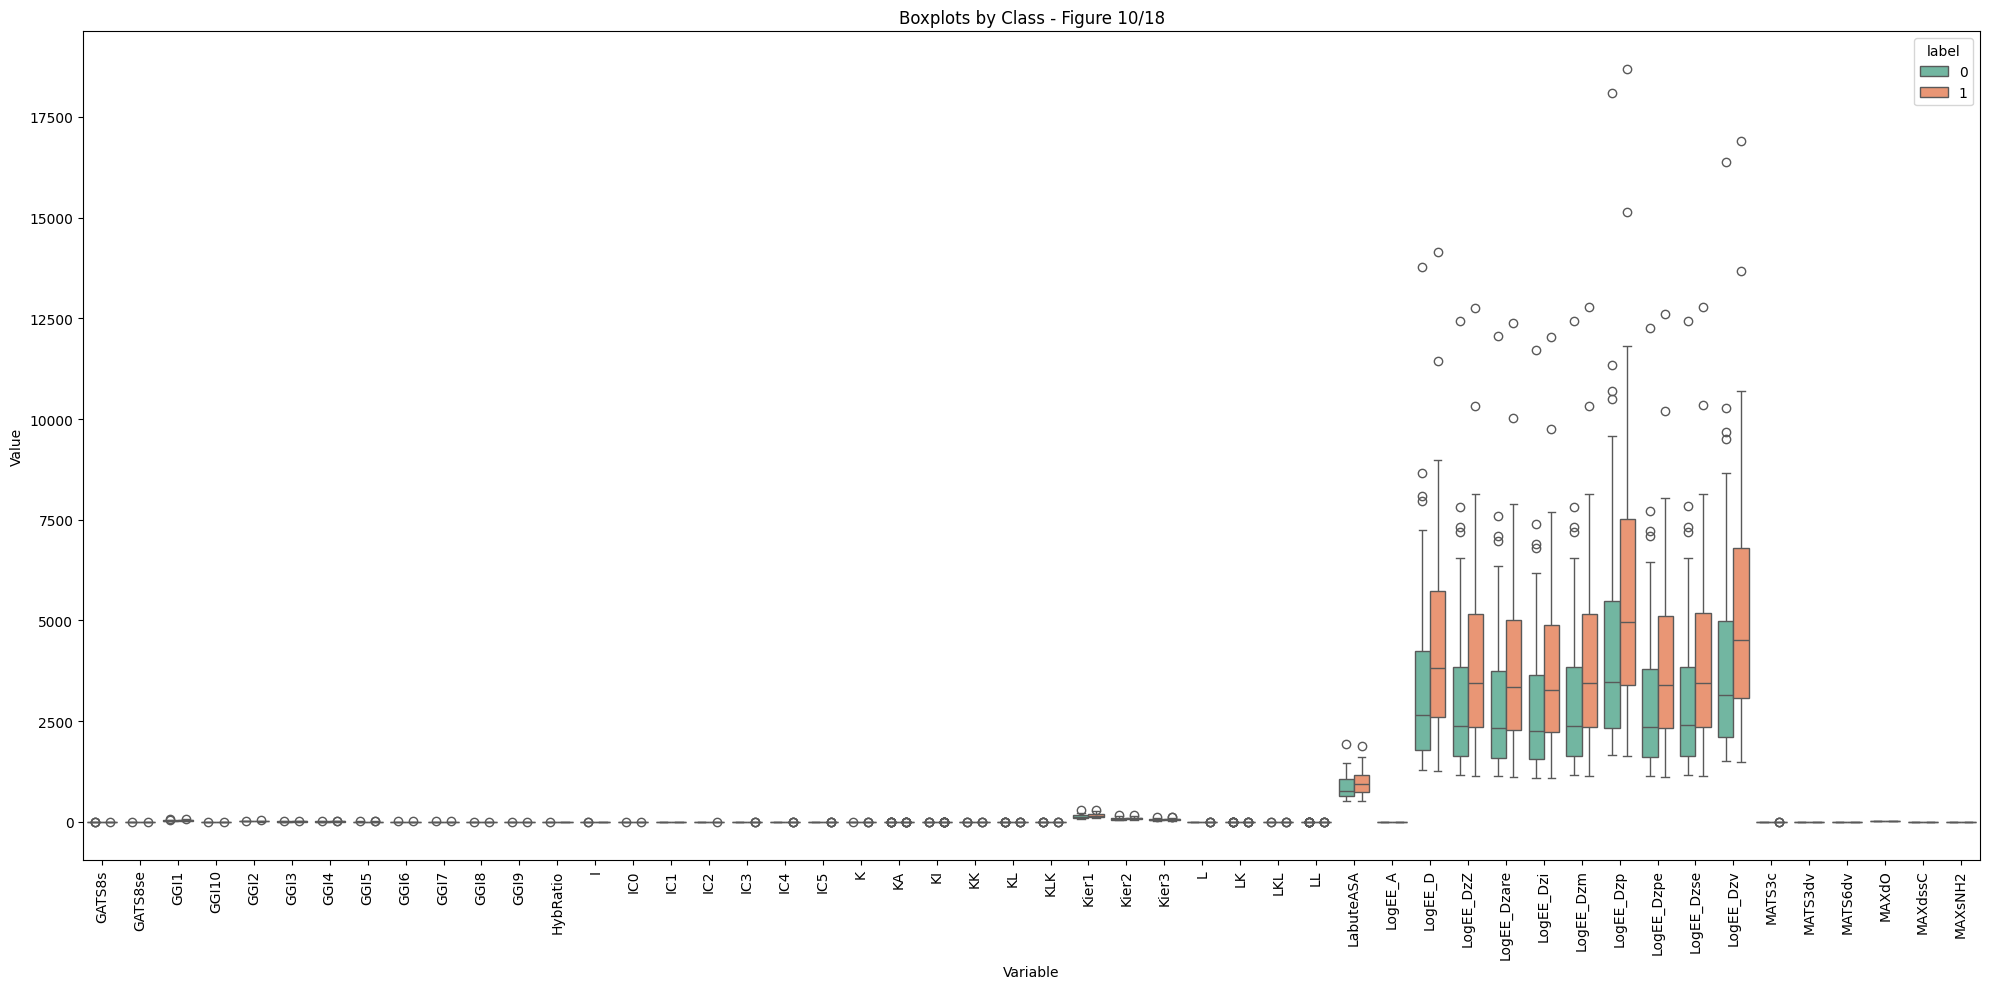

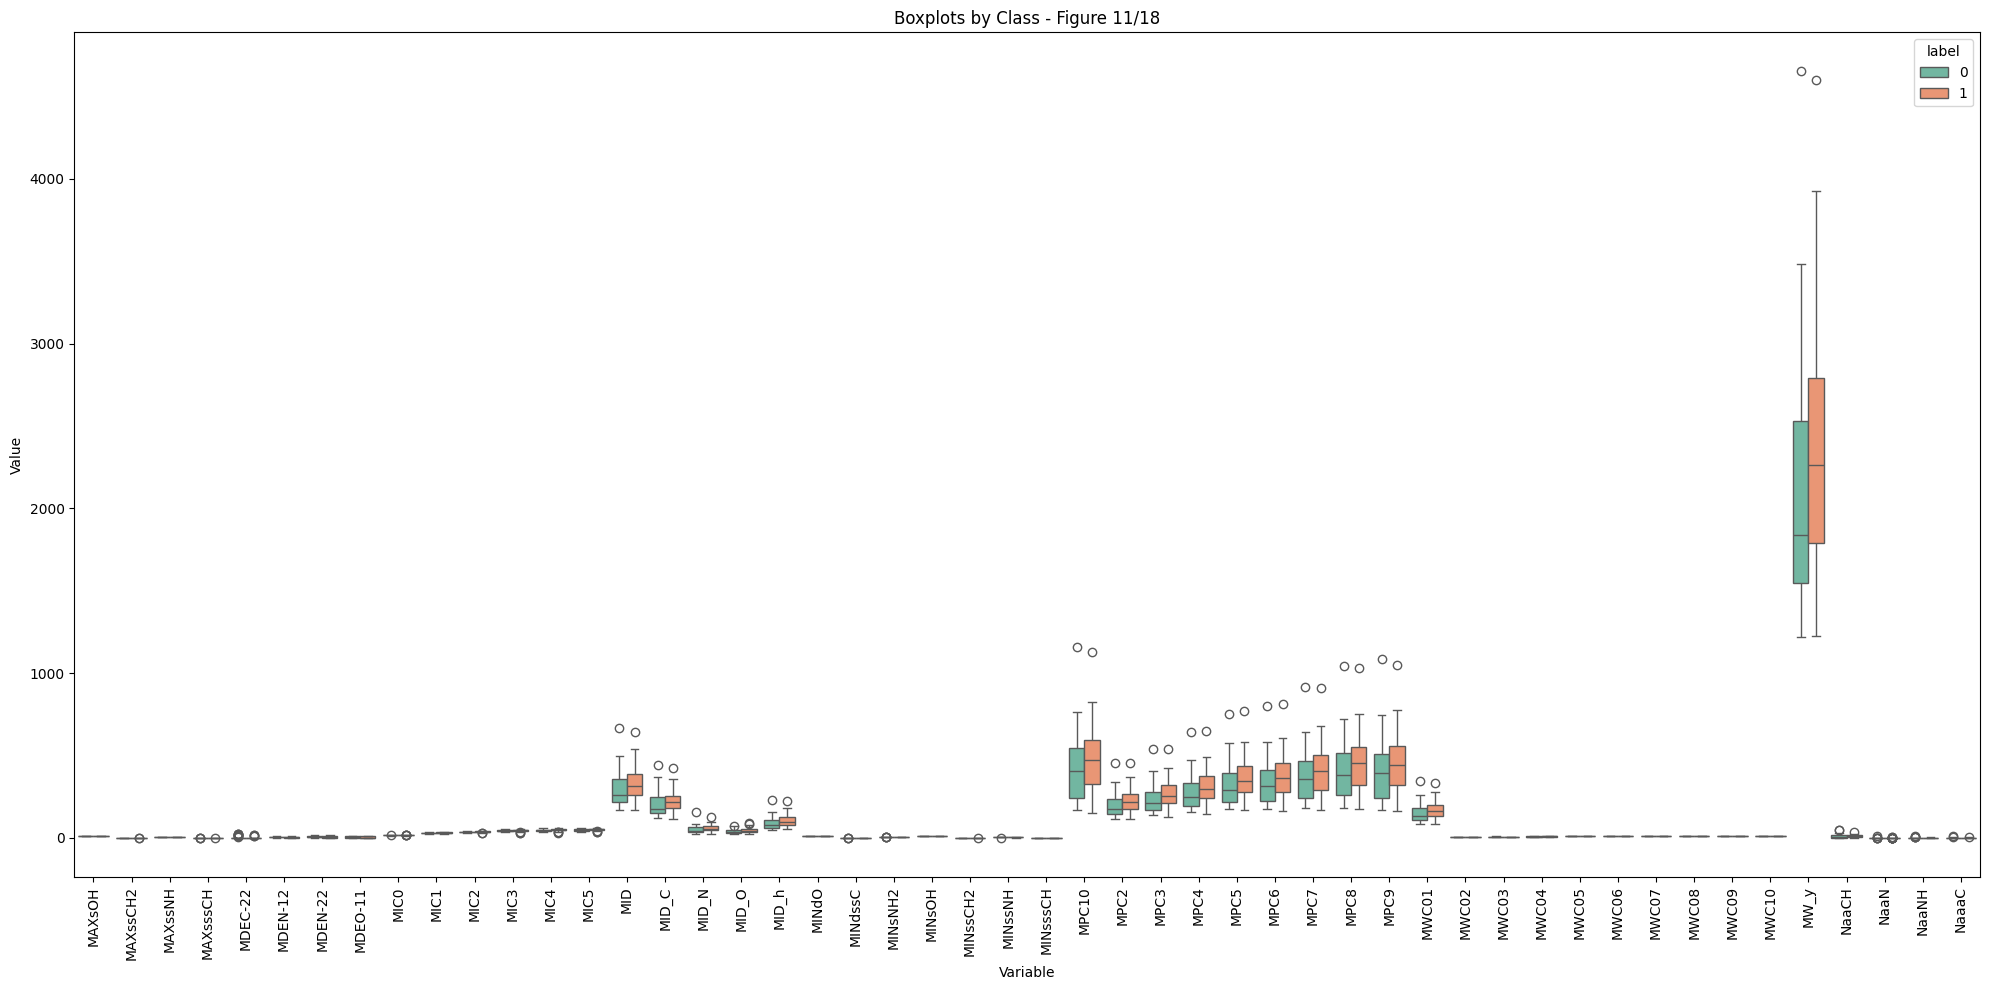

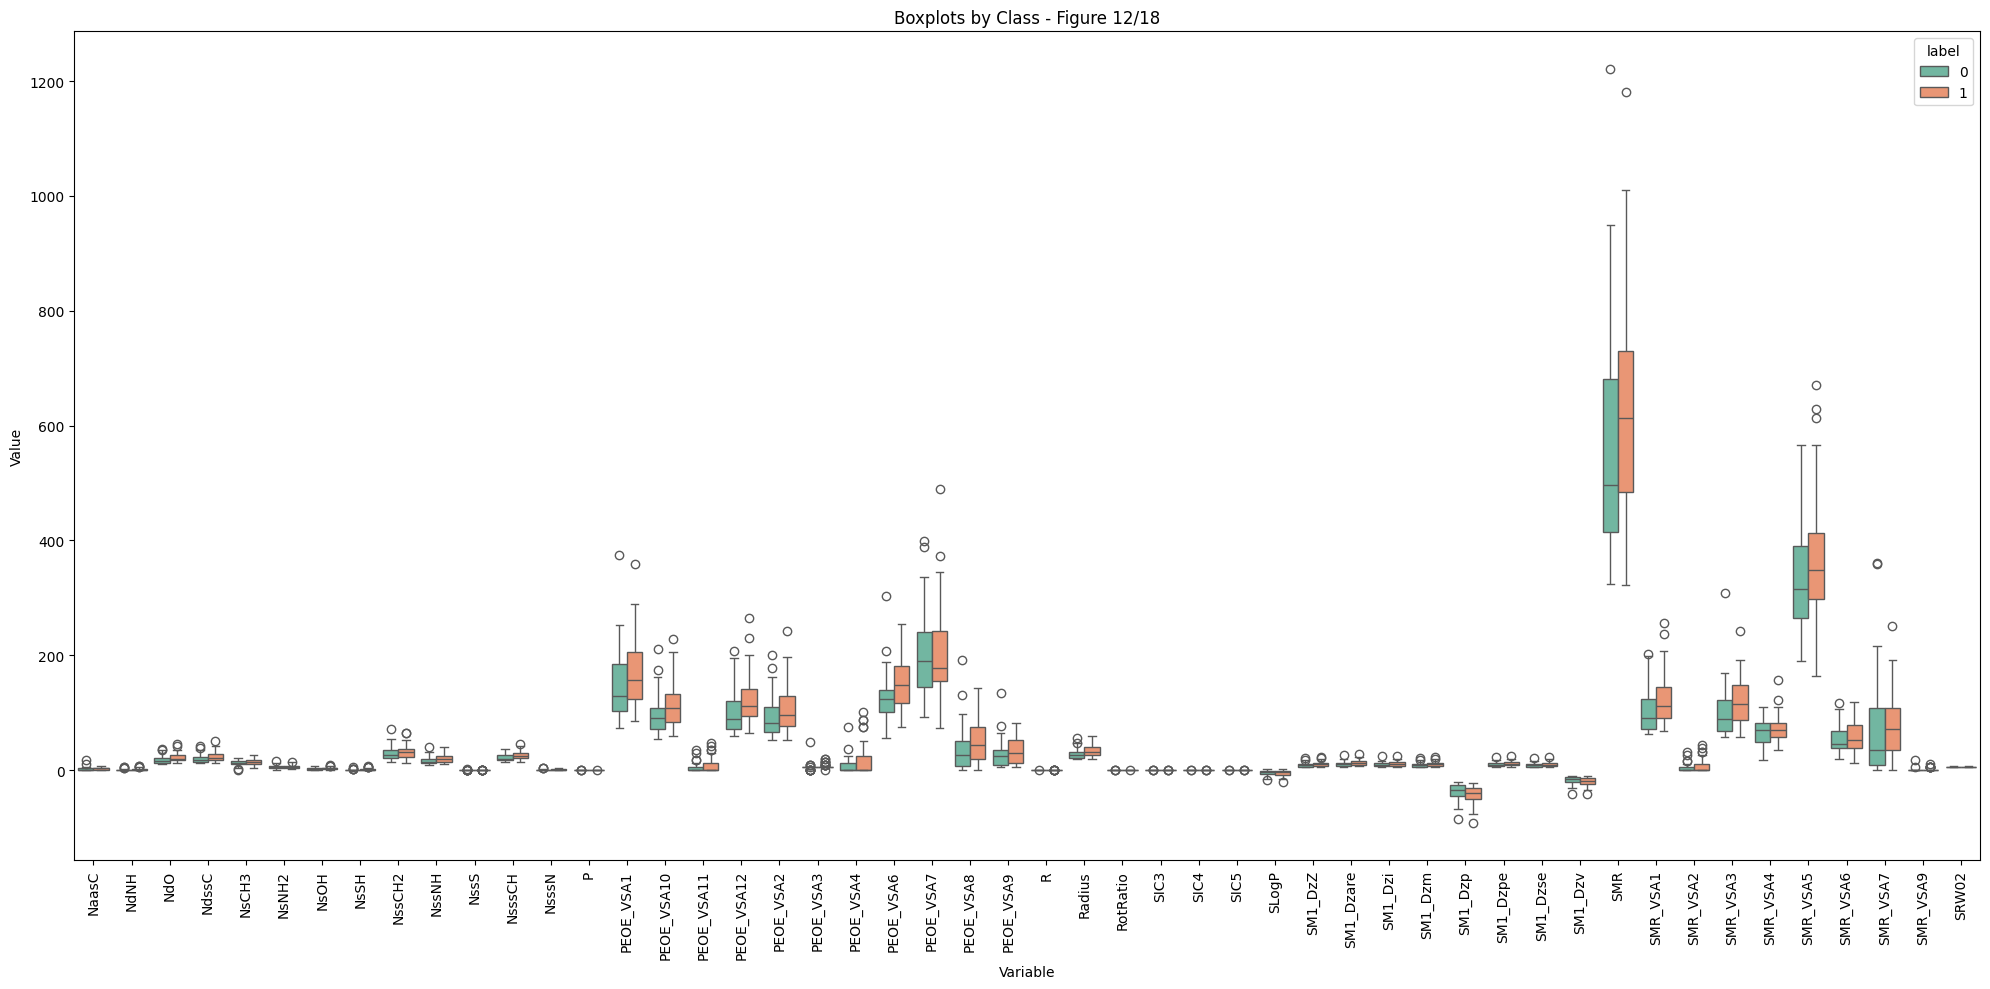

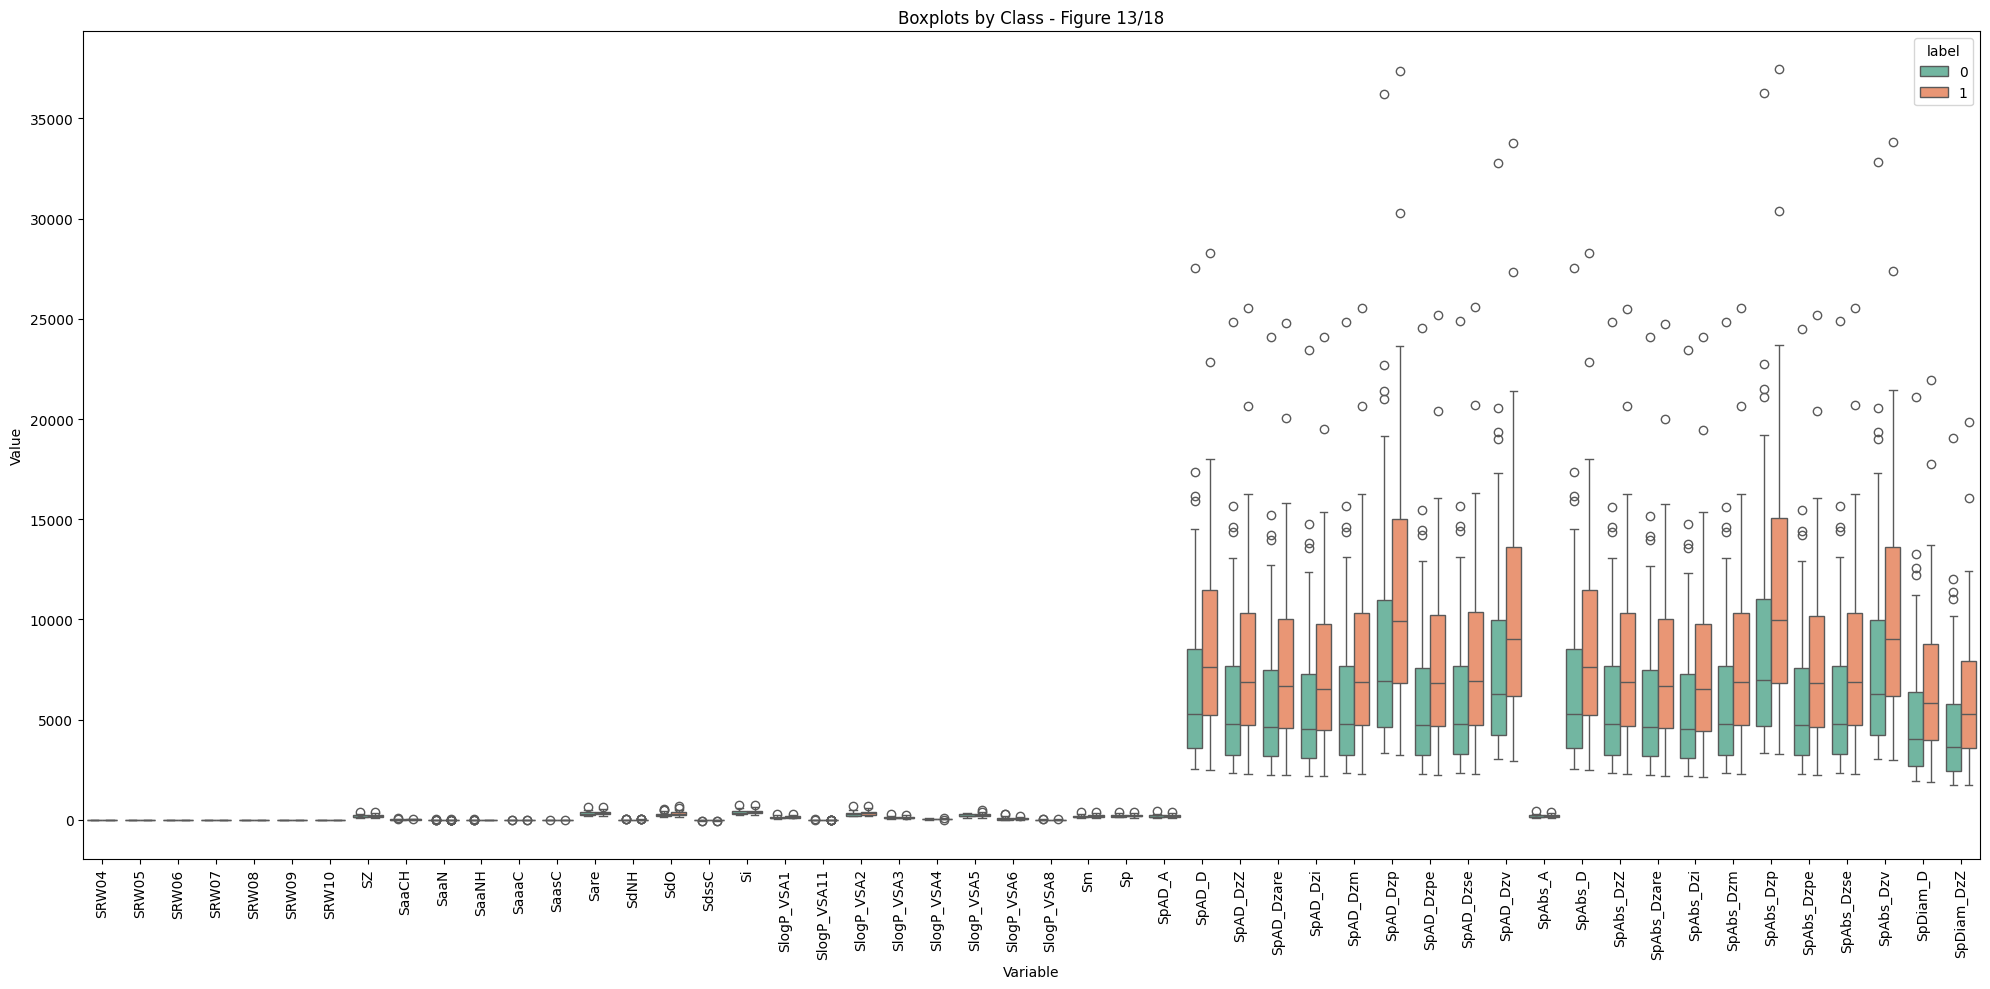

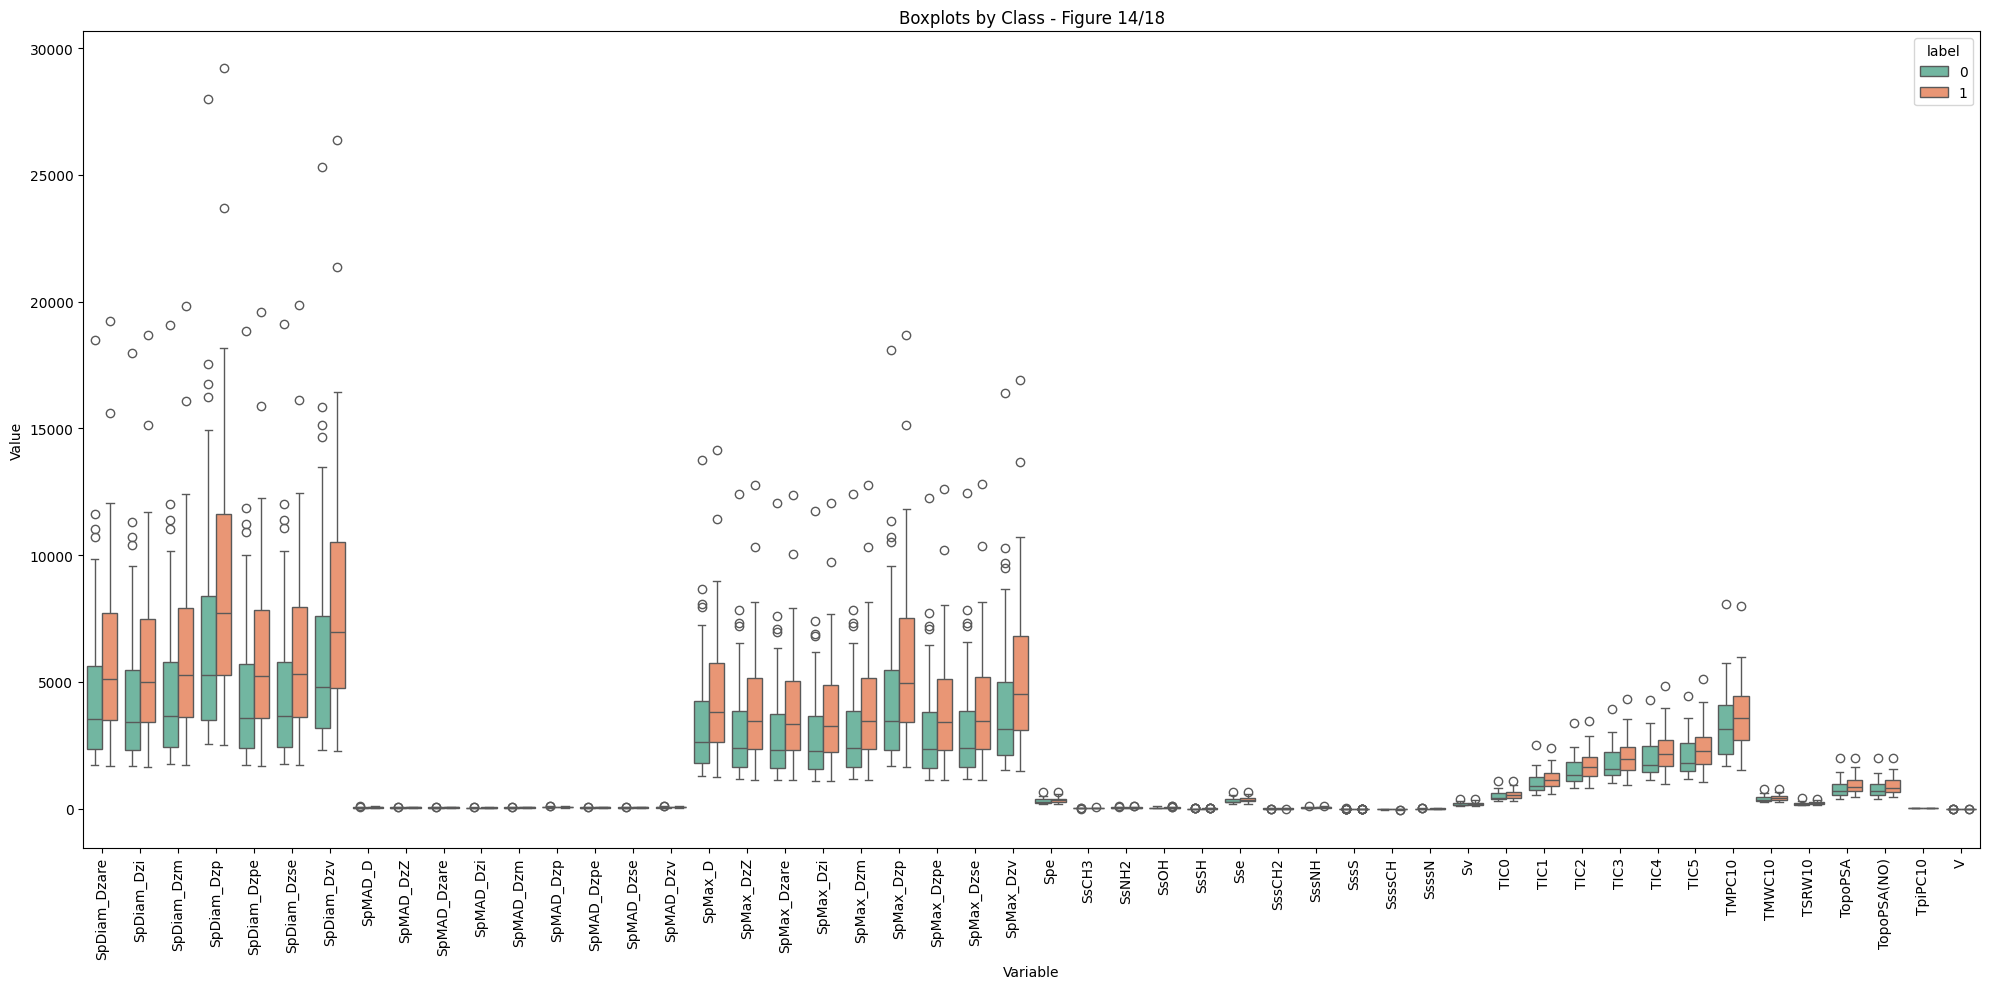

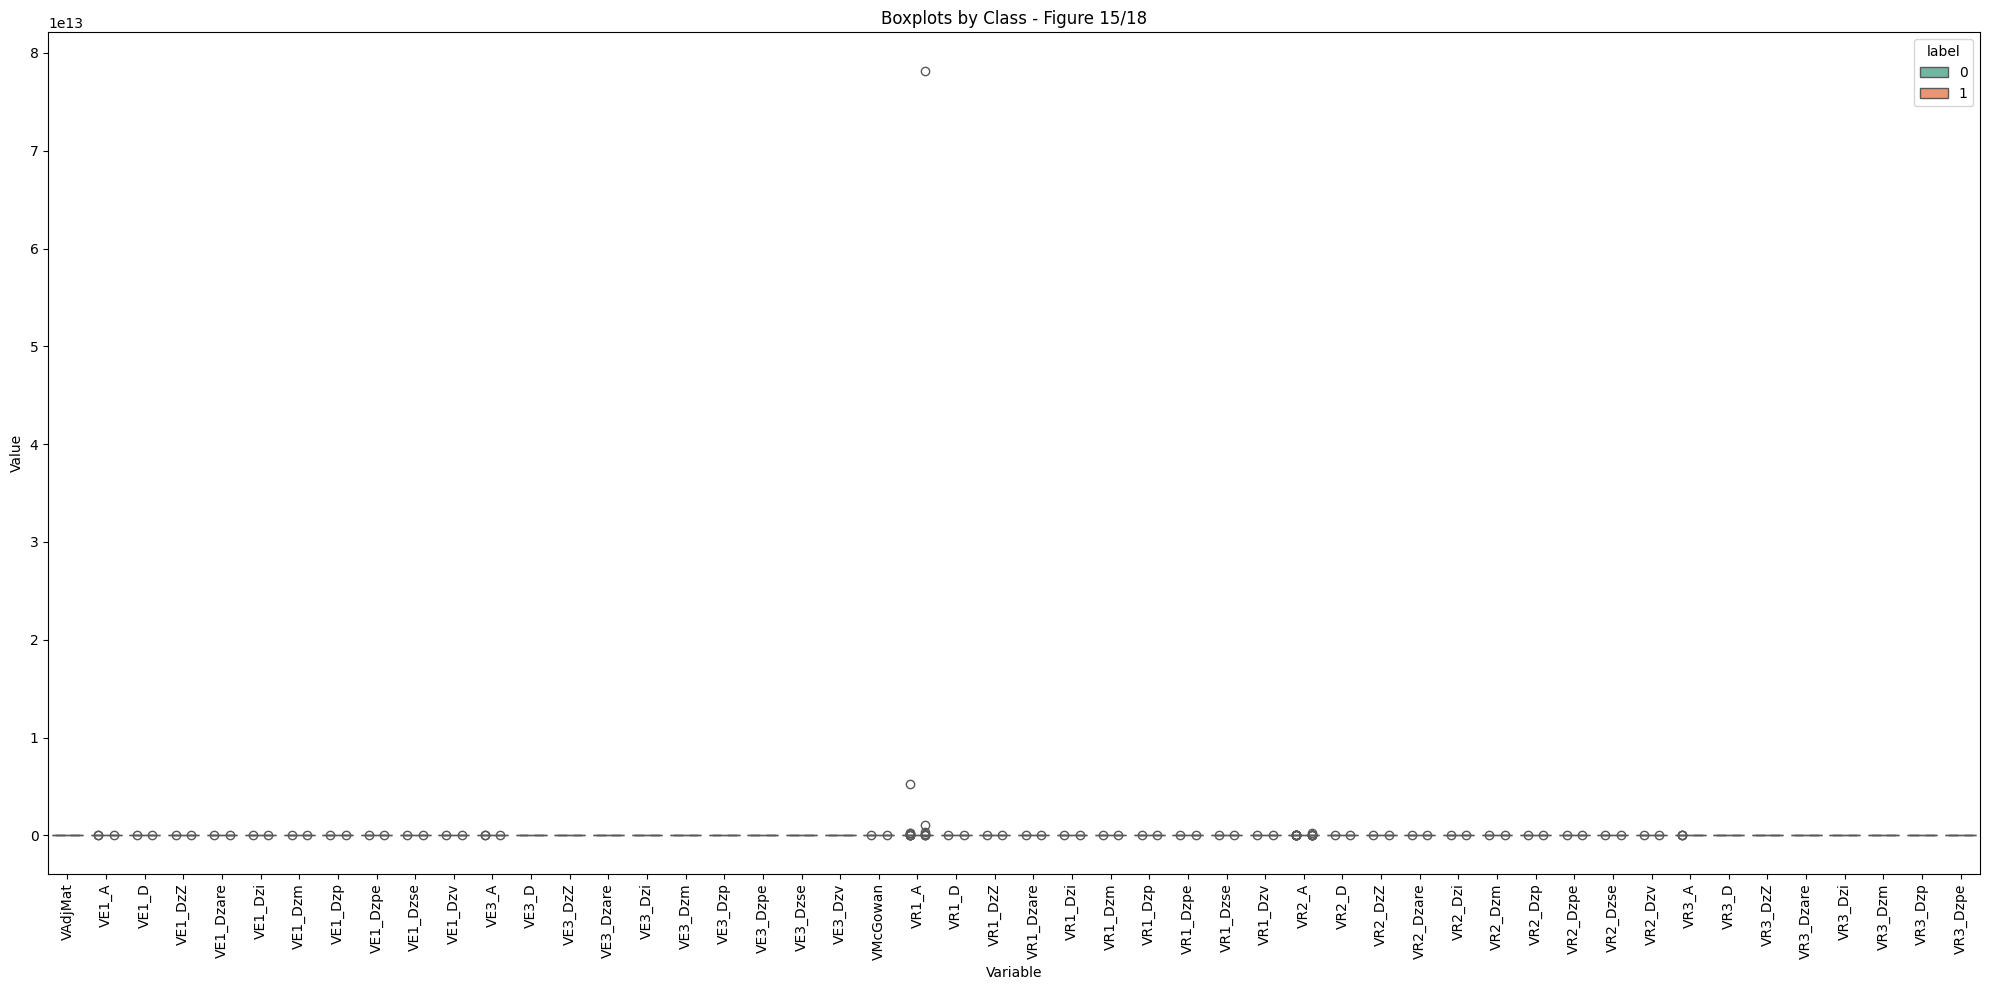

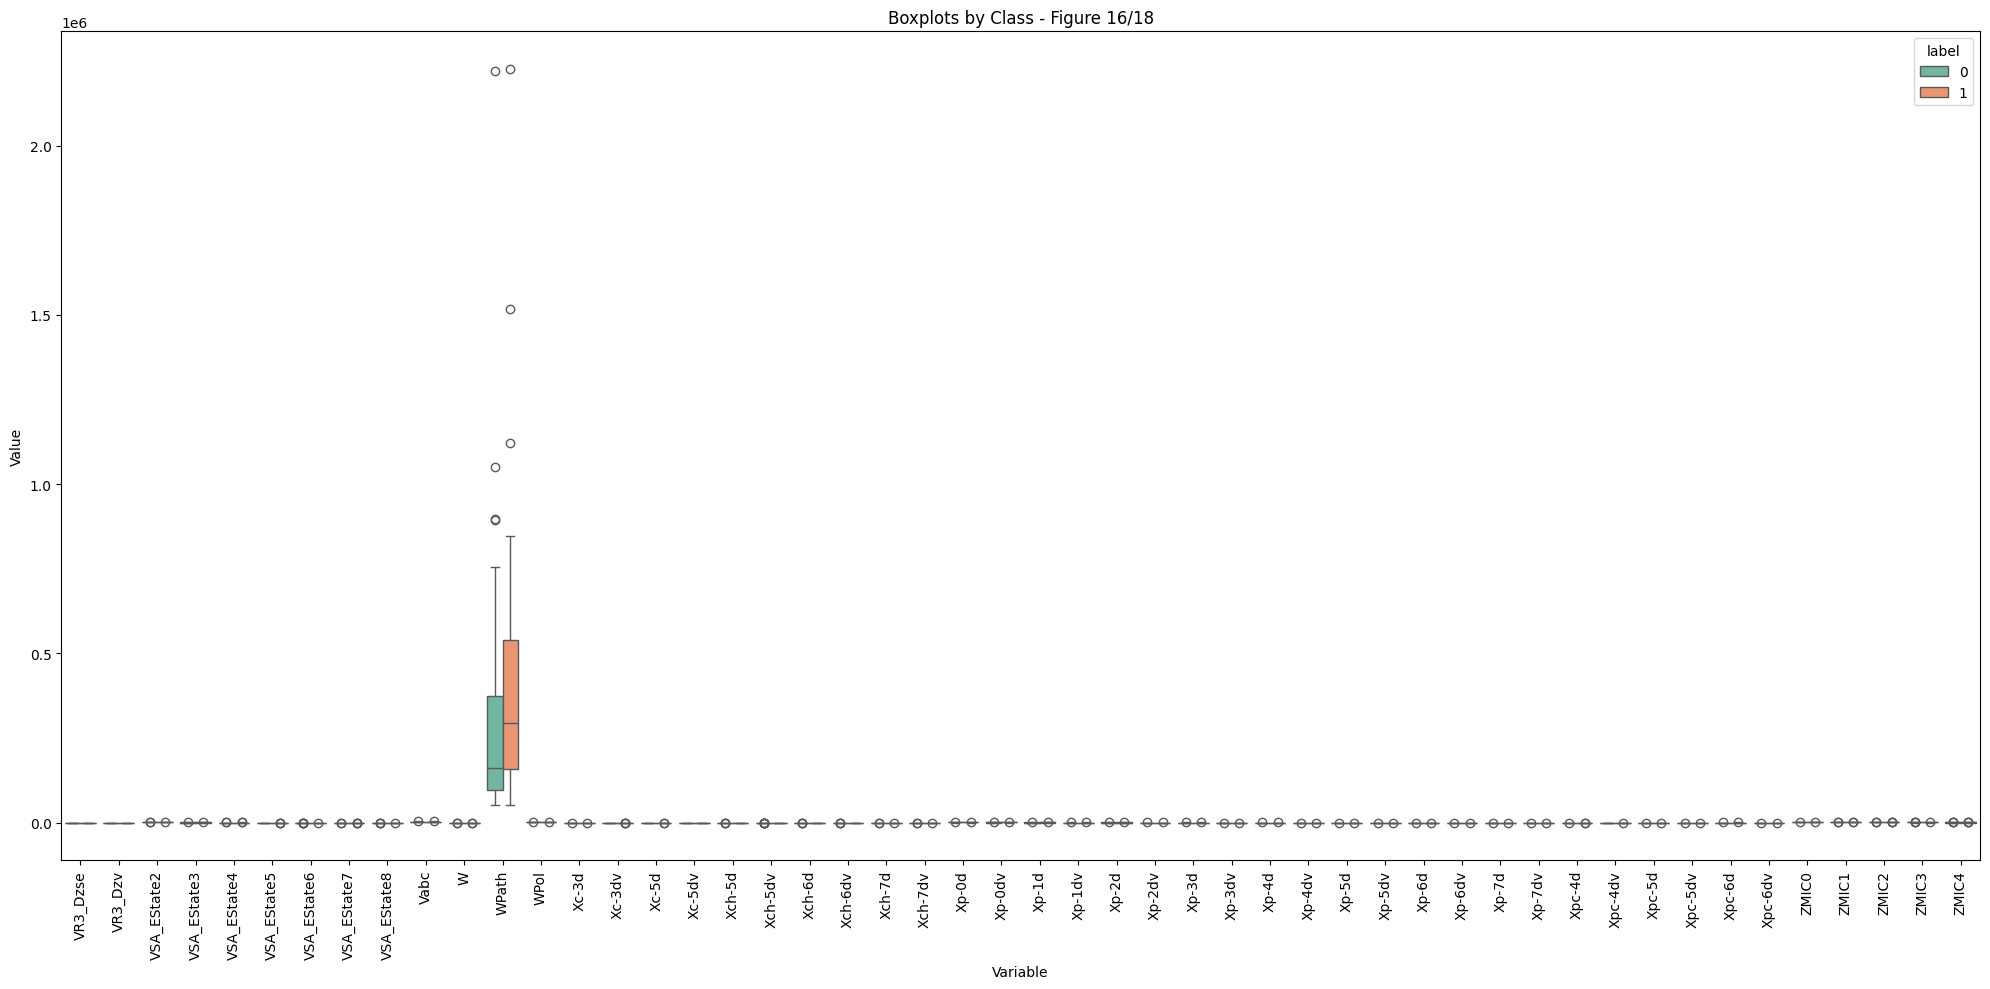

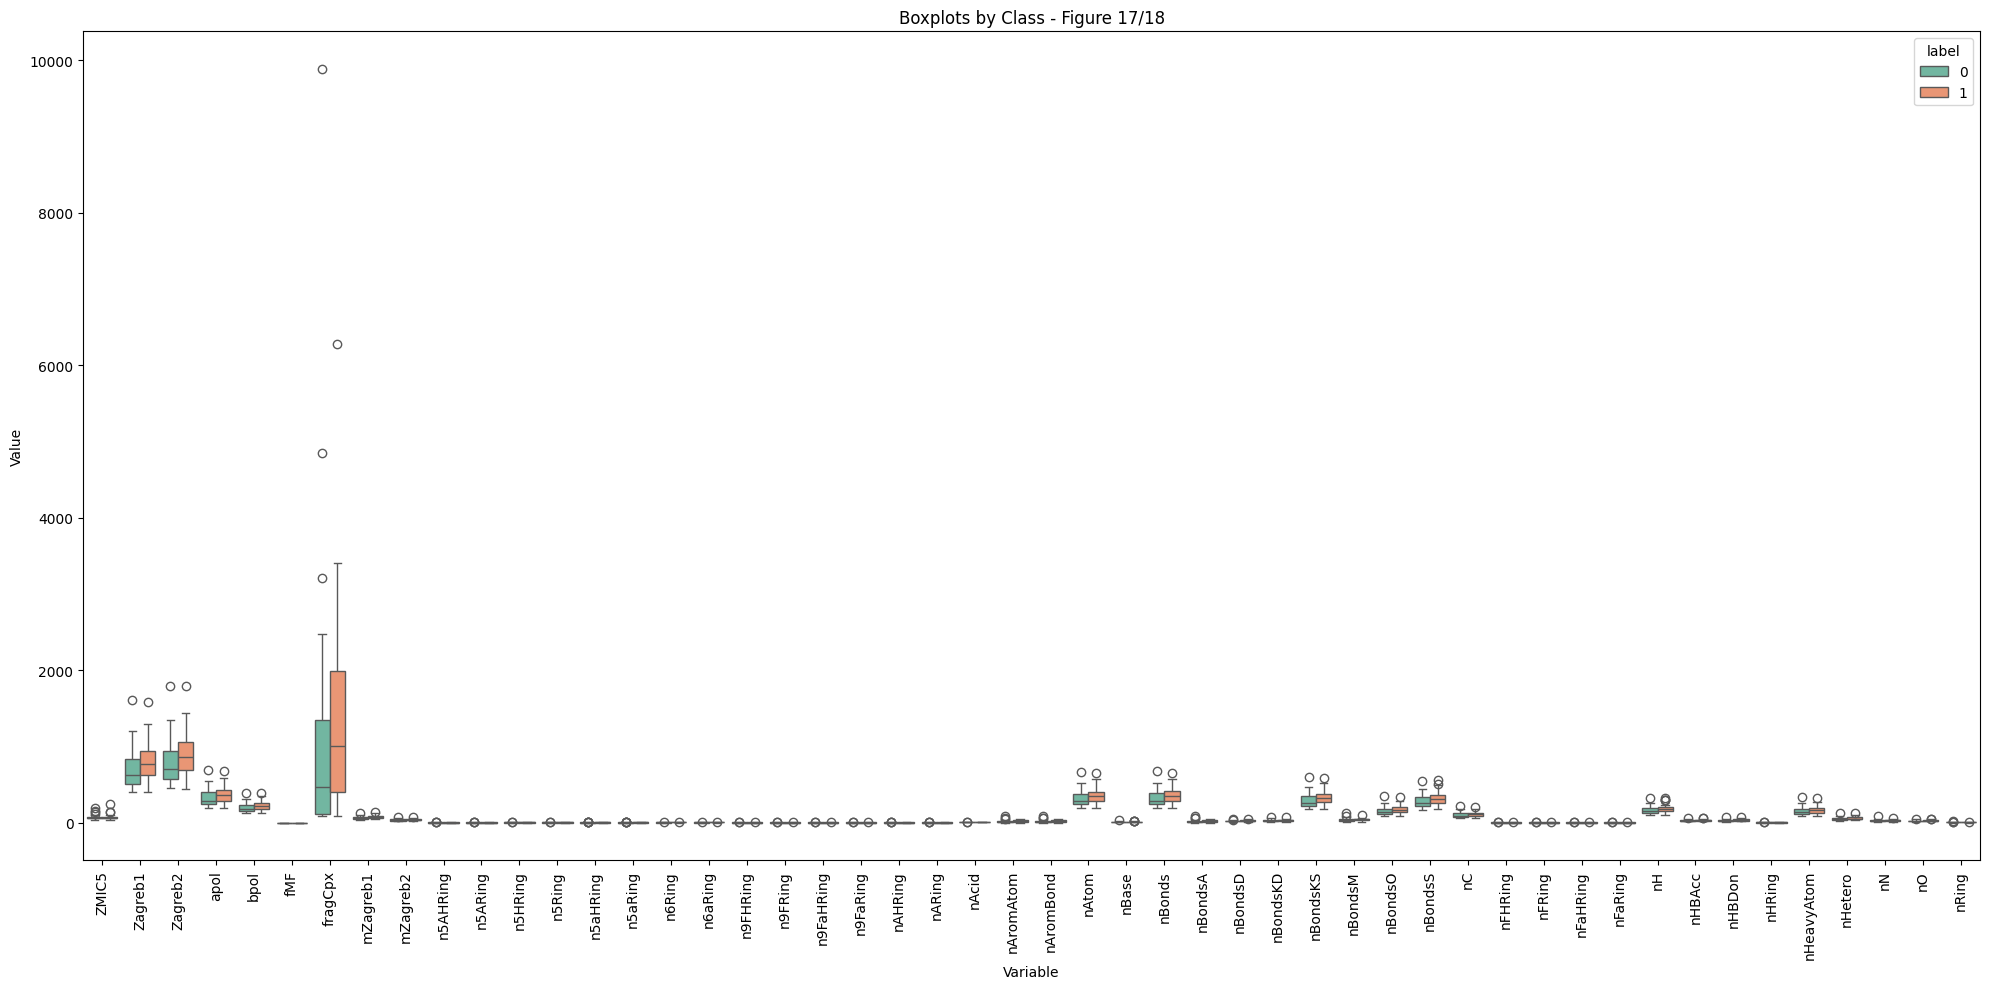

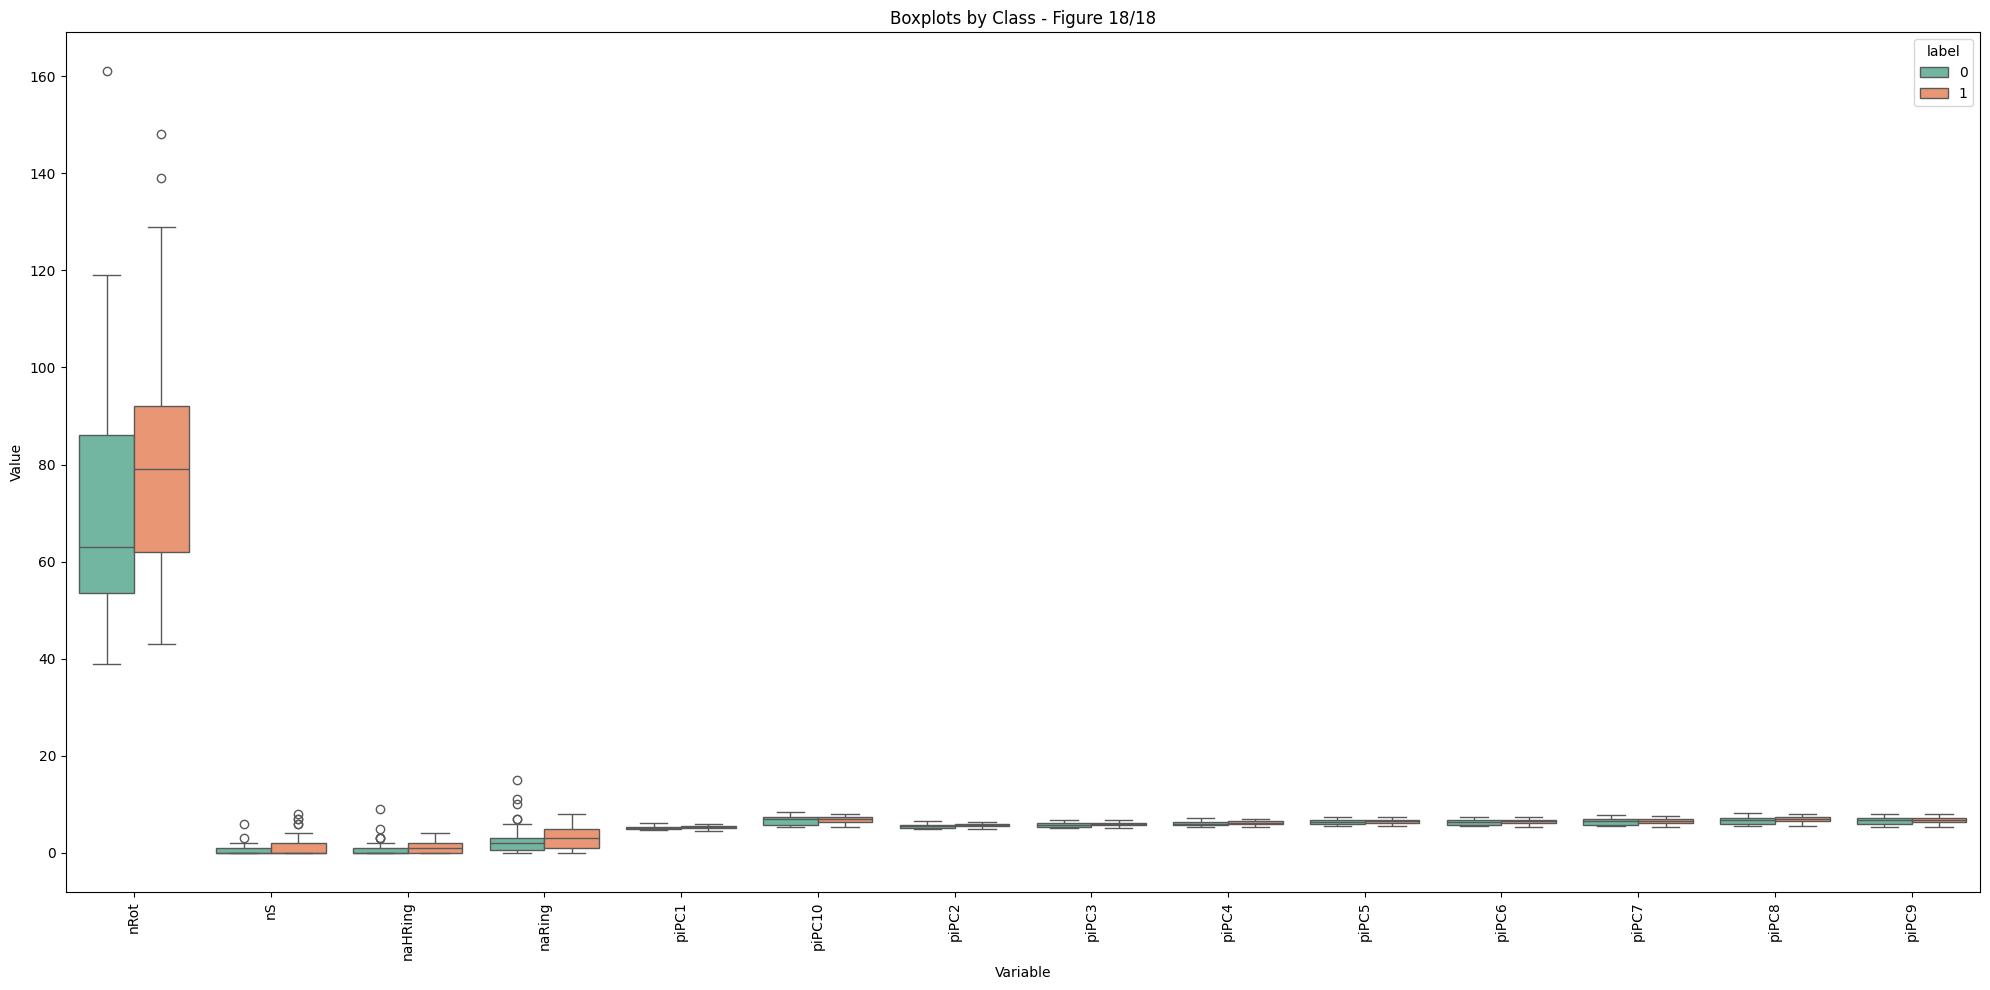

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math



def plot_boxplots_by_class(df, label_col='label', exclude_cols=None, std_threshold=0.05, vars_per_fig=50):
    if exclude_cols is None:
        exclude_cols = []
    
    # 1. Select numeric columns except excluded
    numeric_cols = df.select_dtypes(include=['number']).columns.difference(exclude_cols)
    
    # 2. Filter variables with std >= threshold
    filtered_vars = [col for col in numeric_cols if df[col].std() >= std_threshold]
    
    # 3. Calculate number of figures needed
    num_figs = math.ceil(len(filtered_vars) / vars_per_fig)
    
    # 4. Plot
    for fig_idx in range(num_figs):
        cols_to_plot = filtered_vars[fig_idx * vars_per_fig : (fig_idx + 1) * vars_per_fig]
        
        # Melt for seaborn
        df_melt = df[[label_col] + cols_to_plot].melt(id_vars=label_col, var_name='Variable', value_name='Value')
        
        plt.figure(figsize=(20, 10))
        sns.boxplot(
            data=df_melt,
            x='Variable',
            y='Value',
            hue=label_col,
            palette='Set2'
        )
        plt.xticks(rotation=90)
        plt.title(f'Boxplots by Class - Figure {fig_idx+1}/{num_figs}')
        plt.tight_layout()
        plt.show()

# Example usage:
exclude_cols = ['μM', 'label', 'SEQUENCE']  # Exclude key & target
plot_boxplots_by_class(df_filtered, label_col='label', exclude_cols=exclude_cols, std_threshold=0.05, vars_per_fig=50)

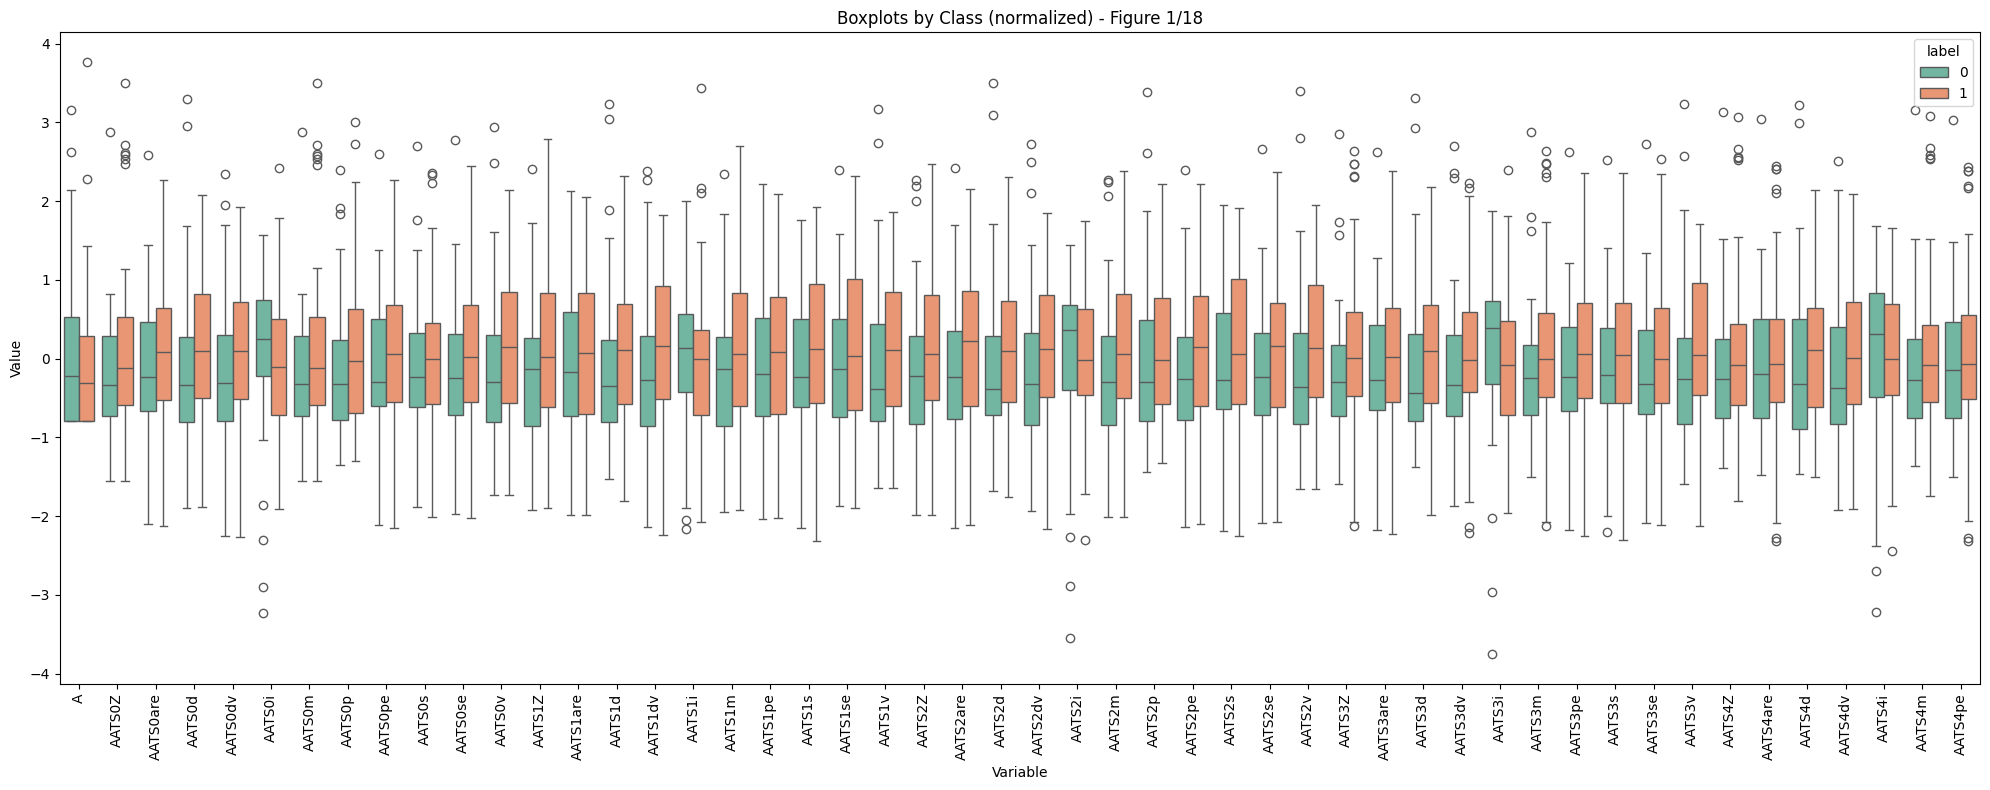

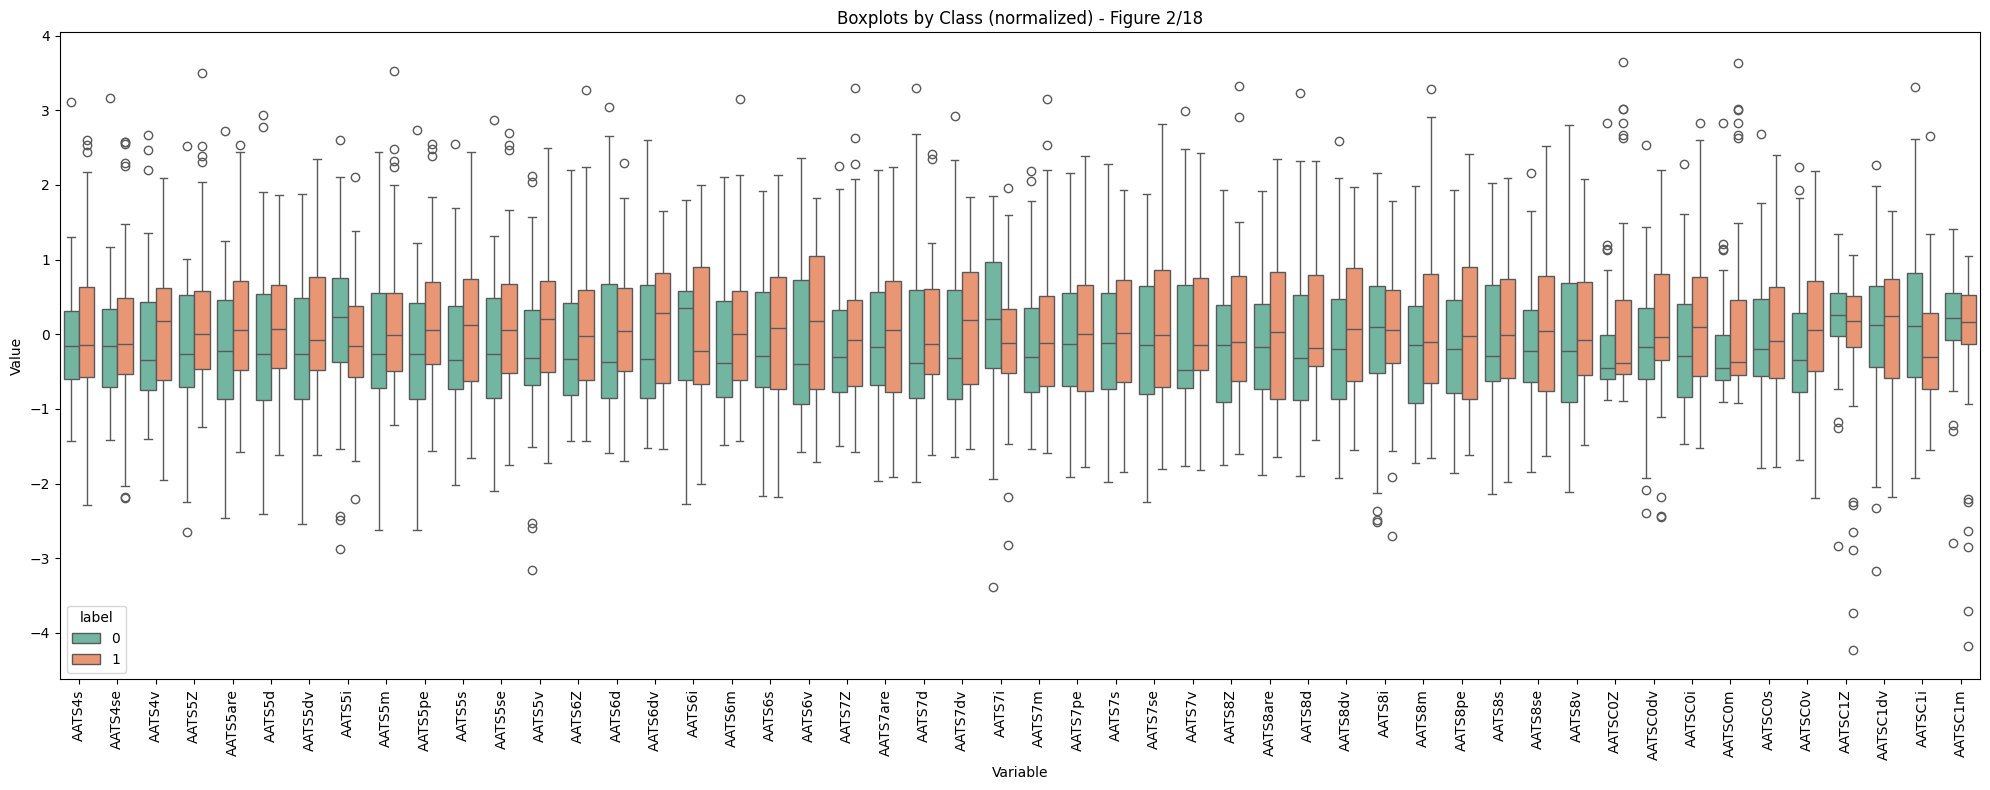

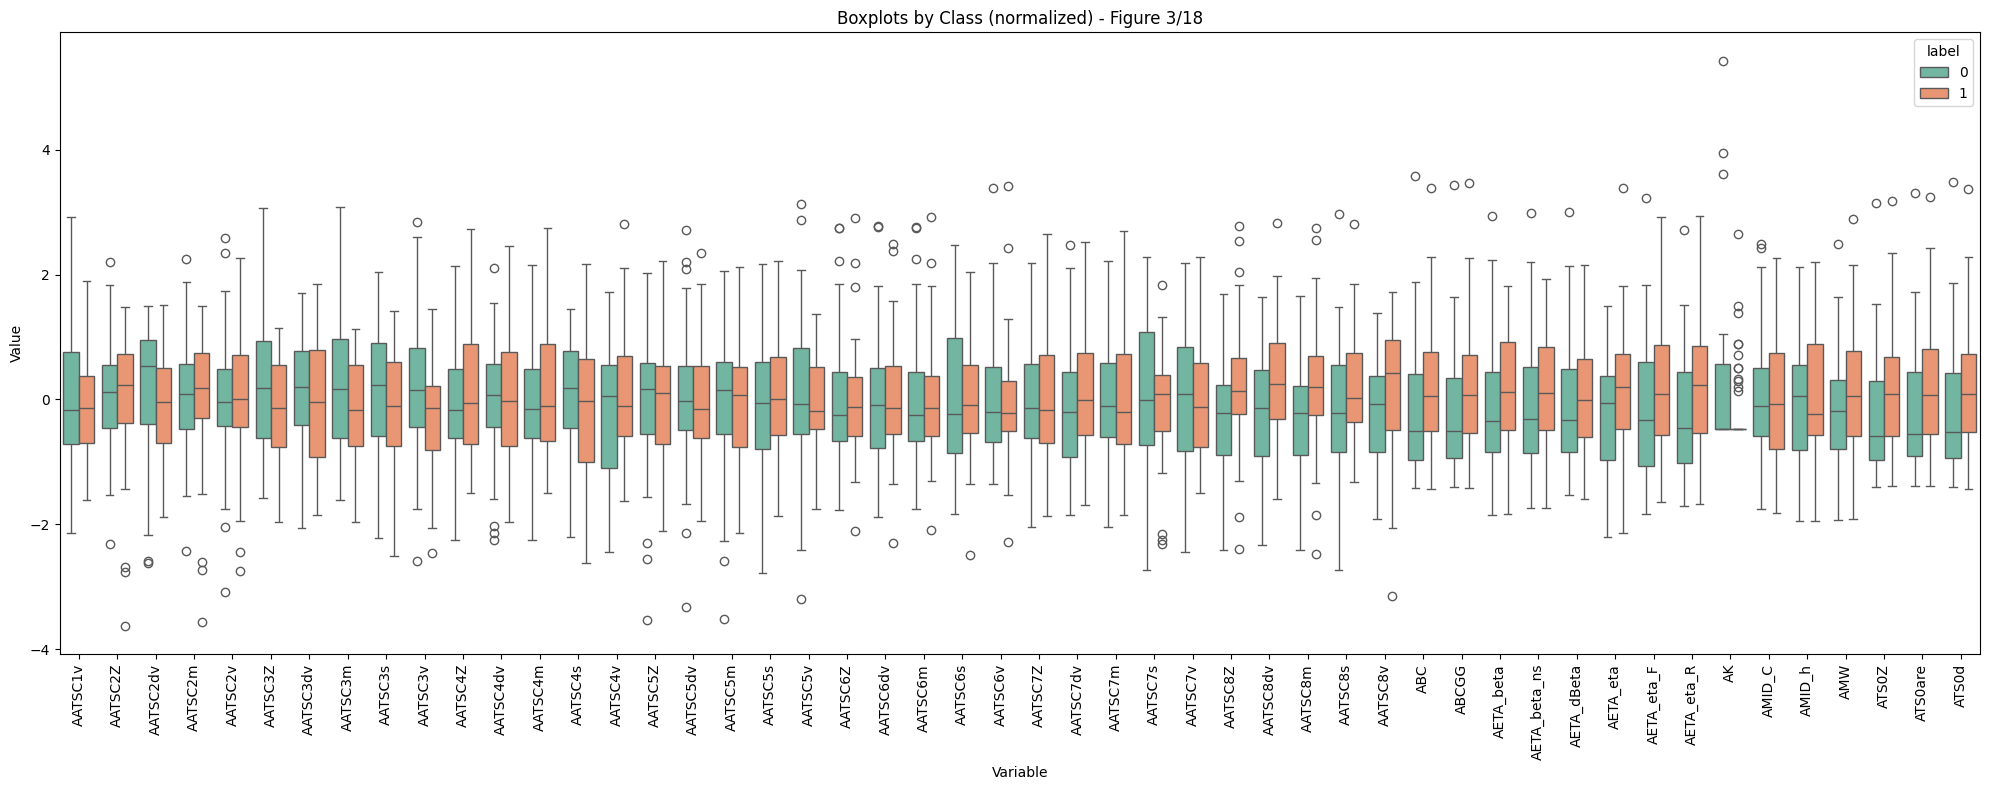

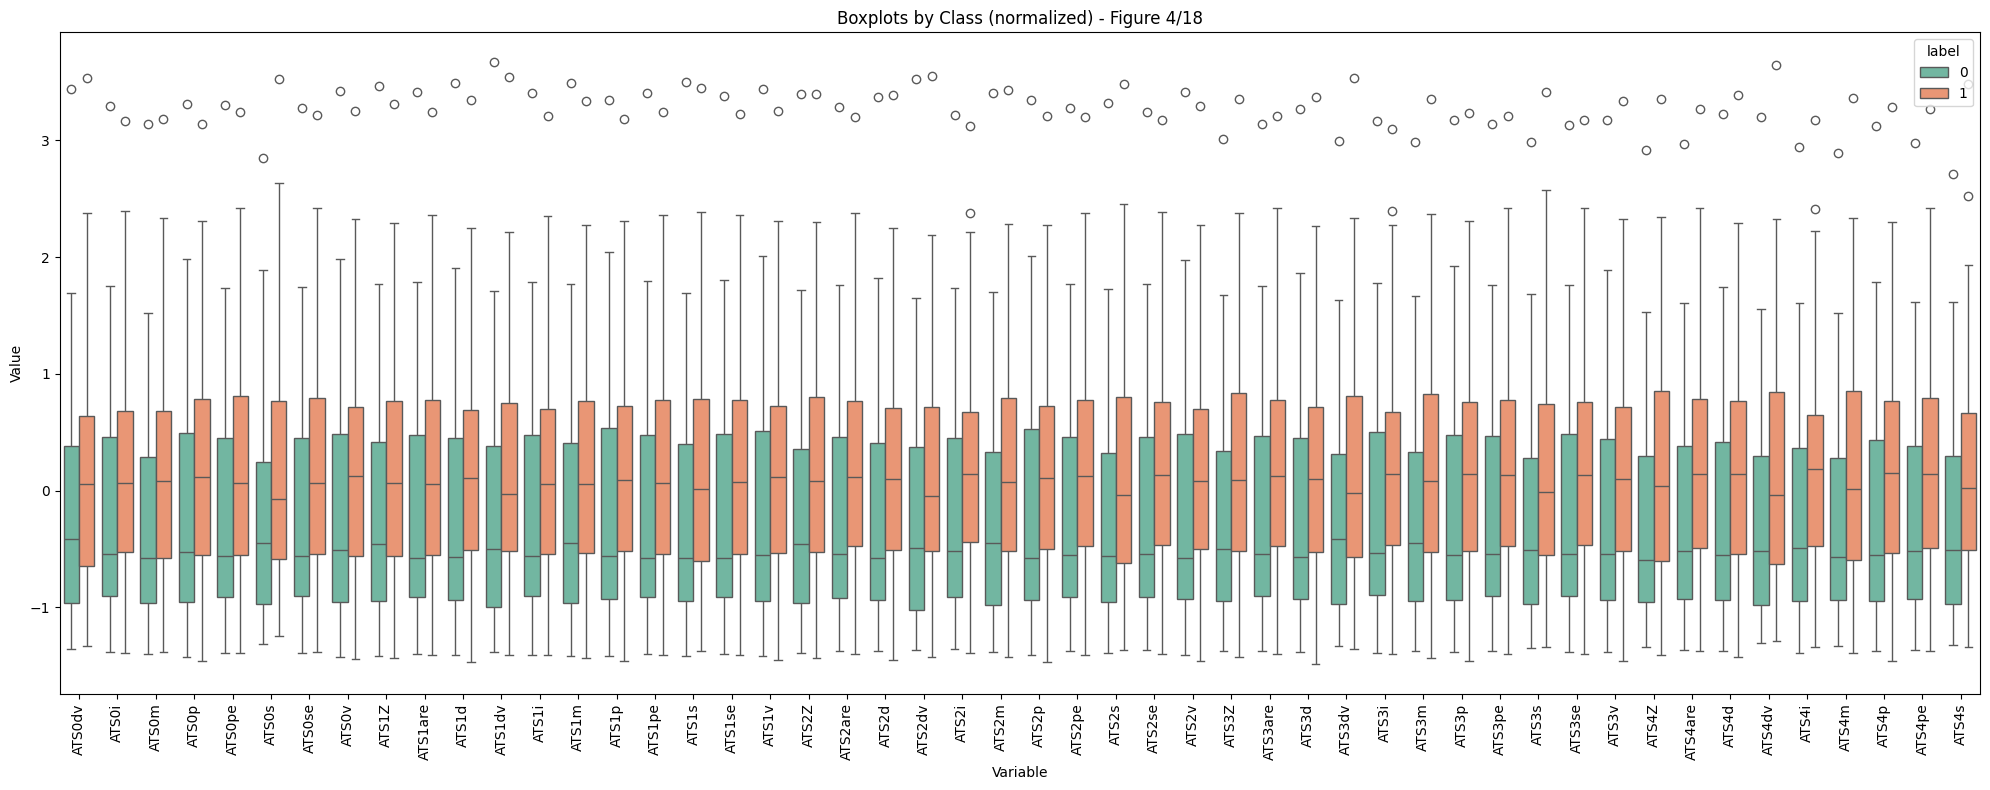

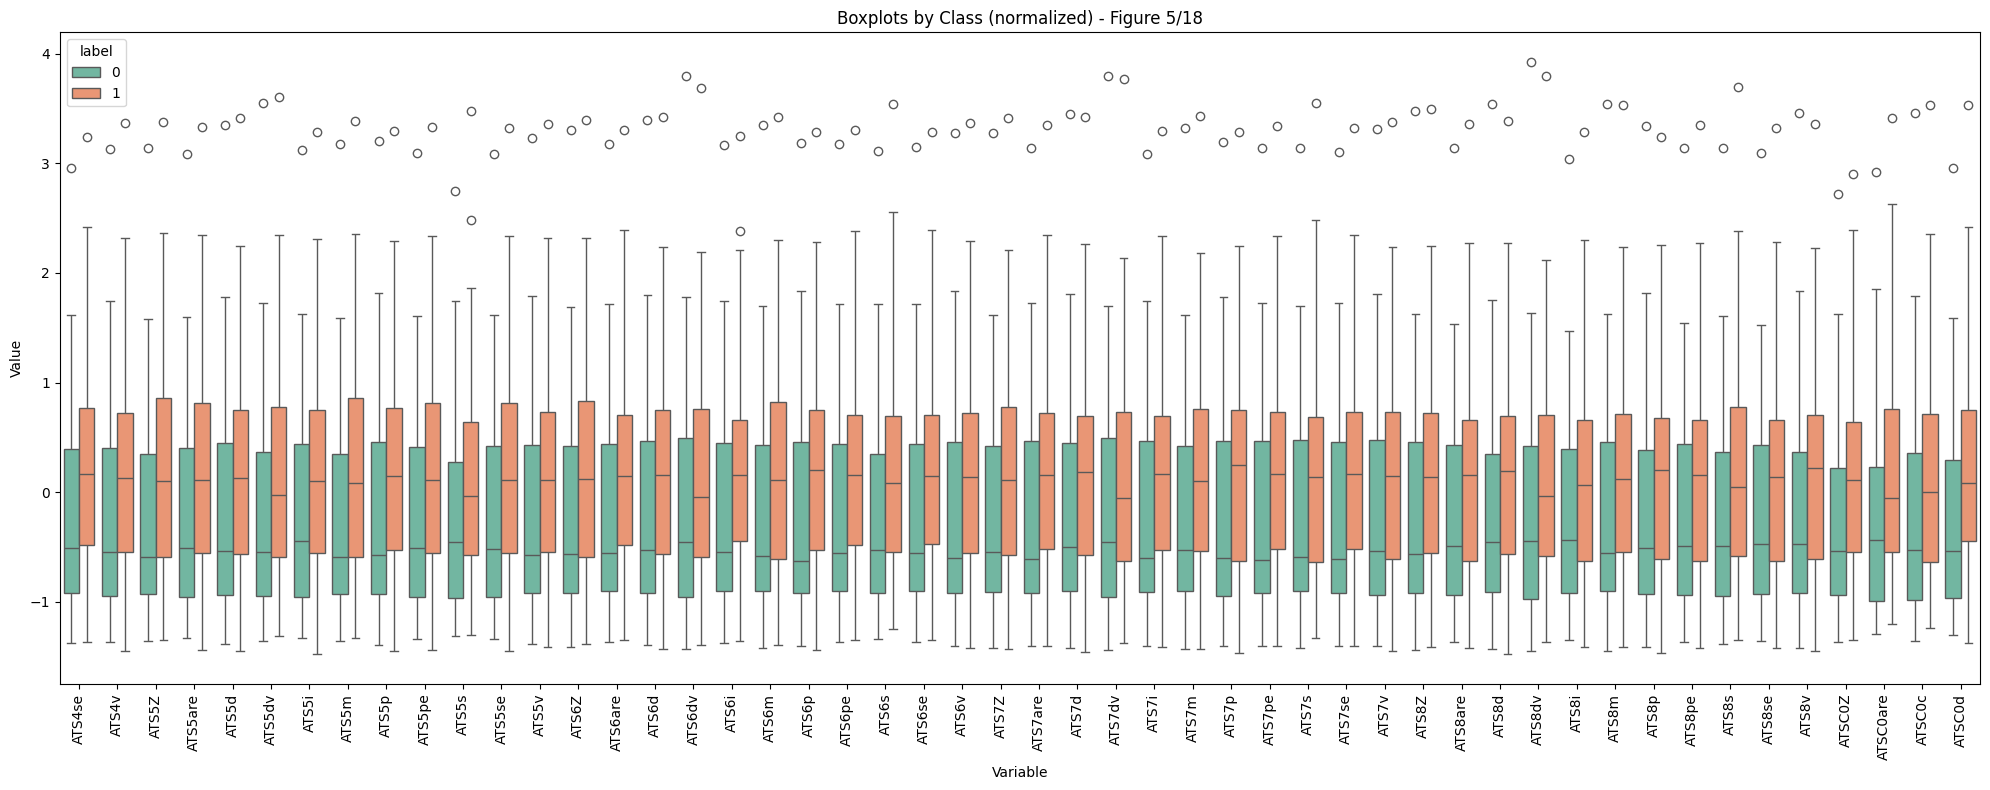

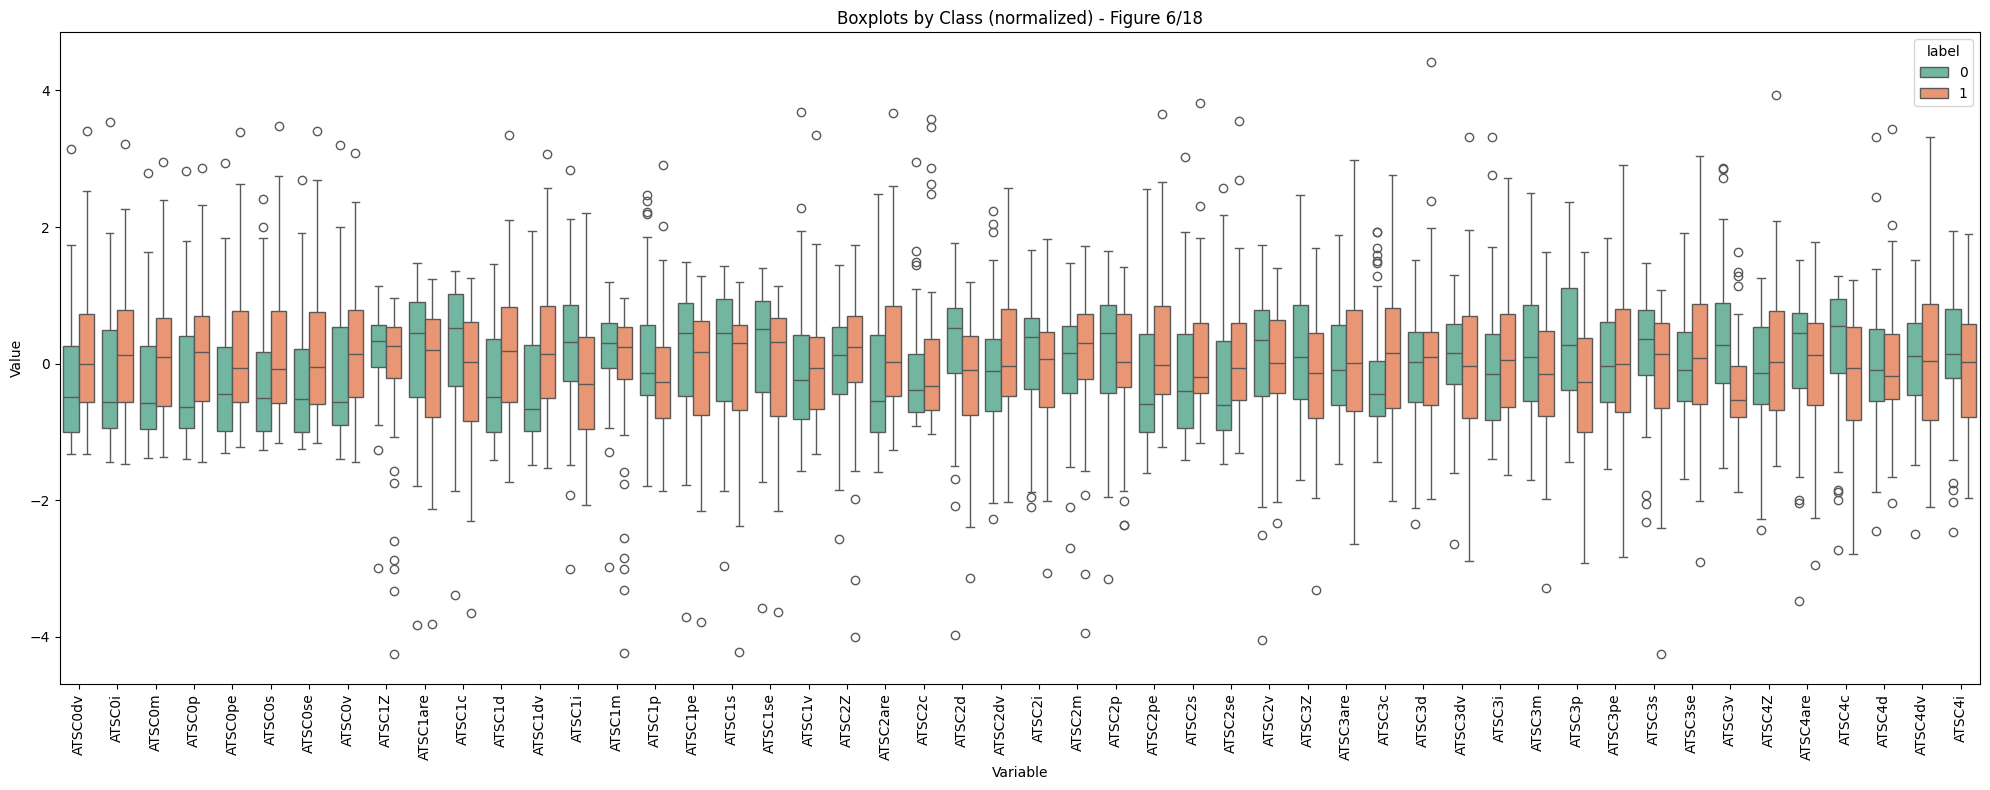

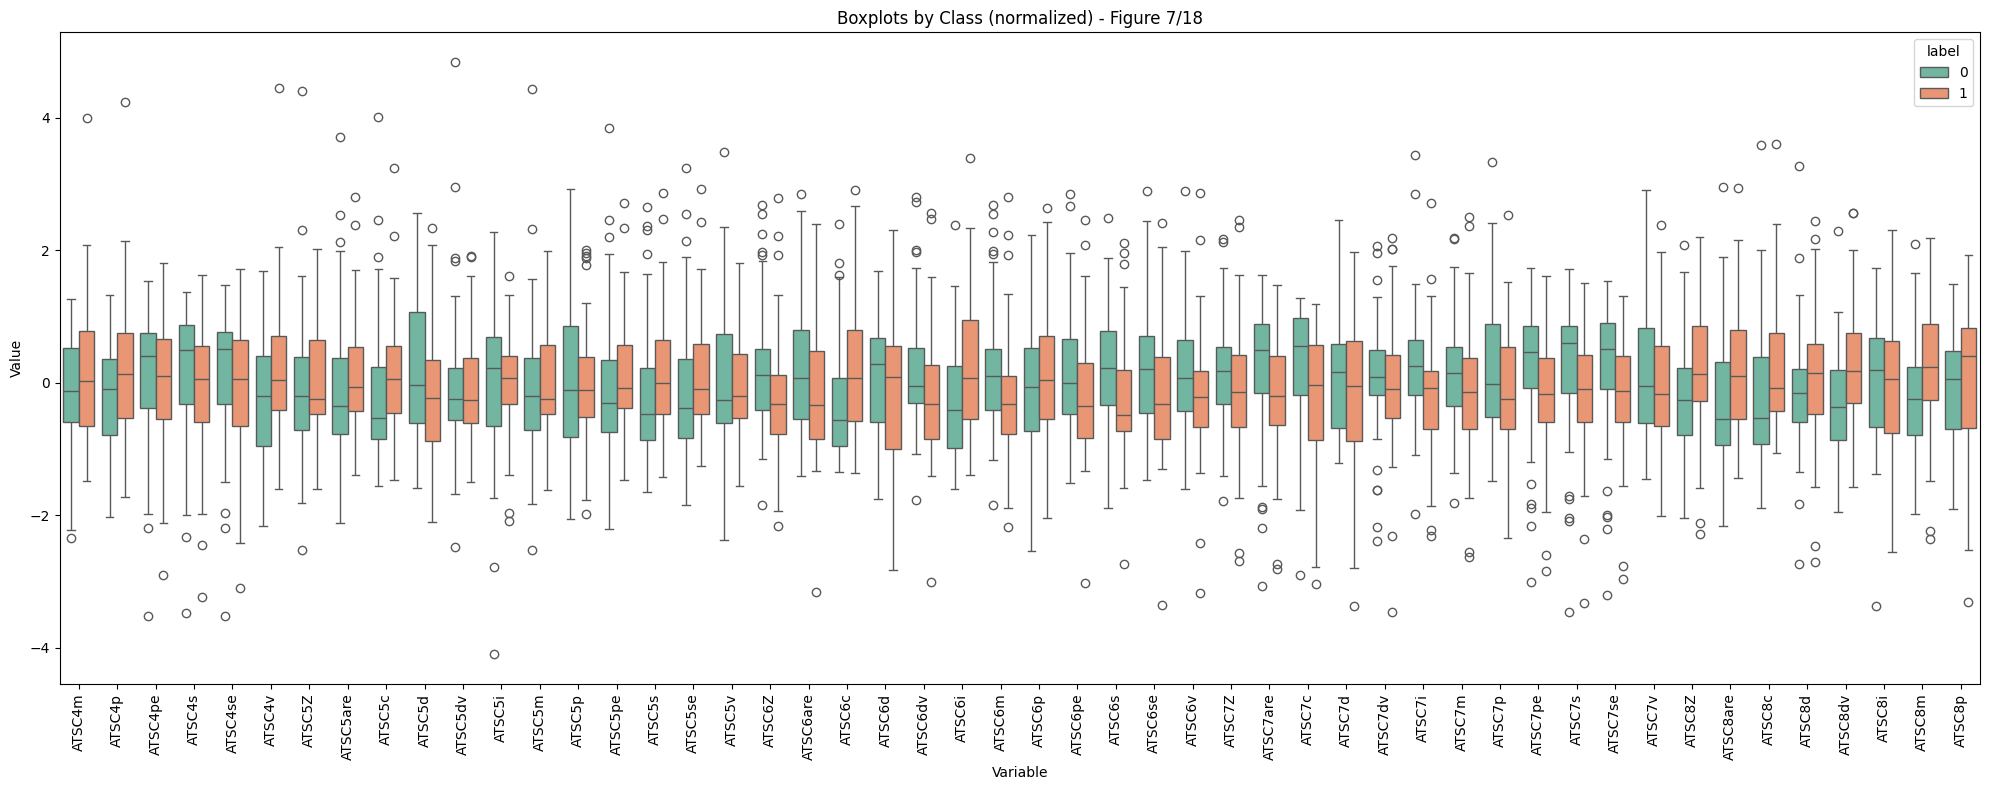

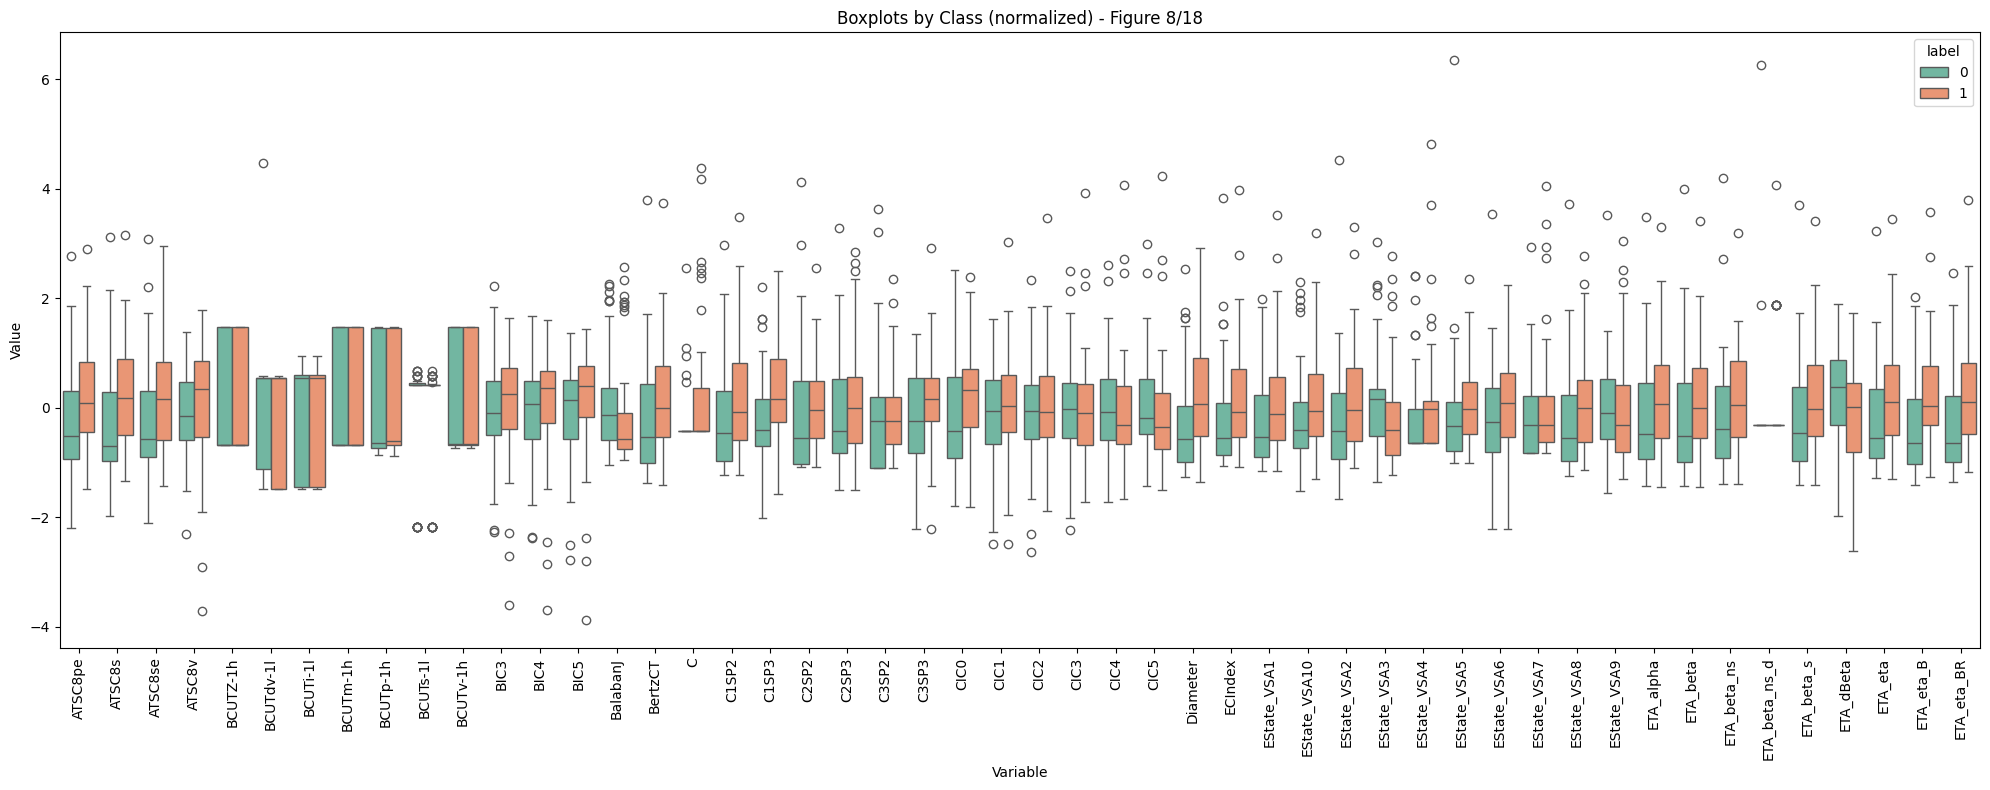

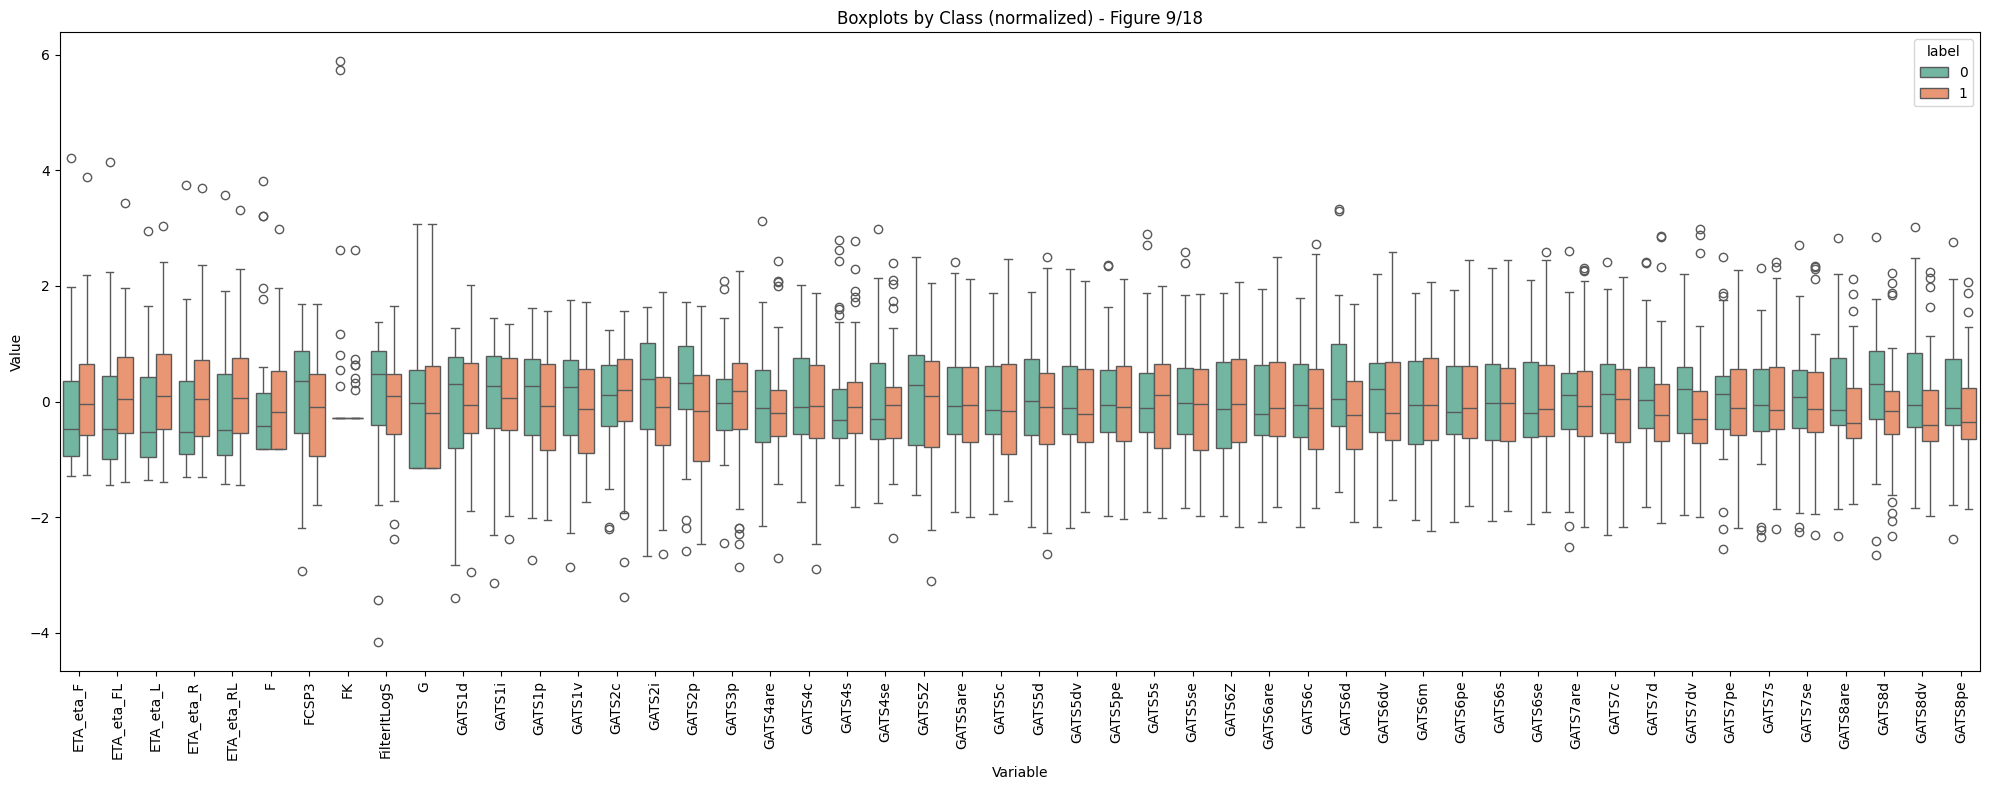

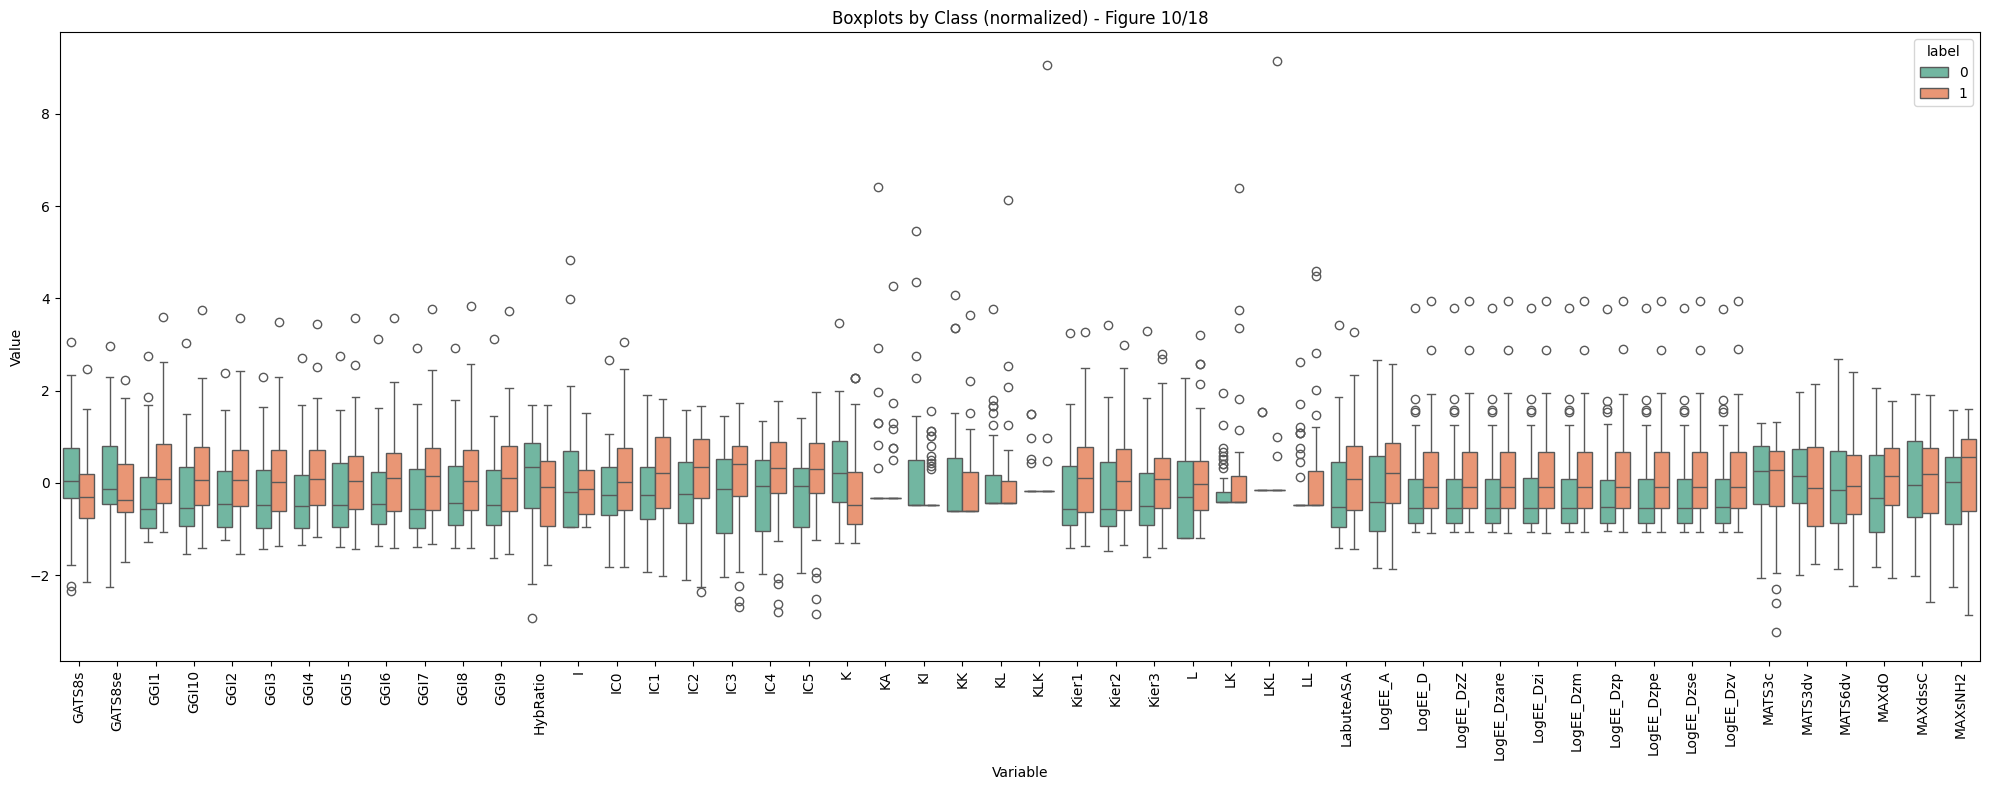

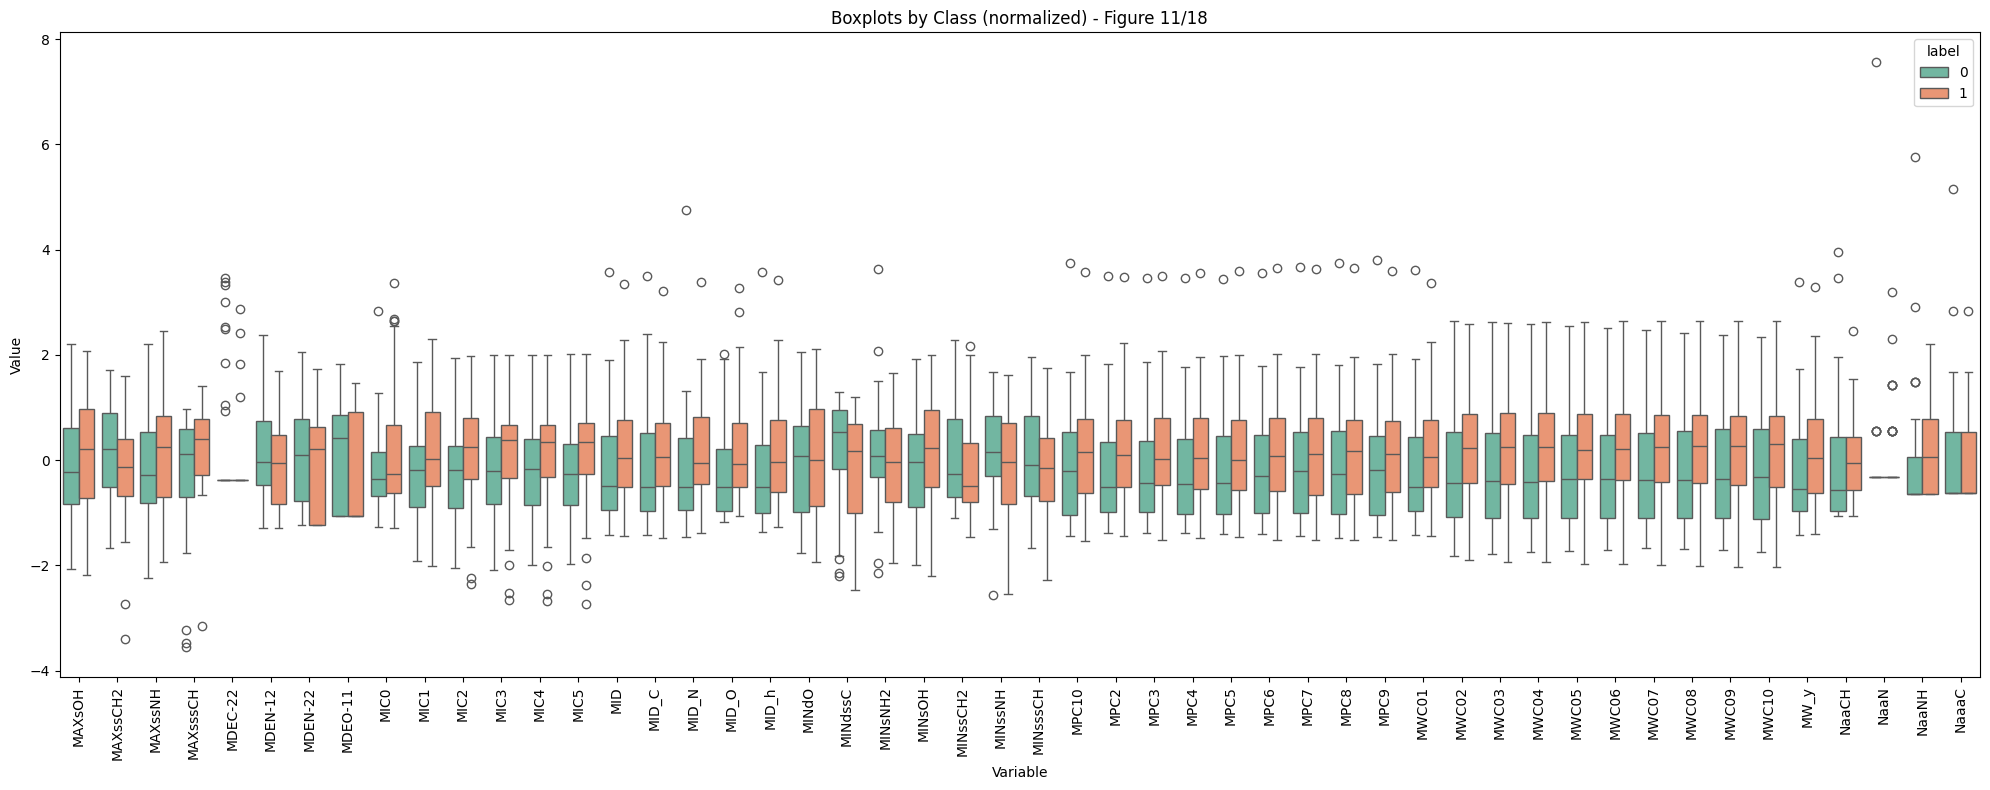

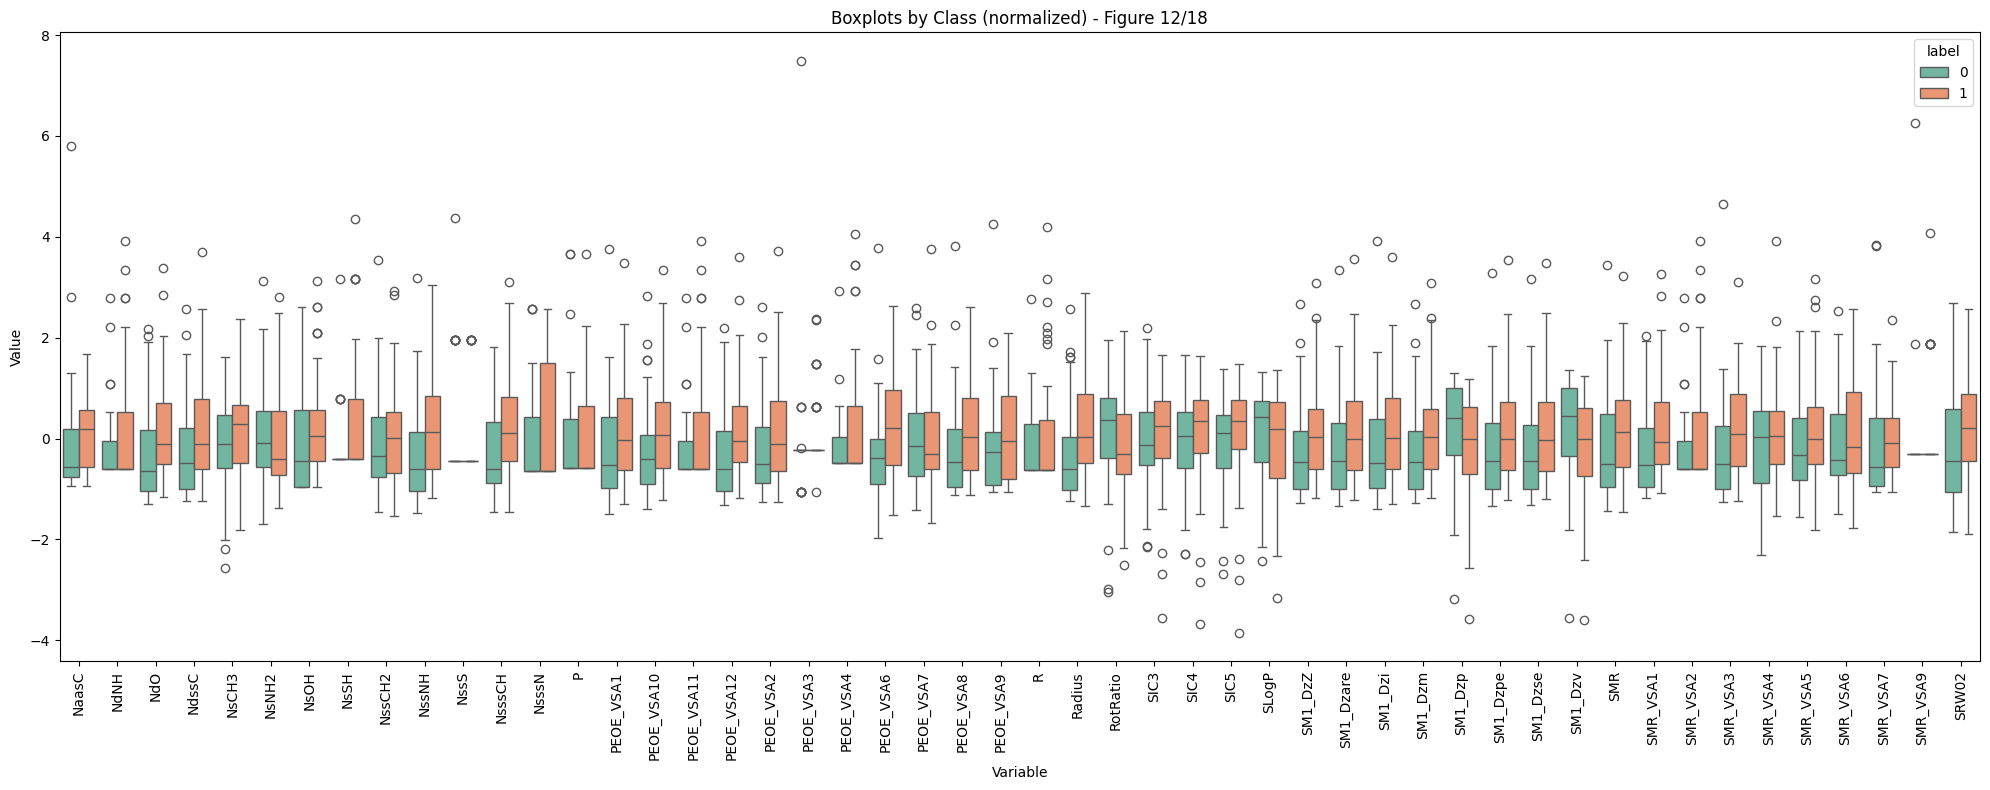

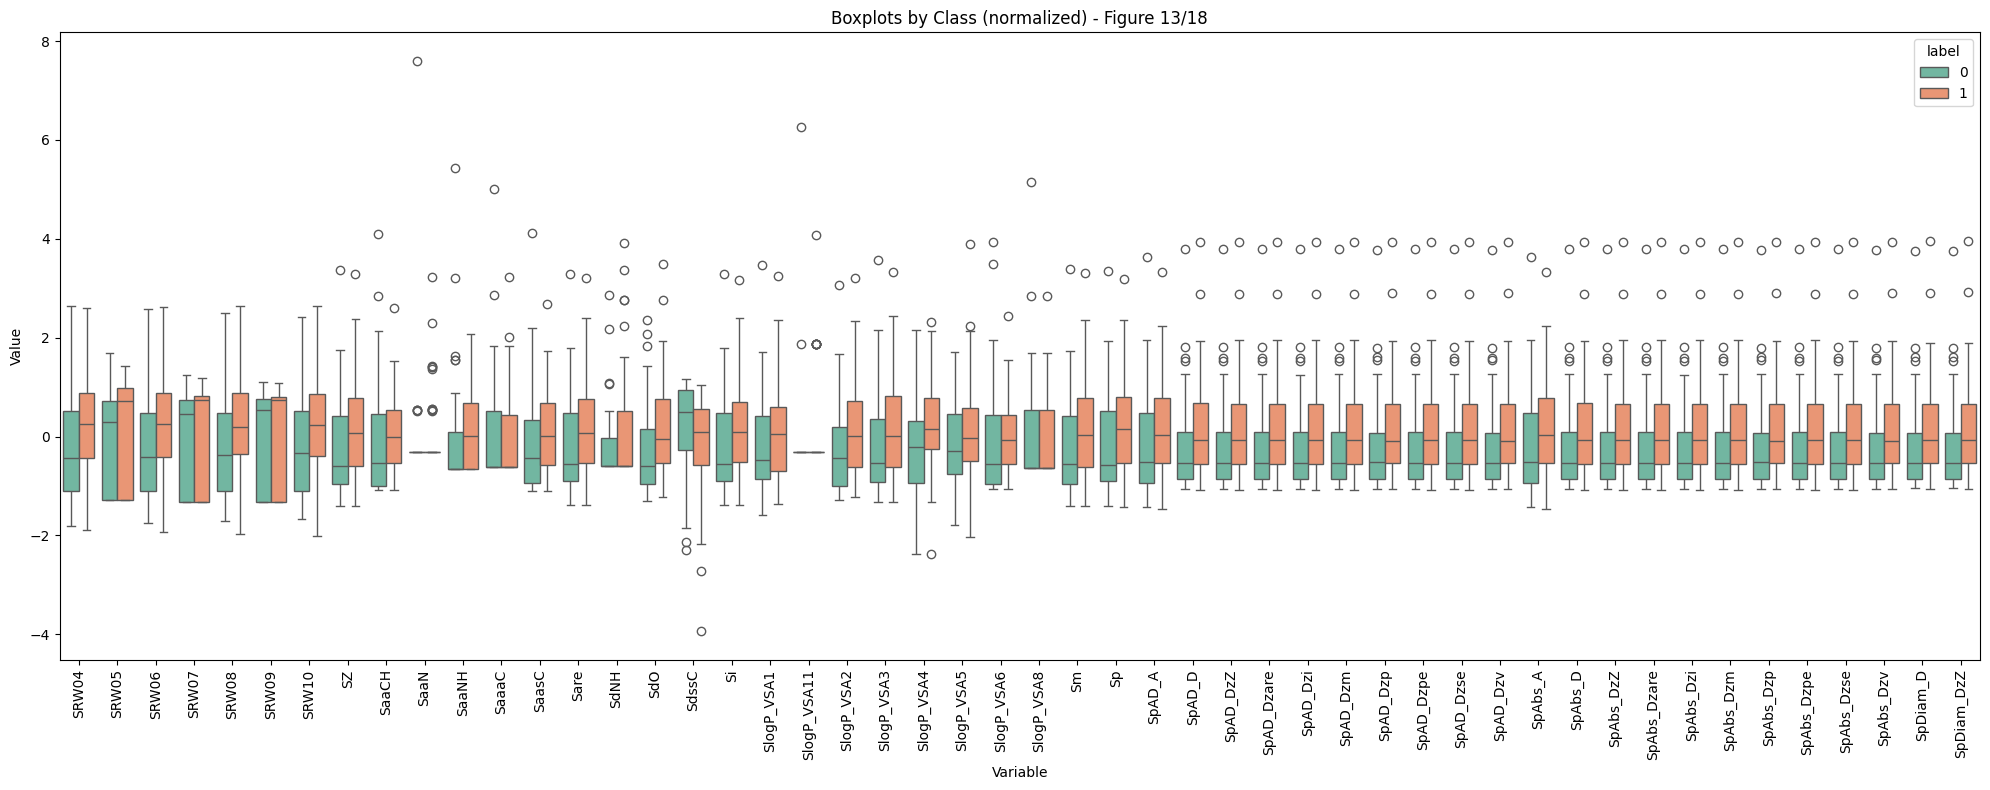

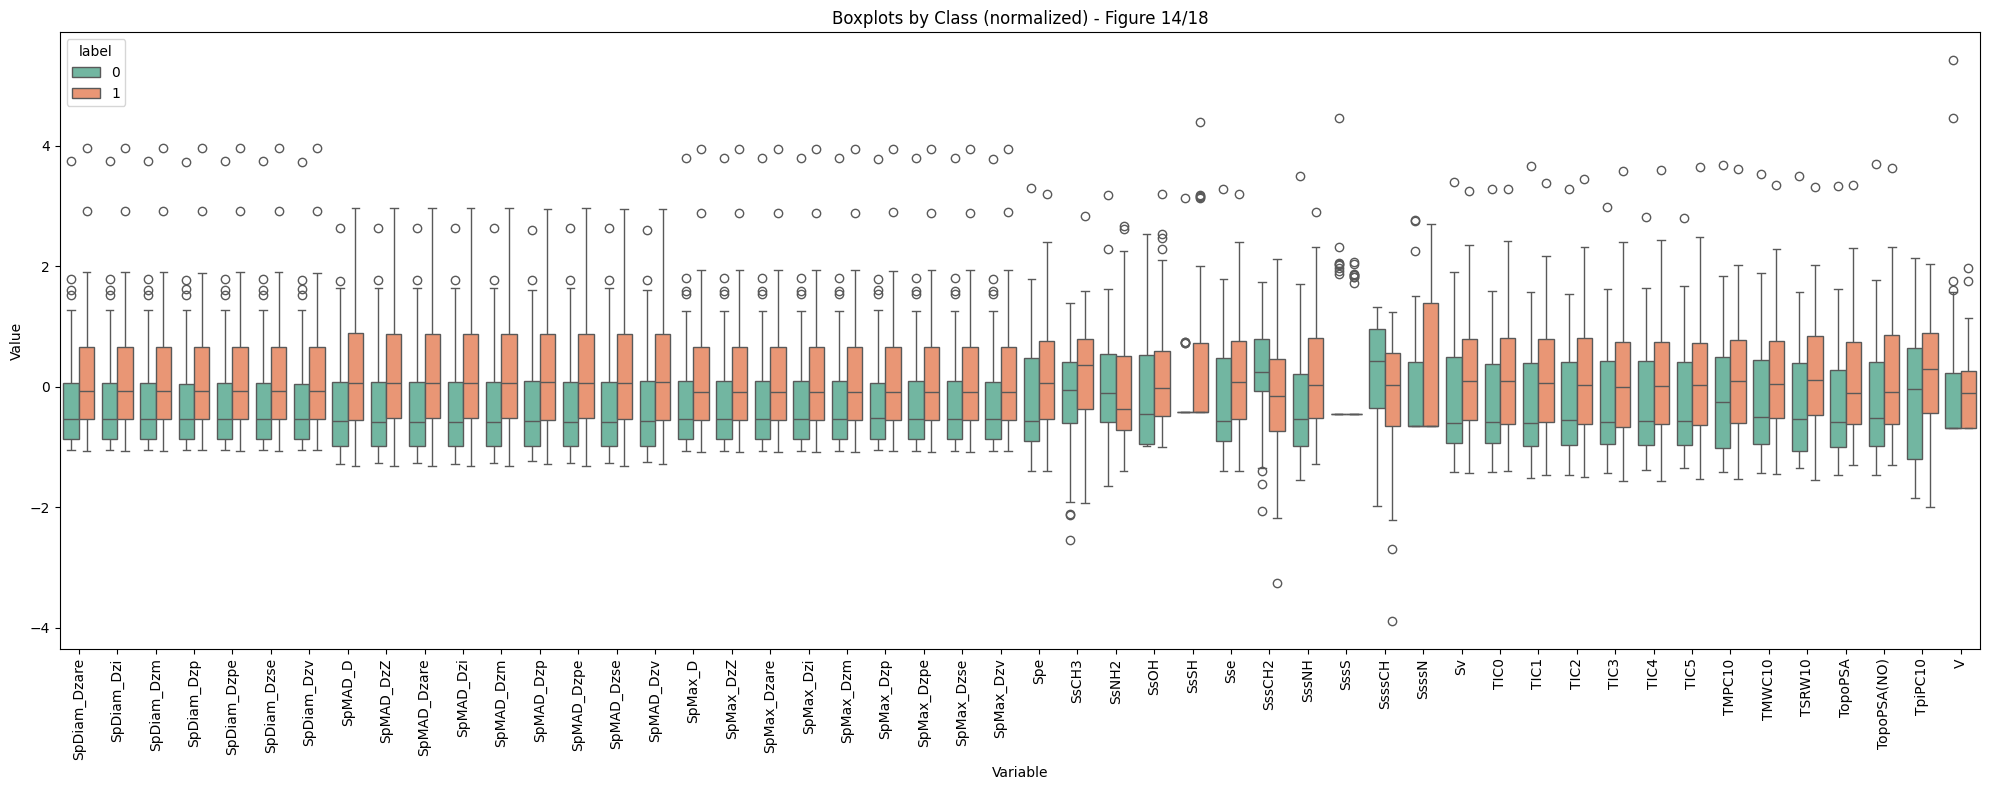

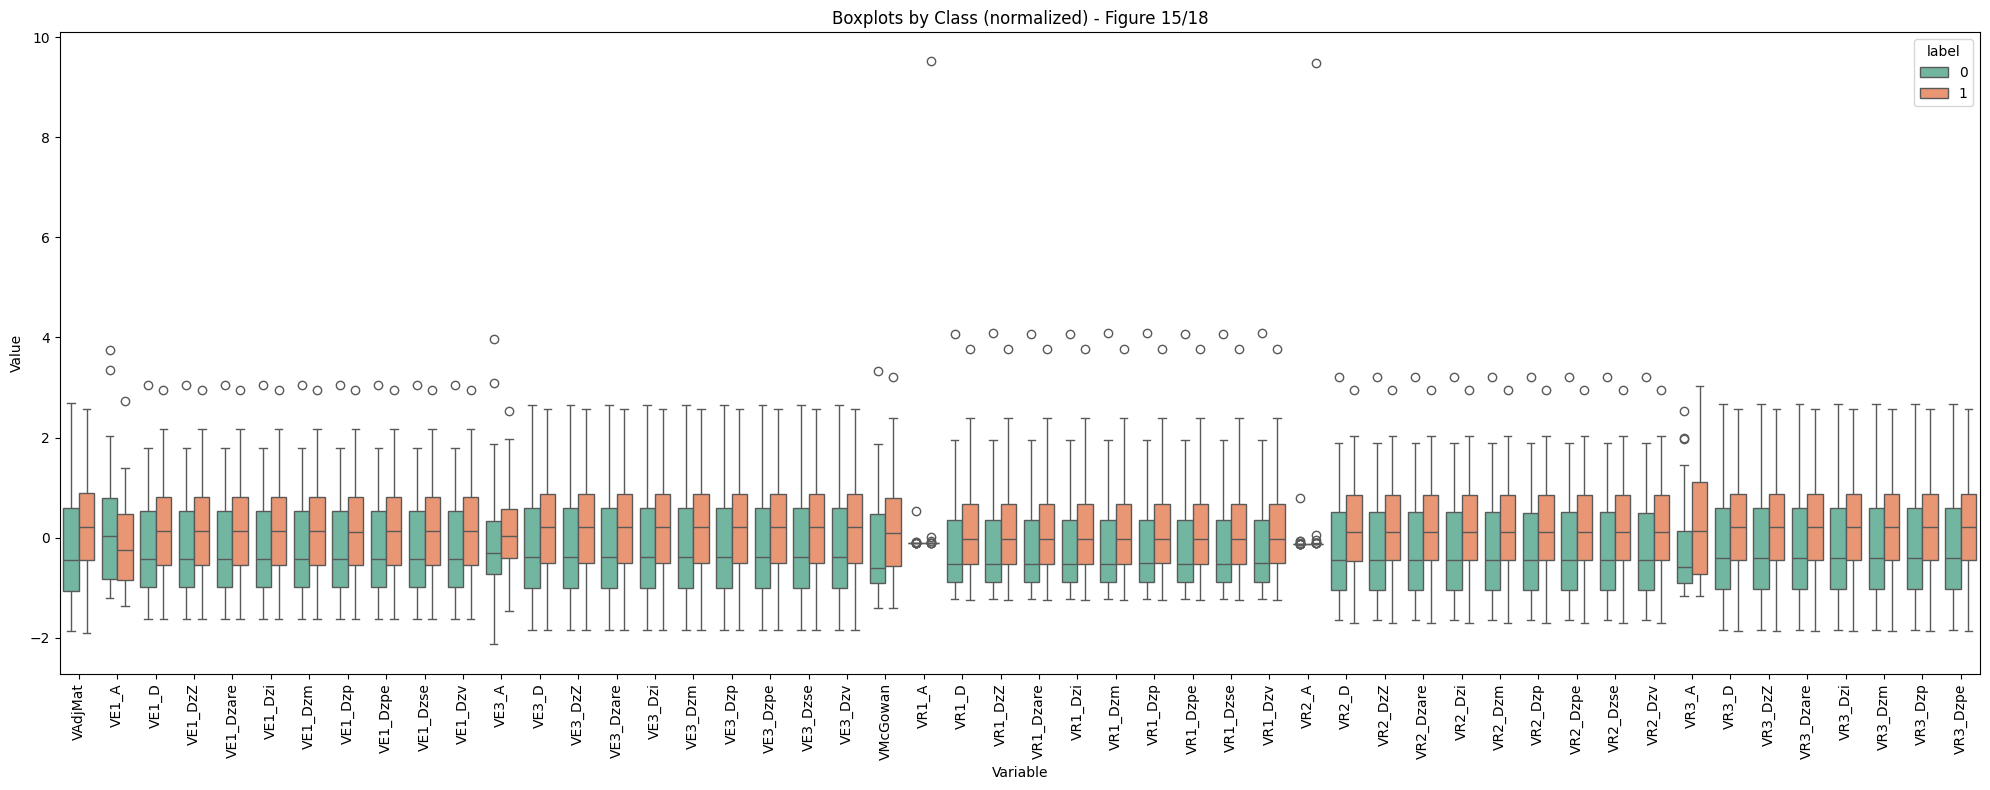

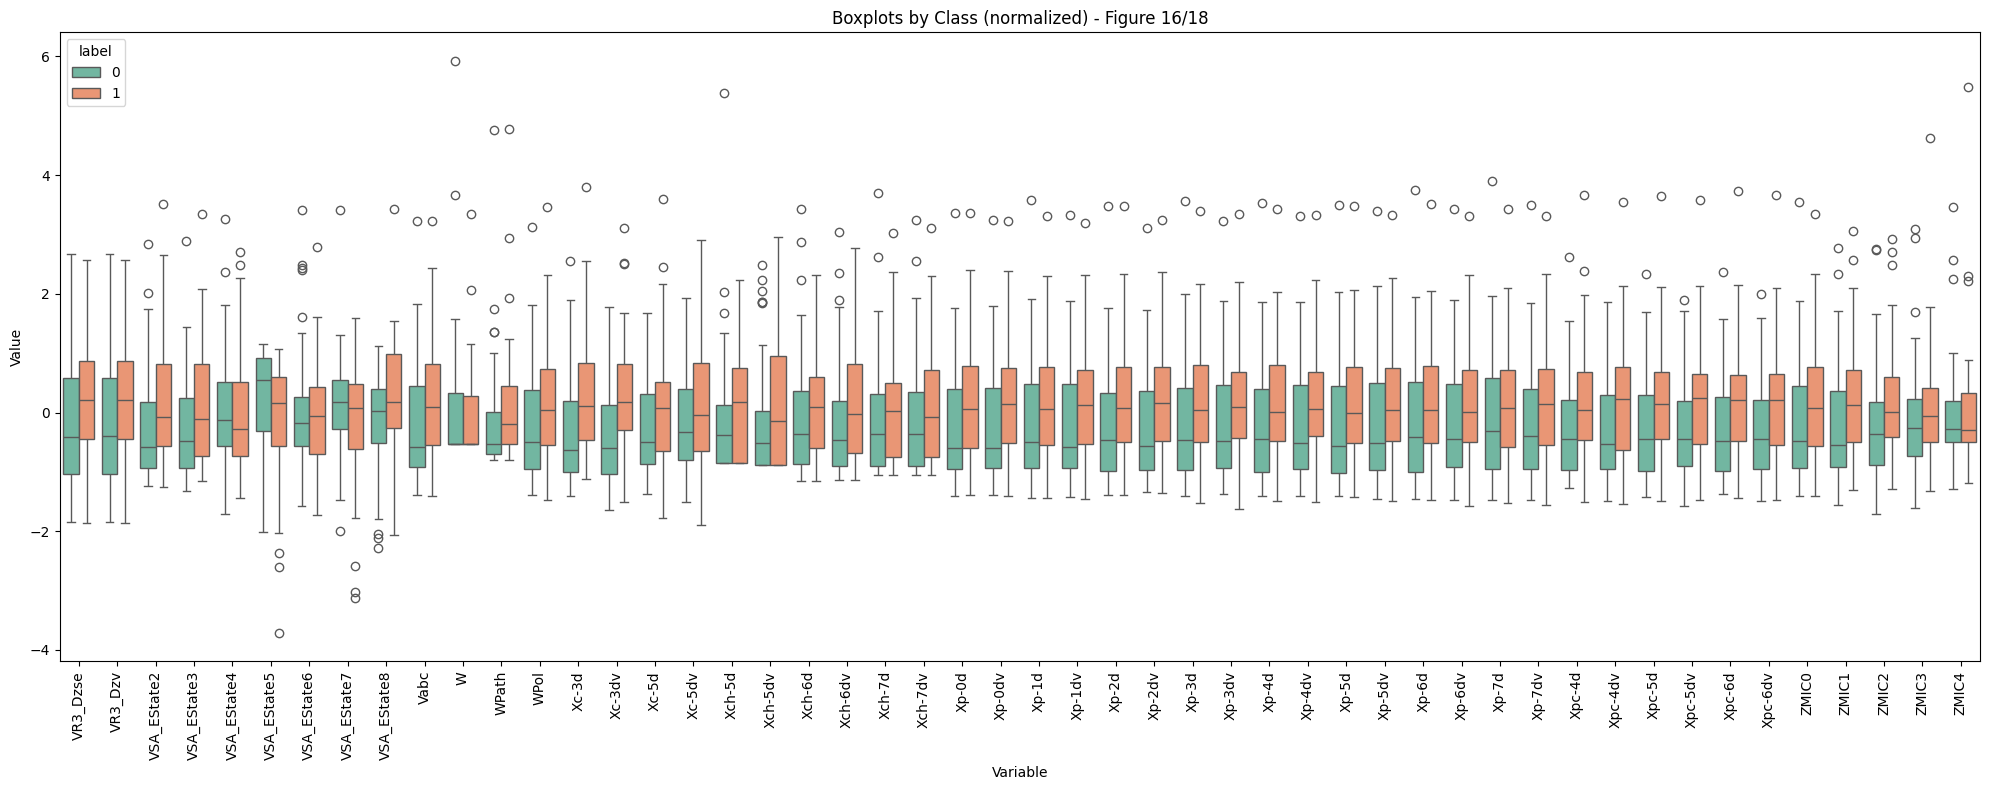

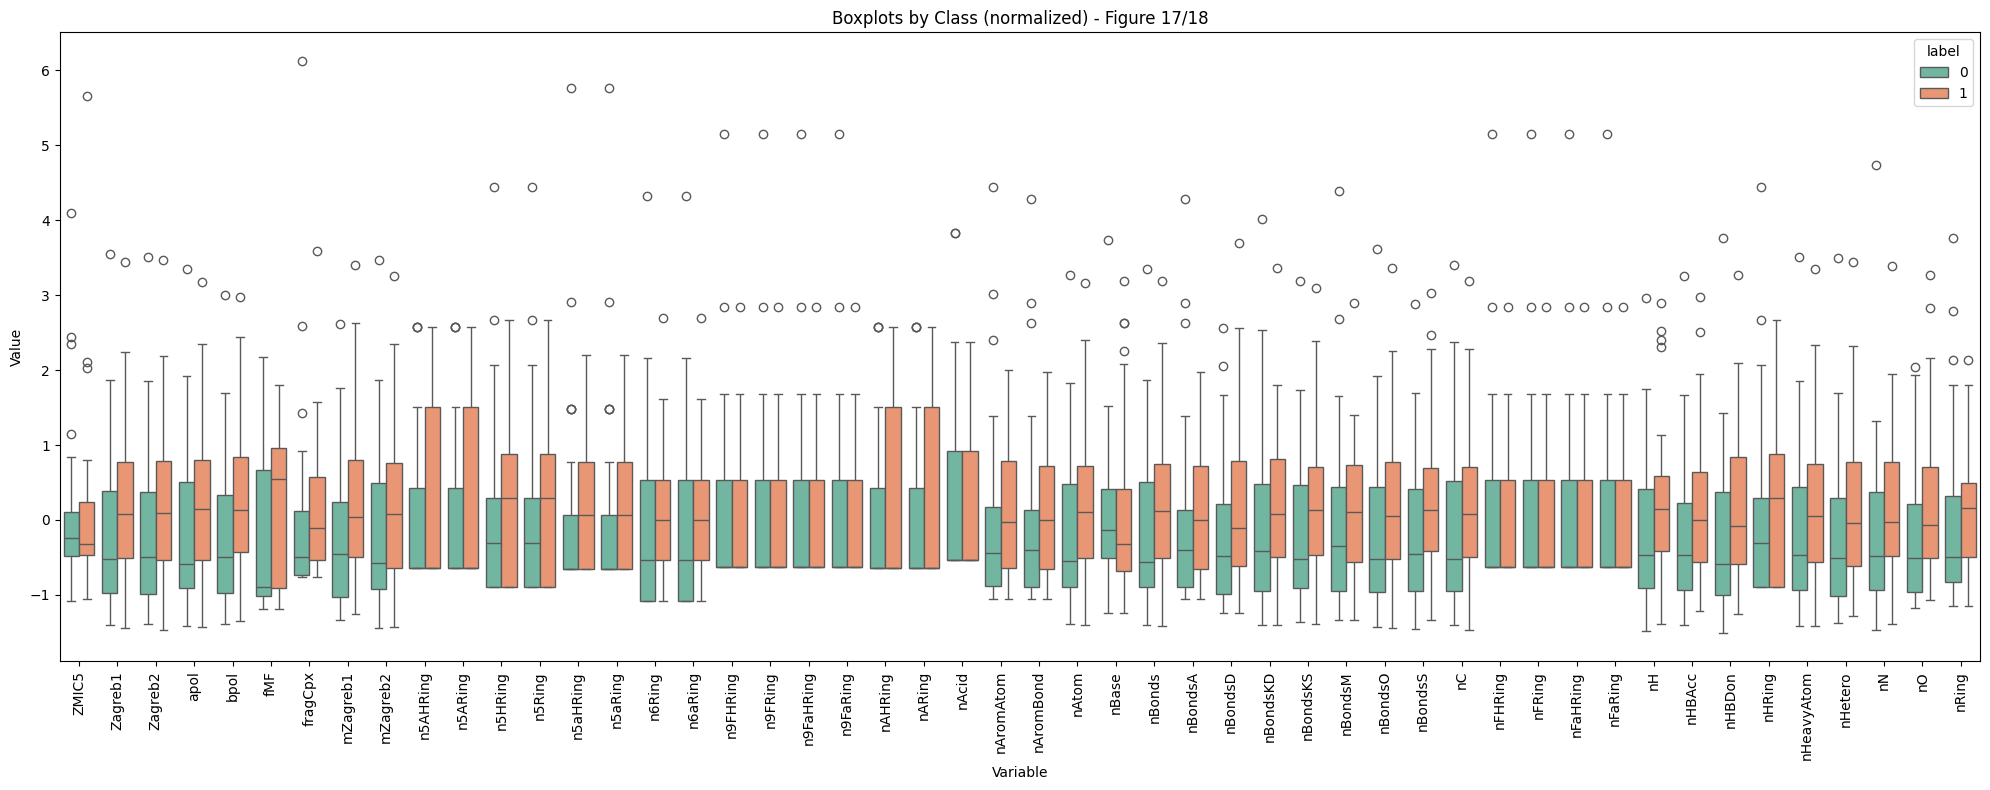

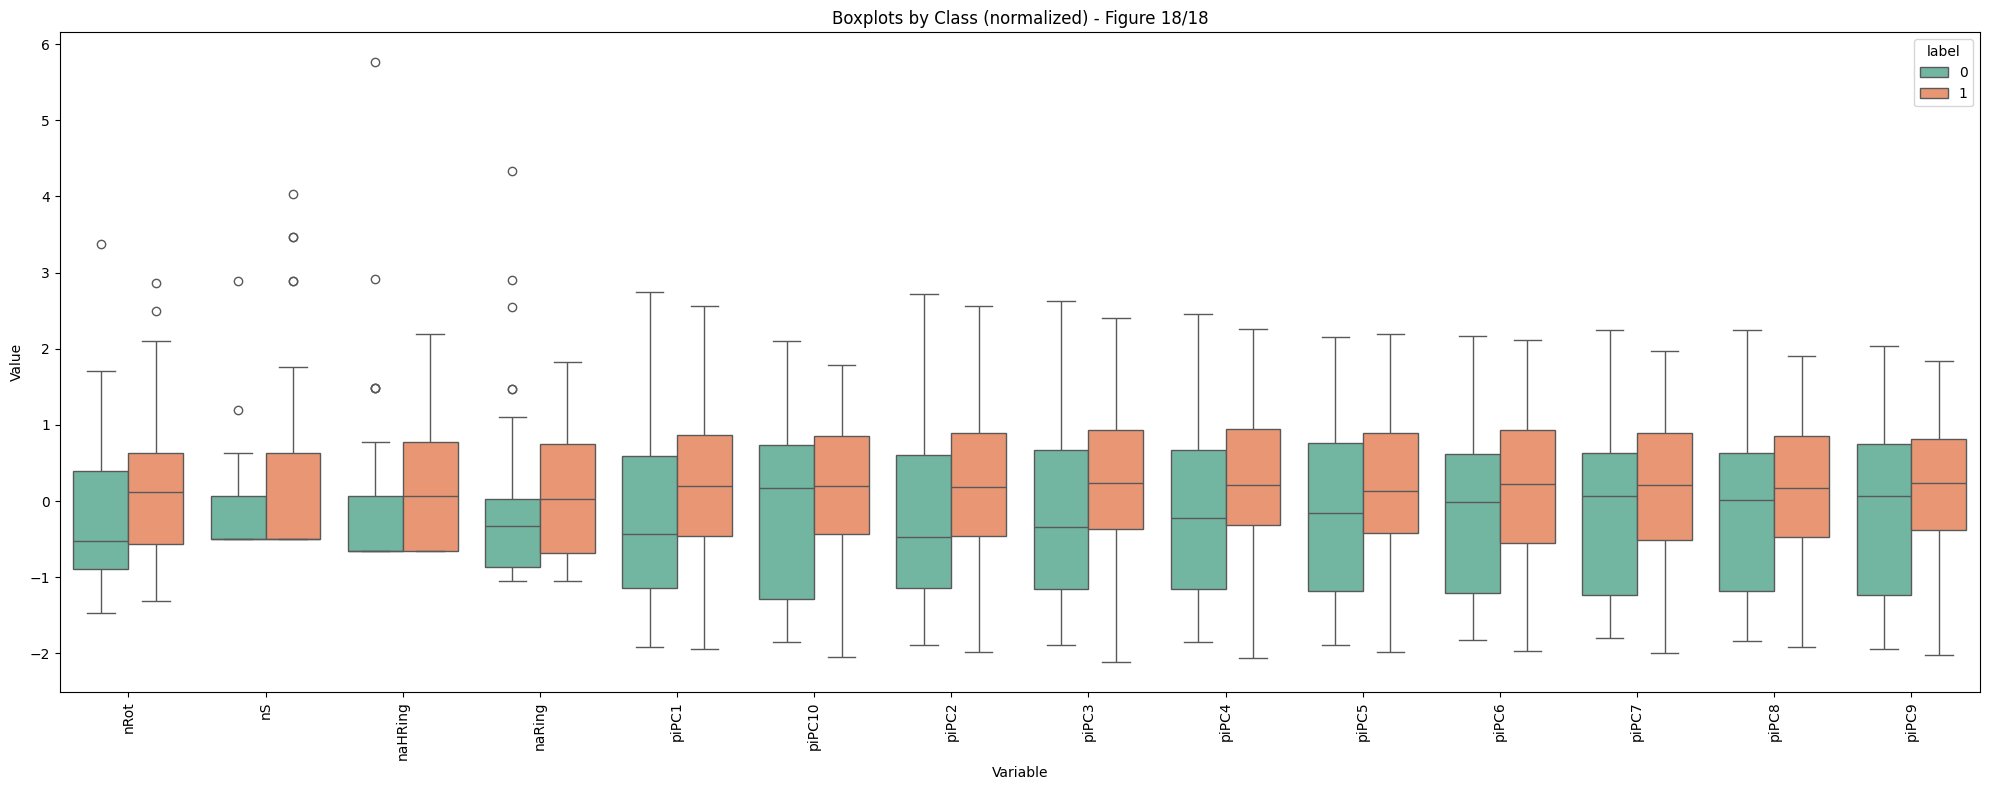

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Parámetros
label_col = 'label'
exclude_cols = ['μM', 'label', 'SEQUENCE']  # las que NO quieres normalizar
std_threshold = 0.05
vars_per_fig = 50


df = df_filtered
# 1️⃣ Filtrar columnas numéricas y aplicar el umbral de desviación estándar
numeric_cols = df.select_dtypes(include=['number']).columns.difference(exclude_cols)
filtered_vars = [col for col in numeric_cols if df[col].std() >= std_threshold]

# 2️⃣ Normalizar solo las columnas filtradas
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[filtered_vars] = scaler.fit_transform(df[filtered_vars])

# 3️⃣ Graficar en grupos de 50 variables
for i in range(0, len(filtered_vars), vars_per_fig):
    subset_vars = filtered_vars[i:i+vars_per_fig]
    melted = df_scaled.melt(id_vars=[label_col], value_vars=subset_vars,
                            var_name='Variable', value_name='Value')
    
    plt.figure(figsize=(20, 8))
    sns.boxplot(data=melted, x='Variable', y='Value', hue=label_col, palette='Set2')
    plt.xticks(rotation=90)
    plt.title(f'Boxplots by Class (normalized) - Figure {i//vars_per_fig + 1}/{-(-len(filtered_vars)//vars_per_fig)}')
    plt.tight_layout()
    plt.show()


/var/folders/lk/smbwpztx1vv0c6ddmx410d780000gn/T/ipykernel_7873/164498092.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


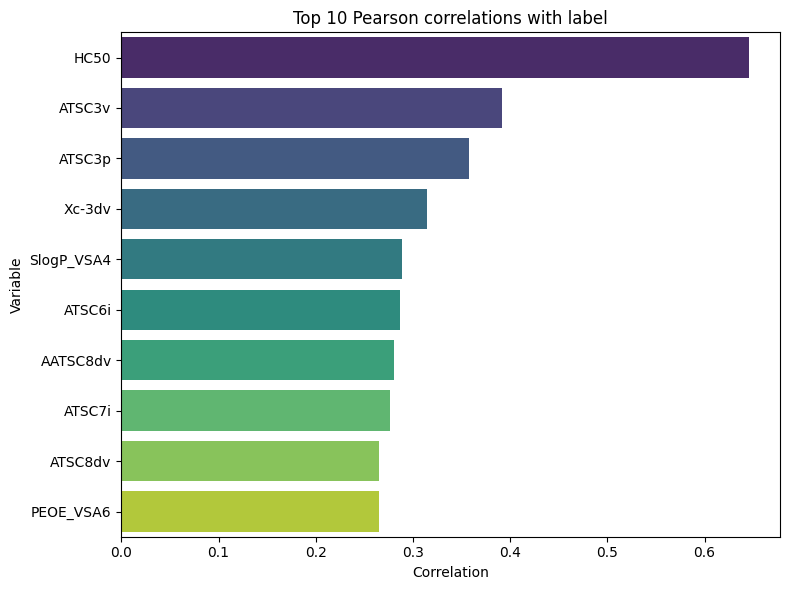

/var/folders/lk/smbwpztx1vv0c6ddmx410d780000gn/T/ipykernel_7873/164498092.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


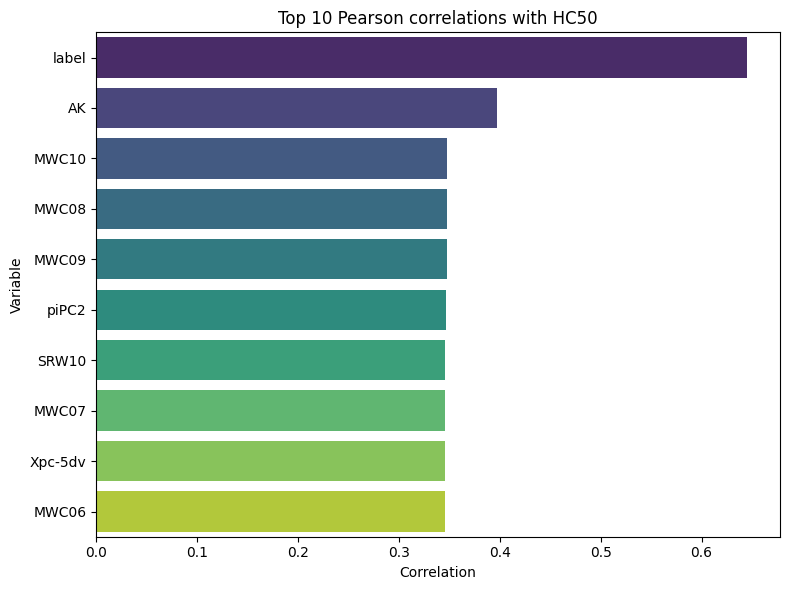

/var/folders/lk/smbwpztx1vv0c6ddmx410d780000gn/T/ipykernel_7873/164498092.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


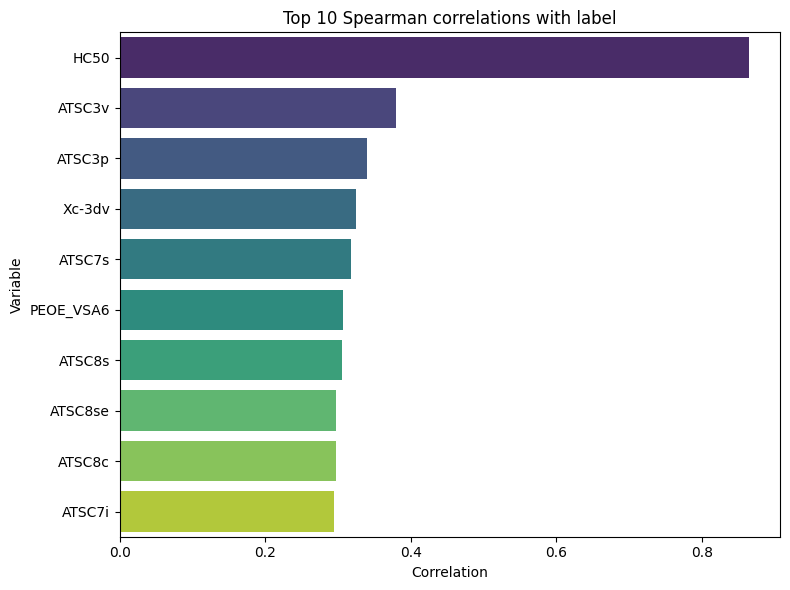

/var/folders/lk/smbwpztx1vv0c6ddmx410d780000gn/T/ipykernel_7873/164498092.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


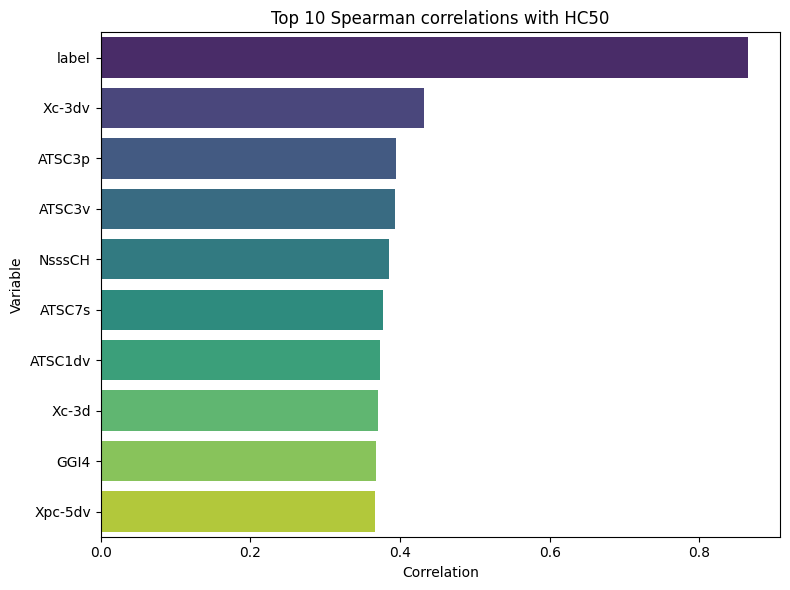

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = df_filtered
df = df.rename(columns={'μM': 'HC50'})

# Variables a excluir del análisis
exclude_cols = ['SEQUENCE']
target_class = 'label'
target_hc50 = 'HC50' if 'HC50' in df.columns else None

# Seleccionar solo columnas numéricas
numeric_df = df.drop(columns=exclude_cols).select_dtypes(include=['number'])

# Calcular correlaciones
corr_pearson = numeric_df.corr(method='pearson')
corr_spearman = numeric_df.corr(method='spearman')

def plot_top_corr(corr_matrix, target, method_name):
    # Ordenar por valor absoluto y quitar el target mismo
    top_corr = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(8,6))
    sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
    plt.title(f"Top 10 {method_name} correlations with {target}")
    plt.xlabel("Correlation")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

# Pearson
plot_top_corr(corr_pearson, target_class, 'Pearson')
if target_hc50:
    plot_top_corr(corr_pearson, target_hc50, 'Pearson')

# Spearman
plot_top_corr(corr_spearman, target_class, 'Spearman')
if target_hc50:
    plot_top_corr(corr_spearman, target_hc50, 'Spearman')


In [54]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, levene, mode

# Filtrar solo variables numéricas, excluyendo la columna 'label'
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('label')

# Lista para almacenar resultados
results = []

# Recorrer cada variable numérica
for col in numeric_cols:
    class0 = df[df['label'] == 0][col].dropna()
    class1 = df[df['label'] == 1][col].dropna()
    
    # Estadísticas para clase 0
    mean0 = class0.mean()
    median0 = class0.median()
    mode0 = mode(class0, keepdims=True).mode[0] if len(class0) > 0 else np.nan
    q1_0 = class0.quantile(0.25)
    q3_0 = class0.quantile(0.75)
    shapiro_p0 = shapiro(class0)[1] if len(class0) >= 3 else np.nan
    
    # Estadísticas para clase 1
    mean1 = class1.mean()
    median1 = class1.median()
    mode1 = mode(class1, keepdims=True).mode[0] if len(class1) > 0 else np.nan
    q1_1 = class1.quantile(0.25)
    q3_1 = class1.quantile(0.75)
    shapiro_p1 = shapiro(class1)[1] if len(class1) >= 3 else np.nan
    
    # Levene test para varianzas
    levene_p = levene(class0, class1)[1] if len(class0) >= 2 and len(class1) >= 2 else np.nan
    
    # Guardar resultados
    results.append({
        'Variable': col,
        
        'Mean_Class0': mean0, 'Median_Class0': median0, 'Mode_Class0': mode0, 'Q1_Class0': q1_0, 'Q3_Class0': q3_0, 'ShapiroP_Class0': shapiro_p0,
        'Mean_Class1': mean1, 'Median_Class1': median1, 'Mode_Class1': mode1, 'Q1_Class1': q1_1, 'Q3_Class1': q3_1, 'ShapiroP_Class1': shapiro_p1,
        
        'LeveneP': levene_p
    })

# Convertir a DataFrame
stats_df = pd.DataFrame(results)

# Mostrar primeras filas
stats_df.head(100)


,Variable,Mean_Class0,Median_Class0,Mode_Class0,Q1_Class0,Q3_Class0,ShapiroP_Class0,Mean_Class1,Median_Class1,Mode_Class1,Q1_Class1,Q3_Class1,ShapiroP_Class1,LeveneP
0,HC50,279.360465,200.000000,200.000000,128.000000,310.350000,0.000003,41.921837,40.000000,50.000000,18.000000,55.300000,1.642526e-02,0.000008
1,A,0.085783,0.055556,0.000000,0.000000,0.129167,0.000006,0.070177,0.047619,0.000000,0.000000,0.105263,1.796091e-07,0.293969
2,AATS0Z,20.811486,20.542955,18.267176,19.802452,21.693442,0.002329,21.450980,20.934579,18.271511,20.062893,22.136842,1.055477e-04,0.179053
3,AATS0are,6.184316,6.172595,5.988218,6.129622,6.242565,0.526165,6.205926,6.204726,5.985012,6.144172,6.259705,5.340624e-01,0.344487
4,AATS0d,2.745168,2.717314,2.500000,2.652013,2.800952,0.002424,2.779398,2.777193,2.501548,2.694444,2.878307,9.463834e-01,0.835013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,AATSC0s,2.321864,2.291148,1.890588,2.199145,2.460045,0.292163,2.356611,2.317252,1.892420,2.192881,2.498233,1.347685e-01,0.503951
96,AATSC0v,46.751304,46.567161,45.488607,46.226292,47.078062,0.012847,46.937157,46.891299,45.076671,46.448435,47.426215,6.839358e-01,0.377601
97,AATSC1Z,-0.129726,-0.115933,-0.628159,-0.162904,-0.067733,0.000104,-0.183761,-0.129372,-0.857750,-0.187461,-0.073787,3.440106e-08,0.219320
98,AATSC1dv,1.035780,1.057075,0.697829,0.995023,1.113089,0.207252,1.050021,1.069683,0.805086,0.978924,1.124586,1.081445e-01,0.338029


1. Medidas de tendencia central
Media (mean) → promedio de los valores.

Mediana (median) → punto que divide el conjunto en dos mitades.

Moda (mode) → valor más frecuente (puede que no exista si todos son distintos).

2. Cuartiles
Q1 → 25% de los datos están por debajo.

Q3 → 75% de los datos están por debajo.

Esto nos ayuda a ver la dispersión y posibles sesgos.

3. Normalidad: Shapiro–Wilk test
Hipótesis nula: los datos vienen de una distribución normal.

Si p > 0.05 → no se rechaza normalidad (datos normales).

Si p ≤ 0.05 → se rechaza normalidad (datos no normales).

4. Homogeneidad de varianzas: Levene’s test
Compara varianzas entre clases.

Si p > 0.05 → varianzas iguales.

Si p ≤ 0.05 → varianzas diferentes.

In [55]:
# Filtrar variables con p >= 0.05 en cualquiera de las dos clases

print(stats_df.info())

stats_df = stats_df.drop_duplicates()

print(stats_df.info())

normal_vars = stats_df[
    (stats_df['ShapiroP_Class0'] >= 0.05) | 
    (stats_df['ShapiroP_Class1'] >= 0.05)
]['Variable'].tolist()

print("Variables con distribución normal en al menos una clase:")
print(normal_vars)
print(len(normal_vars))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865 entries, 0 to 864
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Variable         865 non-null    object 
 1   Mean_Class0      865 non-null    float64
 2   Median_Class0    865 non-null    float64
 3   Mode_Class0      865 non-null    float64
 4   Q1_Class0        865 non-null    float64
 5   Q3_Class0        865 non-null    float64
 6   ShapiroP_Class0  865 non-null    float64
 7   Mean_Class1      865 non-null    float64
 8   Median_Class1    865 non-null    float64
 9   Mode_Class1      865 non-null    float64
 10  Q1_Class1        865 non-null    float64
 11  Q3_Class1        865 non-null    float64
 12  ShapiroP_Class1  865 non-null    float64
 13  LeveneP          865 non-null    float64
dtypes: float64(13), object(1)
memory usage: 94.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865 entries, 0 to 864
Data columns (total 14 colum

In [59]:
from scipy.stats import ttest_ind
import pandas as pd

# Seleccionamos solo las columnas numéricas excluyendo la clase
numeric_cols = df.select_dtypes(include='number').columns.drop('label')

# Lista para guardar resultados
t_results = []

# Iterar sobre cada variable y hacer el t-test
for col in numeric_cols:
    class0 = df[df['label'] == 0][col].dropna()
    class1 = df[df['label'] == 1][col].dropna()
    
    t_stat, p_val = ttest_ind(class0, class1, equal_var=False)  # Welch's t-test
    t_results.append({
        'Variable': col,
        'T_statistic': t_stat,
        'P_value': p_val,
        'Significant': p_val < 0.05  # True si p < 0.05
    })

# Convertir a DataFrame
t_results_df = pd.DataFrame(t_results)

# Ordenar por P_value
t_results_df = t_results_df.sort_values(by='P_value')

# Mostrar las más significativas
print(t_results_df.head(20))


# Filtrar solo las significativas
significant_vars = t_results_df[t_results_df['Significant']]

print("Top 10 most significant variables:")
print(significant_vars.head(10))


       Variable  T_statistic       P_value  Significant
0          HC50     7.521380  2.163884e-09         True
294      ATSC3v     3.959051  1.660547e-04         True
290      ATSC3p     3.632301  4.707470e-04         True
765      Xc-3dv    -3.162584  2.134250e-03         True
324      ATSC6i    -2.872084  5.086098e-03         True
623  SlogP_VSA4    -2.865848  5.192279e-03         True
132    AATSC8dv    -2.776550  6.696001e-03         True
336      ATSC7i     2.731200  7.605603e-03         True
347     ATSC8dv    -2.634991  9.906937e-03         True
562      NsssCH    -2.612365  1.053660e-02         True
572   PEOE_VSA6    -2.603639  1.082372e-02         True
793     Xpc-5dv    -2.591343  1.115851e-02         True
351     ATSC8pe    -2.517371  1.369485e-02         True
133     AATSC8m    -2.474918  1.520172e-02         True
795     Xpc-6dv    -2.465429  1.558693e-02         True
110     AATSC3v     2.457866  1.633817e-02         True
791     Xpc-4dv    -2.439410  1.667337e-02      

In [61]:
import pandas as pd
import numpy as np

def remove_highly_correlated(df, method='pearson', threshold=0.75):
    """
    Removes highly correlated features from a DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame with numeric features.
        method (str): 'pearson' or 'spearman'.
        threshold (float): Correlation threshold above which to remove variables.
    
    Returns:
        df_filtered (pd.DataFrame): DataFrame without highly correlated features.
        removed_features (list): List of removed features.
    """
    corr_matrix = df.corr(method=method).abs()
    
    # Mask upper triangle to avoid duplicate checks
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    removed_features = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    
    df_filtered = df.drop(columns=removed_features)
    return df_filtered, removed_features

# Ejemplo de uso (Pearson)
numeric_df = df.select_dtypes(include='number').drop(columns=['label'])  # sin la clase
df_pearson, removed_pearson = remove_highly_correlated(numeric_df, method='pearson', threshold=0.75)

# Ejemplo de uso (Spearman)
df_spearman, removed_spearman = remove_highly_correlated(numeric_df, method='spearman', threshold=0.75)

print(f"Removed with Pearson: {len(removed_pearson)} variables")
print(f"Removed with Spearman: {len(removed_spearman)} variables")


print(df_pearson.info())


Removed with Pearson: 796 variables
Removed with Spearman: 789 variables
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HC50           92 non-null     float64
 1   A              92 non-null     float64
 2   AATS0Z         92 non-null     float64
 3   AATS0d         92 non-null     float64
 4   AATS0i         92 non-null     float64
 5   AATS6i         92 non-null     float64
 6   AATSC1i        92 non-null     float64
 7   AATSC2Z        92 non-null     float64
 8   AATSC3Z        92 non-null     float64
 9   AATSC3v        92 non-null     float64
 10  AATSC4Z        92 non-null     float64
 11  AATSC5Z        92 non-null     float64
 12  AATSC5v        92 non-null     float64
 13  AATSC8Z        92 non-null     float64
 14  AATSC8dv       92 non-null     float64
 15  AATSC8v        92 non-null     float64
 16  ABC            92 non-null 